In [117]:
import pandas as pd

to_open = ['diff','log','lstm','chronos2']
dfs = []
for folder in to_open:
    df = pd.read_csv(f"./{folder}/leaderboard.csv")
    if 'split' in df.columns.to_list():
        df = df[df['split'] == 'test']
    dfs.append(df)

# Correctly filter to keep only rows where the 'split' column is 'test'

In [118]:
naive_weekly_rmsse_mean = dfs[0][dfs[0]['model'] == 'naive_weekly']['RMSSE_mean'].item()
naive_weekly_rmse_mean = dfs[0][dfs[0]['model'] == 'naive_weekly']['RMSE'].item()
naive_last_rmsse_mean = dfs[0][dfs[0]['model'] == 'naive_last']['RMSSE_mean'].item()

In [119]:
print(naive_last_rmsse_mean)
print(naive_weekly_rmsse_mean)

2.2295653755407505
2.1481753322120243


In [120]:
import json
def load_region_activity_dictionary(filepath: str = 'regions_activity_cat.json') -> dict:
    """
    Loads the region activity configuration from a JSON file.
    """
    r_dict = {}
    region_activity_dictionary = {}
    tier_mapping = {'little': 0, 'low': 1, 'medium': 2, 'high': 3}
    with open(filepath, 'r') as file:
        region_activity_dictionary = json.load(file)
    
    for key,value in region_activity_dictionary.items():
        for values in value:
            r_dict[values] = tier_mapping[key]
    return r_dict

activity_levels = load_region_activity_dictionary("../data/fixed/regions_activity_cat.json")

In [121]:
import pandas as pd
import io


to_open = ['diff', 'log', 'lstm', 'chronos2','gbdt','finalhurdle']
dfs = [] 

for folder in to_open:
    df = pd.read_csv(f"./{folder}/leaderboard.csv")
    if 'split' in df.columns:
        df = df[df['split'] == 'test'].copy()
    df['Modelname'] = folder
    if 'model' not in df.columns:
        df['model'] = folder
    dfs.append(df)

temp_df = pd.concat(dfs, ignore_index=True)
naive_weekly_rmsse_mean = temp_df[temp_df['model'] == 'naive_weekly']['RMSSE_mean'].values[0]

# 4. Process all dataframes uniformly
def process_dataframe(df):
    df = df.copy() # Prevents SettingWithCopyWarning
    
    # Ensure 'paradigm' column exists
    if 'paradigm' not in df.columns:
        df['paradigm'] = 'local'
        
    # Calculate SkillScore
    df['SkillScore'] = (1 - (df['RMSE'] / naive_weekly_rmse_mean)) 
    
    # Filter to only the columns we need
    keep_cols = ['Modelname', 'paradigm', 'model', 'SkillScore', 'MAE', 'RMSE']
    
    # Rename them to match your exact required lowercase structure
    formatted_df = df[keep_cols].rename(columns={
        'MAE': 'mae',
        'RMSE': 'rmse',
        # 'RMSSE_mean': 'rmsse_mean'
    })
    
    return formatted_df

processed_dfs = [process_dataframe(df) for df in dfs]
master_df = pd.concat(processed_dfs, ignore_index=True)

master_df = master_df.sort_values(by='SkillScore', ascending=False).reset_index(drop=True)

# Display the final structured dataframe
print(master_df.head(30))

   Modelname  paradigm                   model  SkillScore       mae      rmse
0       gbdt  activity  catboost_tweedie_tuned    0.169634  0.767909  1.830539
1   chronos2     local     chronos2_fine_tuned    0.169486  0.713611  1.830864
2       gbdt    global  catboost_tweedie_tuned    0.169411  0.785818  1.831029
3       gbdt    global  lightgbm_poisson_tuned    0.165593  0.775707  1.839445
4       lstm  activity  lstm_poisson_w28_tuned    0.165131  0.777548  1.840464
5   chronos2     local      chronos2_zero_shot    0.161110  0.719448  1.849330
6       diff    global                   arima    0.159221  0.813287  1.853493
7       gbdt  activity  lightgbm_poisson_tuned    0.159210  0.766848  1.853518
8       gbdt  activity  catboost_poisson_tuned    0.153791  0.779569  1.865464
9       gbdt    global   xgboost_tweedie_tuned    0.152136  0.778661  1.869111
10      lstm  activity   gru_poisson_w28_tuned    0.151309  0.782510  1.870936
11      gbdt  activity   xgboost_tweedie_tuned    0.

In [122]:
naive_weekly = master_df[(master_df['Modelname'] == 'diff') & (master_df['model'].str.contains('naive_weekly', case=False, na=False))].copy()
naive =  master_df[(master_df['model'].str.contains('naive', case=False, na=False))]
display(master_df[(master_df['Modelname'] != 'log') | (master_df['model'] != 'linear')].head(30))


,Modelname,paradigm,model,SkillScore,mae,rmse
0,gbdt,activity,catboost_tweedie_tuned,0.169634,0.767909,1.830539
1,chronos2,local,chronos2_fine_tuned,0.169486,0.713611,1.830864
2,gbdt,global,catboost_tweedie_tuned,0.169411,0.785818,1.831029
3,gbdt,global,lightgbm_poisson_tuned,0.165593,0.775707,1.839445
4,lstm,activity,lstm_poisson_w28_tuned,0.165131,0.777548,1.840464
5,chronos2,local,chronos2_zero_shot,0.161110,0.719448,1.849330
6,diff,global,arima,0.159221,0.813287,1.853493
7,gbdt,activity,lightgbm_poisson_tuned,0.159210,0.766848,1.853518
8,gbdt,activity,catboost_poisson_tuned,0.153791,0.779569,1.865464
9,gbdt,global,xgboost_tweedie_tuned,0.152136,0.778661,1.869111


In [123]:
master_df[(master_df['Modelname'].str.contains('diff', case=False, na=False))]

,Modelname,paradigm,model,SkillScore,mae,rmse
6,diff,global,arima,0.159221,0.813287,1.853493
19,diff,global,linear,0.143345,0.875316,1.888492
71,diff,global,catboost_tuned,0.059292,0.896901,2.073786
72,diff,activity,catboost_tuned,0.059193,0.887646,2.074005
78,diff,global,lightgbm_tuned,0.021162,0.928899,2.157844
79,diff,local,catboost_tuned,0.018412,0.927094,2.163905
80,diff,activity,xgboost_tuned,0.017132,0.922735,2.166728
81,diff,activity,lightgbm_tuned,0.014304,0.910961,2.172961
83,diff,global,xgboost_tuned,0.010999,0.943913,2.180249
84,diff,global,naive_weekly,0.000000,0.894730,2.204495


In [124]:
hurdle =  master_df[(master_df['model'].str.contains('hurdle', case=False, na=False))]
display(hurdle)

,Modelname,paradigm,model,SkillScore,mae,rmse
55,finalhurdle,global,finalhurdle,0.092080,0.794769,2.001505
69,finalhurdle,activity,finalhurdle,0.064750,0.923391,2.061754
87,finalhurdle,local,finalhurdle,-0.020039,0.913917,2.248672


In [125]:
naive_weekly['paradigm'] = 'local'

In [126]:
import seaborn as sns
import itertools
top_5_df = master_df.head(5)

arima = master_df[(master_df['Modelname'] == 'diff') & (master_df['model'].str.contains('arima', case=False, na=False))]

top_5_w_naive = pd.concat([top_5_df, naive_weekly, arima])

def yield_pal_col():
    pal = sns.color_palette("tab20")
    for col in itertools.cycle(pal):
        yield col + (1,)
pal_col = yield_pal_col()

Model_names = top_5_w_naive['model'] + "_" + top_5_w_naive['paradigm']
Model_names.to_list()
MODEL_COLORS = {name: next(pal_col) for name in Model_names.to_list()}
NAIVE_COLOR = (50/255, 50/255, 50/255, 0.5)
MODEL_COLORS['naive_weekly_local'] = NAIVE_COLOR

In [127]:
MODEL_COLORS

{'catboost_tweedie_tuned_activity': (0.12156862745098039,
  0.4666666666666667,
  0.7058823529411765,
  1),
 'chronos2_fine_tuned_local': (0.6823529411764706,
  0.7803921568627451,
  0.9098039215686274,
  1),
 'catboost_tweedie_tuned_global': (1.0,
  0.4980392156862745,
  0.054901960784313725,
  1),
 'lightgbm_poisson_tuned_global': (1.0,
  0.7333333333333333,
  0.47058823529411764,
  1),
 'lstm_poisson_w28_tuned_activity': (0.17254901960784313,
  0.6274509803921569,
  0.17254901960784313,
  1),
 'naive_weekly_local': (0.19607843137254902,
  0.19607843137254902,
  0.19607843137254902,
  0.5),
 'arima_global': (0.8392156862745098,
  0.15294117647058825,
  0.1568627450980392,
  1)}

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

metrics = ['SkillScore', 'mae', 'rmse']


# fig_box, axes_box = plt.subplots(2, 2, figsize=(14, 10))
# fig_box.suptitle("Boxplots of Metrics by Paradigm", fontsize=16, fontweight='bold')

# for i, metric in enumerate(metrics):
#     ax = axes_box[i//2, i%2]
#     sns.boxplot(data=master_df, x='paradigm', y=metric, ax=ax, palette="Set2")
#     sns.stripplot(data=master_df, x='paradigm', y=metric, color='black', alpha=0.5, size=4, ax=ax)
#     ax.set_title(f'{metric} (Boxplot)', fontweight='bold')

# plt.tight_layout()
# plt.show()

# fig_dist, axes_dist = plt.subplots(2, 2, figsize=(14, 10))
# fig_dist.suptitle("Distributions of Metrics by Paradigm", fontsize=16, fontweight='bold')

# for i, metric in enumerate(metrics):
#     ax = axes_dist[i//2, i%2]
#     sns.histplot(data=master_df, x=metric, hue='paradigm', ax=ax, palette="Set2", kde=True, element="step", alpha=0.3)
#     ax.set_title(f'{metric} (Distribution)', fontweight='bold')

# plt.tight_layout()
# plt.show()


for metric in metrics:
    print(f"METRIC: {metric.upper()}")
    
    clean_df = master_df[~master_df['model'].isin(['naive_weekly', 'naive_last', 'arima'])]
    clean_df = clean_df[['paradigm', metric]].dropna()
    
    groups = [group[metric].values for name, group in clean_df.groupby('paradigm')]
    
    normality_passed = True
    for group in groups:
        if len(group) >= 3: # Shapiro requires at least 3 data points
            stat, p = stats.shapiro(group)
            if p < 0.05:
                normality_passed = False
                break
        else:
            normality_passed = False
            
    # --- Assumption 2: Equal Variance (Levene's Test) ---
    _, levene_p = stats.levene(*groups)
    print(p,levene_p)

    variance_passed = levene_p >= 0.05
    dunn_matrix = sp.posthoc_dunn(clean_df, val_col=metric, group_col='paradigm', p_adjust='holm')
    print("   Dunn's Test p-values (Look for values < 0.05):")
    print(dunn_matrix.round(4))


    print("-" * 40)

METRIC: SKILLSCORE
1.3611121691902658e-06 0.008058561075438496
   Dunn's Test p-values (Look for values < 0.05):
          activity  global   local
activity    1.0000  0.7477  0.0156
global      0.7477  1.0000  0.0088
local       0.0156  0.0088  1.0000
----------------------------------------
METRIC: MAE
7.290786921194676e-08 0.014104603498629584
   Dunn's Test p-values (Look for values < 0.05):
          activity  global   local
activity    1.0000  0.0567  0.0549
global      0.0567  1.0000  0.6754
local       0.0549  0.6754  1.0000
----------------------------------------
METRIC: RMSE
1.3611121691902887e-06 0.008058561075438548
   Dunn's Test p-values (Look for values < 0.05):
          activity  global   local
activity    1.0000  0.7477  0.0156
global      0.7477  1.0000  0.0088
local       0.0156  0.0088  1.0000
----------------------------------------


In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def performance_per_activity_level(top_5_df, metric='RMSE'):

    all_data = []

    for i in range(len(top_5_df)):
        res = top_5_df.iloc[i]
        paradigm = res['paradigm']
        model = res['model']
        modelname = res['Modelname']
        
        try:
            if modelname == 'finalhurdle':
                csv_path = f"./{modelname}/per_region_test_global_hurdle_cal.csv"
                df_raw_or_region = pd.read_csv(csv_path)
            # elif modelname == 'naive':
            #     csv_path = f"./{modelname}/per_region_test_global_hurdle_cal.csv"
            #     df_raw_or_region = pd.read_csv(csv_path)

                
            else:
                csv_path = f"./{modelname}/per_activity_level_test_{paradigm}_{model}.csv"
                # This dataframe already has the 'activity_level' column in the CSV
                df = pd.read_csv(csv_path)
            
            # Add the metadata as columns
            df['modelname'] = modelname
            df['model'] = model
            df['paradigm'] = paradigm
            df['displayname'] = f'{model}_{paradigm}'
            
            # Now 'activity_level' is guaranteed to exist for both branches
            all_data.append(df[['modelname', 'model', 'paradigm', 'activity_level','displayname', metric]])
            
        except FileNotFoundError:
            print(f"Warning: Could not find {csv_path}. Skipping...")
            continue
        except Exception as e:
            print(f"Error processing {modelname}: {e}")
            continue

    if not all_data:
        print("No data was collected. Check your file paths.")
        return

    combined_df = pd.concat(all_data, ignore_index=True)
    
    combined_df['activity_level'] = combined_df['activity_level'].astype(str)
    combined_df = combined_df.sort_values(by='activity_level')
    
    sns.set_theme(style="whitegrid")
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=combined_df, 
        x='activity_level', 
        y=metric, 
        hue='displayname', 
        palette=MODEL_COLORS
    )
    
    plt.title(f"Model {metric} by Activity Level", fontsize=16)
    plt.xlabel("Activity Level", fontsize=12)
    plt.ylabel(f"{metric} Score", fontsize=12)

    plt.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

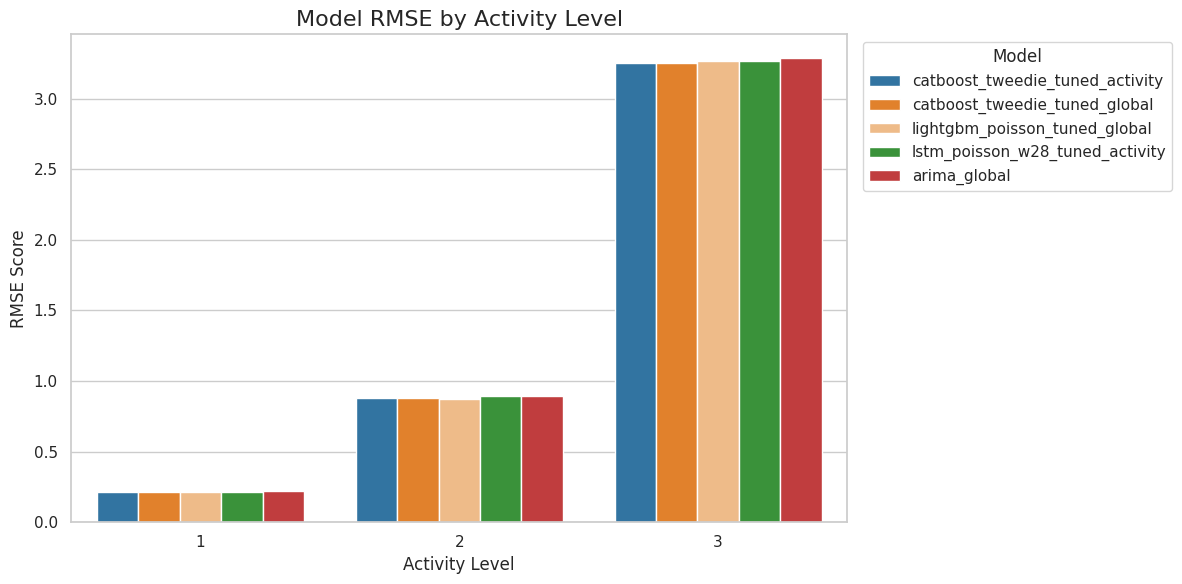

In [130]:
performance_per_activity_level(top_5_w_naive, metric='RMSE')


--- Mean RMSE per Model ---
                    displayname     RMSE
  lightgbm_poisson_tuned_global 1.108062
catboost_tweedie_tuned_activity 1.108621
lstm_poisson_w28_tuned_activity 1.114074
  catboost_tweedie_tuned_global 1.117741
      chronos2_fine_tuned_local 1.119205
                   arima_global 1.120102
             naive_weekly_local 1.394123
------------------------------



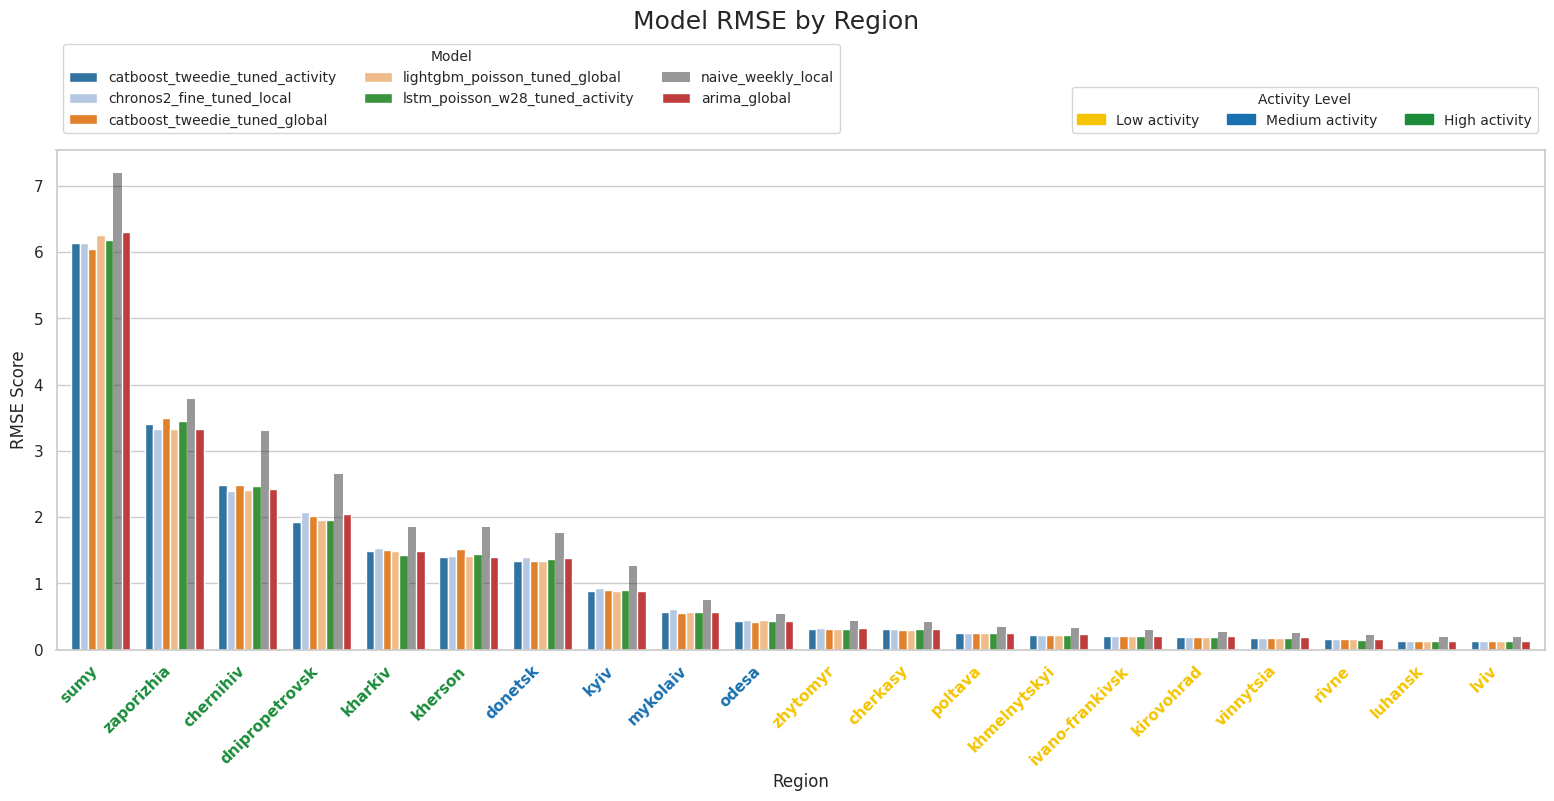


--- Mean MAE per Model ---
                    displayname      MAE
      chronos2_fine_tuned_local 0.713611
catboost_tweedie_tuned_activity 0.767909
  lightgbm_poisson_tuned_global 0.775707
lstm_poisson_w28_tuned_activity 0.777548
  catboost_tweedie_tuned_global 0.785818
                   arima_global 0.813287
             naive_weekly_local 0.894730
------------------------------



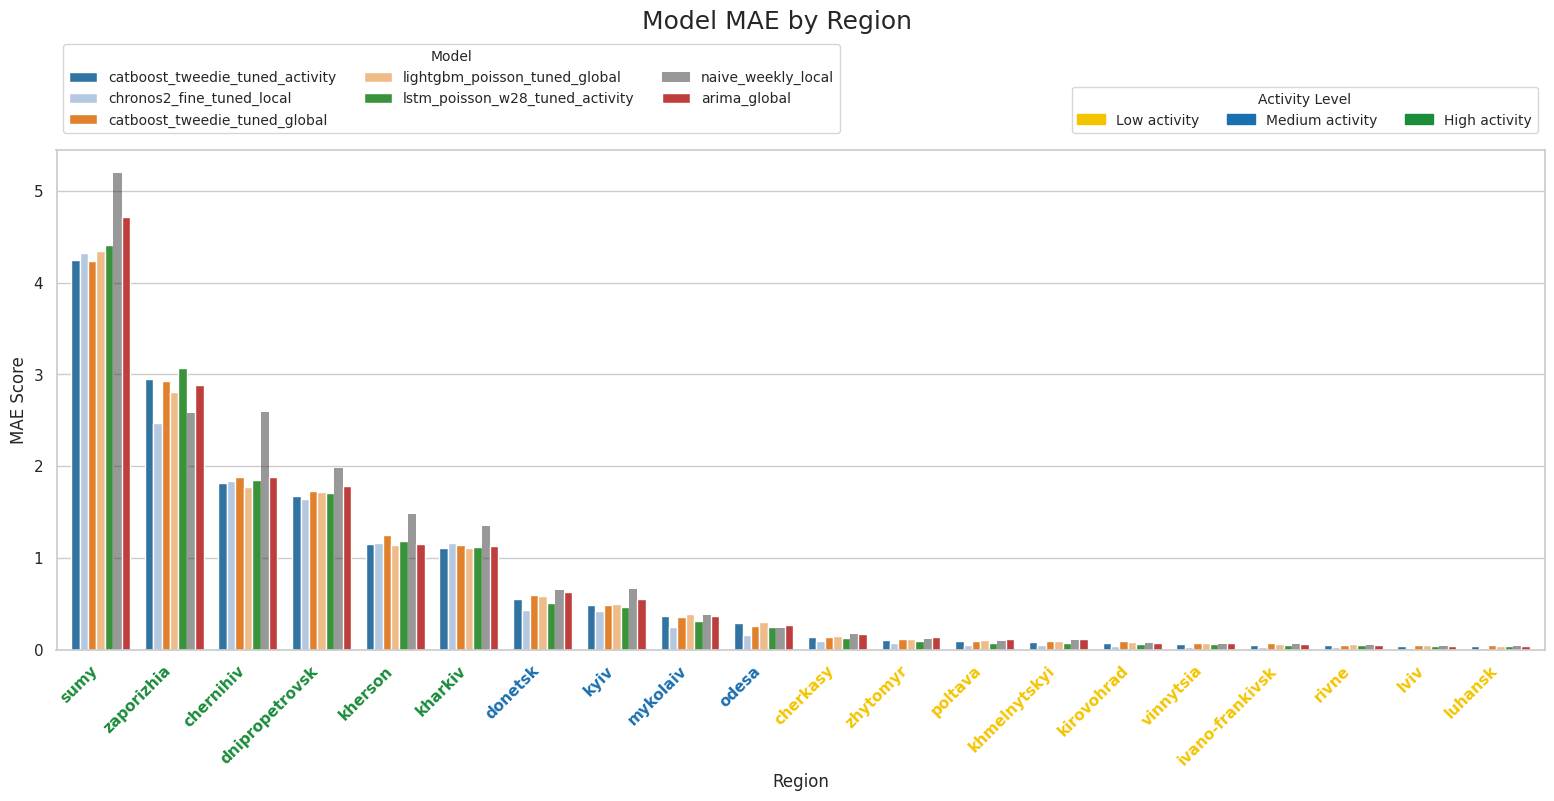

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches  # Needed for custom legend handles

EDGE_COLORS = { 1: '#f5c400', 2: '#1a6faf', 3: '#1a8c3a'}
LEVEL_LABELS = { 1: 'Low activity', 2: 'Medium activity', 3: 'High activity'}

def performance_per_region(top_5_df, metric='RMSE'):
    all_data = []

    for i in range(len(top_5_df)):
        res = top_5_df.iloc[i]
        paradigm = res['paradigm']
        model = res['model']
        modelname = res['Modelname']
        
        try:
            if modelname == 'finalhurdle':
                csv_path = f"./{modelname}/per_region_test_global_hurdle_cal.csv"
                df = pd.read_csv(csv_path)
            elif modelname == 'chronos2':
                csv_path = f"./{modelname}/per_region_{model}.csv"
                df = pd.read_csv(csv_path)
            else:
                csv_path = f"./{modelname}/per_region_test_{paradigm}_{model}.csv"
                df = pd.read_csv(csv_path)
            
            # Add the metadata as columns
            df['modelname'] = modelname
            df['model'] = model
            df['paradigm'] = paradigm
            df['displayname'] = f'{model}_{paradigm}'
            
            # Append data 
            all_data.append(df[['modelname', 'model', 'paradigm', 'region', 'displayname', metric]])
            
        except FileNotFoundError:
            print(f"Warning: Could not find {csv_path}. Skipping...")
            continue
        except KeyError as e:
            print(f"Error: Missing expected column {e} in {csv_path}.")
            continue
        except Exception as e:
            print(f"Error processing {modelname}: {e}")
            continue

    if not all_data:
        print("No data was collected. Check your file paths.")
        return

    combined_df = pd.concat(all_data, ignore_index=True)
    
    mean_per_model = combined_df.groupby('displayname')[metric].mean().reset_index()
    mean_per_model = mean_per_model.sort_values(by=metric)
    
    print(f"\n--- Mean {metric} per Model ---")
    print(mean_per_model.to_string(index=False))
    print("-" * 30 + "\n")

 
    combined_df['region'] = combined_df['region'].astype(str)
    

    region_order = (
        combined_df.groupby('region')[metric]
        .mean()
        .sort_values(ascending=False)
        .index.tolist()
    )

    
    sns.set_theme(style="whitegrid")
    
    plt.figure(figsize=(16, 10))
    
    ax = sns.barplot(
        data=combined_df, 
        x='region', 
        y=metric, 
        hue='displayname', 
        palette=MODEL_COLORS,
        order=region_order 
    )
    
    
    for patch in ax.patches:
        r, g, b, a = patch.get_facecolor()
        nr, ng, nb, na = NAIVE_COLOR
        TOLERANCE = 0.01
        if (abs(r - nr) < TOLERANCE) and (abs(g - ng) < TOLERANCE) and (abs(b - nb) < TOLERANCE):
            patch.set_alpha(0.5) 
            patch.set_edgecolor('none') 
            

    plt.suptitle(f"Model {metric} by Region", fontsize=18, y=0.89)
    
    plt.xlabel("Region", fontsize=12)
    plt.ylabel(f"{metric} Score", fontsize=12)
    
    plt.xticks(rotation=45, ha='right')

    for tick in ax.get_xticklabels():
        region_name = tick.get_text()
        # Note: Ensure 'activity_levels' is defined or passed into the function
        activity_tier = activity_levels.get(region_name, 0) 
        tick_color = EDGE_COLORS.get(activity_tier, '#222222')
        
        tick.set_color(tick_color)
        tick.set_fontweight('bold')

    model_handles, model_labels = ax.get_legend_handles_labels()

    activity_handles = []
    for level, label in LEVEL_LABELS.items():
        color = EDGE_COLORS.get(level, '#222222')
        patch = mpatches.Patch(color=color, label=label)
        activity_handles.append(patch)
        
    activity_legend = ax.legend(
        handles=activity_handles, 
        title='Activity Level', 
        bbox_to_anchor=(1.0, 1.02), 
        loc='lower right',
        ncol=3,                     
        fontsize='small',
        title_fontsize='small'
    )
    
    ax.add_artist(activity_legend)

    ax.legend(
        handles=model_handles,
        labels=model_labels,
        title='Model', 
        bbox_to_anchor=(0.0, 1.02), 
        loc='lower left',
        ncol=3,                     
        fontsize='small',          
        title_fontsize='small'     
    )
    
    ax.margins(x=0.01)

    # 2. Lower the 'top' margin to 0.75. This creates a generous 25% empty buffer 
    # at the top of the figure for the legends and suptitle to sit comfortably without overlapping.
    plt.subplots_adjust(left=0.05, right=0.98, top=0.75, bottom=0.25) 
    
    plt.savefig(f"./figs/{metric}_per_region.svg", bbox_inches='tight')
    plt.show()

performance_per_region(top_5_w_naive, metric="RMSE")
performance_per_region(top_5_w_naive, metric="MAE")

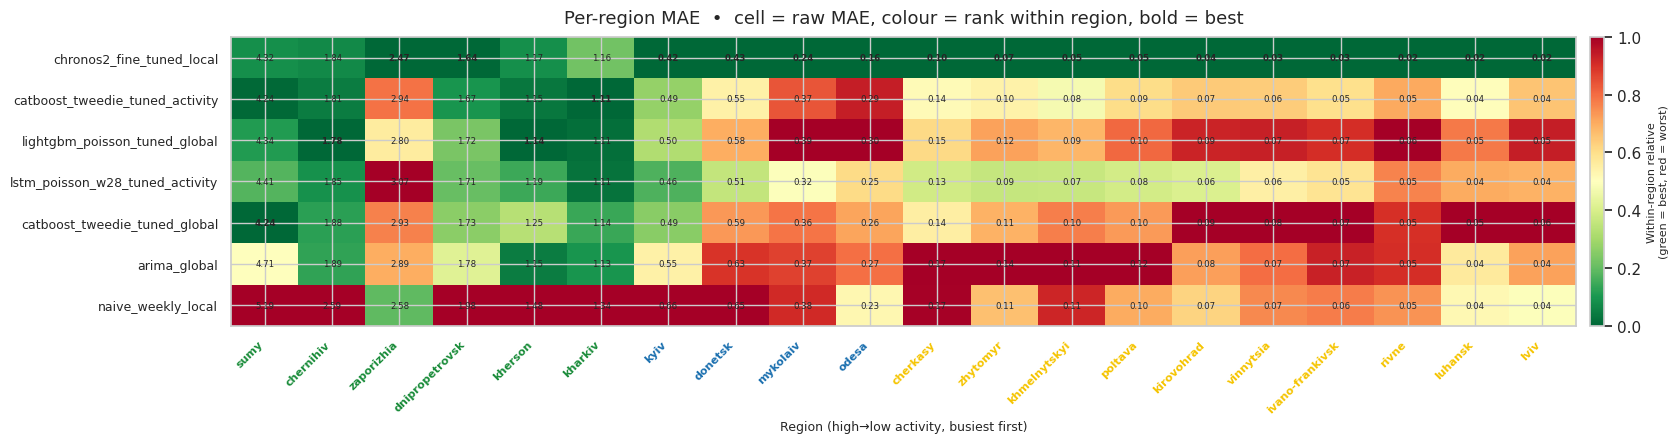

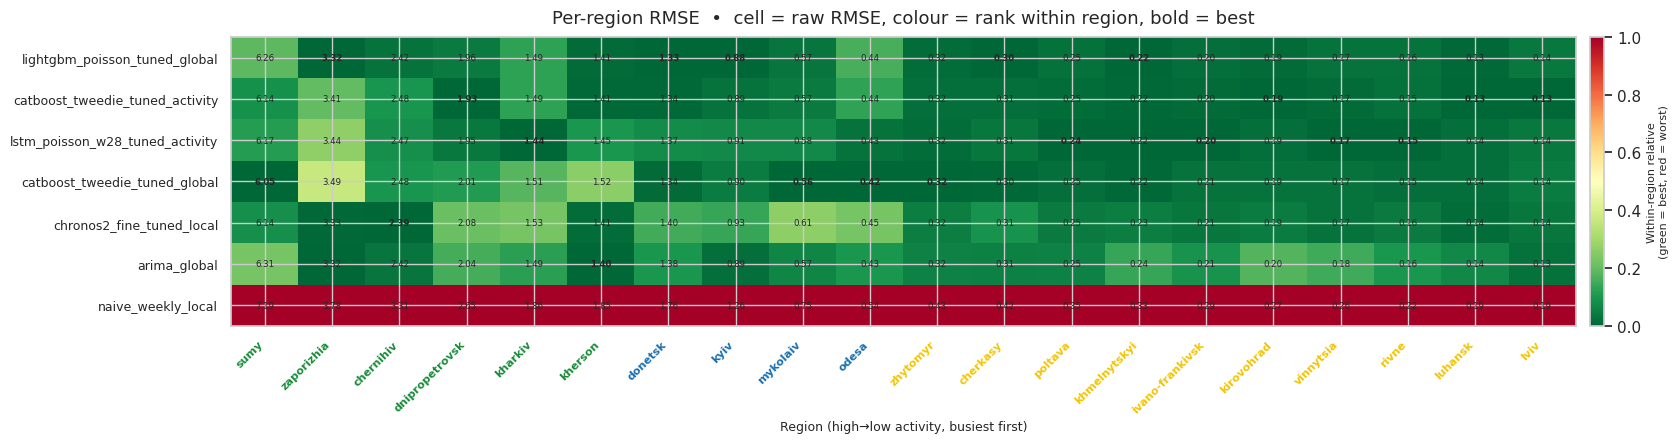

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Tier colours for the region tick labels (0=little ... 3=high), matches EDGE_COLORS
TIER_COL = {0: '#888888', 1: '#f5c400', 2: '#1a6faf', 3: '#1a8c3a'}
NAIVE_NAME = 'naive_weekly_local'   # reference row for the skill score


def _load_region_series(res, metric):
    """Per-region metric Series for one model row (reuses the existing path logic)."""
    mn, pg, md = res['Modelname'], res['paradigm'], res['model']
    if mn == 'finalhurdle':
        path = f"./{mn}/per_region_test_global_hurdle_cal.csv"
    elif mn == 'chronos2':
        path = f"./{mn}/per_region_{md}.csv"
    else:
        path = f"./{mn}/per_region_test_{pg}_{md}.csv"
    return pd.read_csv(path).set_index('region')[metric]


def build_region_matrix(top_5_df, metric):
    """region x model matrix of the chosen metric."""
    series = {}
    for i in range(len(top_5_df)):
        res = top_5_df.iloc[i]
        name = f"{res['model']}_{res['paradigm']}"
        try:
            series[name] = _load_region_series(res, metric)
        except FileNotFoundError:
            print(f"Warning: per-region file missing for {name}. Skipping...")
    return pd.DataFrame(series)


def _style_region_ticks(ax):
    for t in ax.get_xticklabels():
        t.set_color(TIER_COL.get(activity_levels.get(t.get_text(), 0), '#222'))
        t.set_fontweight('bold')


def _region_order(mat, ref):
    # high -> low activity, then busiest (largest reference error) first
    return sorted(mat.index,
                  key=lambda r: (-activity_levels.get(r, 0), -ref.get(r, mat.loc[r].mean())))


def performance_heatmap(top_5_df, metric='MAE', save=True):
    """Raw MAE/RMSE per region; colour = rank within region (green=best), bold = best model."""
    mat = build_region_matrix(top_5_df, metric)                  # region x model
    ref = mat[NAIVE_NAME] if NAIVE_NAME in mat.columns else mat.mean(axis=1)
    mat = mat.loc[_region_order(mat, ref)]
    mat = mat[mat.mean().sort_values().index]                    # best (lowest) model first
    M = mat.T                                                    # model x region
    rel = (M - M.min(axis=0)) / (M.max(axis=0) - M.min(axis=0)).replace(0, np.nan)
    best = M.idxmin(axis=0)

    fig, ax = plt.subplots(figsize=(17, 4.6))
    im = ax.imshow(rel.values, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(M.shape[1])); ax.set_yticks(range(M.shape[0]))
    ax.set_xticklabels(M.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(M.index, fontsize=9)
    _style_region_ticks(ax)
    for j, reg in enumerate(M.columns):
        for i, mod in enumerate(M.index):
            ax.text(j, i, f"{M.values[i, j]:.2f}", ha='center', va='center', fontsize=6.2,
                    fontweight='bold' if best[reg] == mod else 'normal')
    cb = fig.colorbar(im, ax=ax, pad=0.01, fraction=0.025)
    cb.set_label('Within-region relative\n(green = best, red = worst)', fontsize=8)
    ax.set_title(f"Per-region {metric}  •  cell = raw {metric}, colour = rank within region, bold = best",
                 fontsize=13, pad=10)
    ax.set_xlabel("Region (high→low activity, busiest first)", fontsize=9)
    plt.tight_layout()
    if save:
        plt.savefig(f"./figs/{metric}_per_region_heatmap.svg", bbox_inches='tight')
    plt.show()


performance_heatmap(top_5_w_naive, metric='MAE')
performance_heatmap(top_5_w_naive, metric='RMSE')

### Per-region bar charts, split by activity tier (3 tiers × 2 metrics)

Same grouped-bar comparison as above, but split into one subplot per activity tier so each panel gets its own y-scale (the high-activity regions no longer crush the rest). Layout is 3 rows (High / Medium / Low activity) × 2 columns (RMSE, MAE), with a value label on every bar.

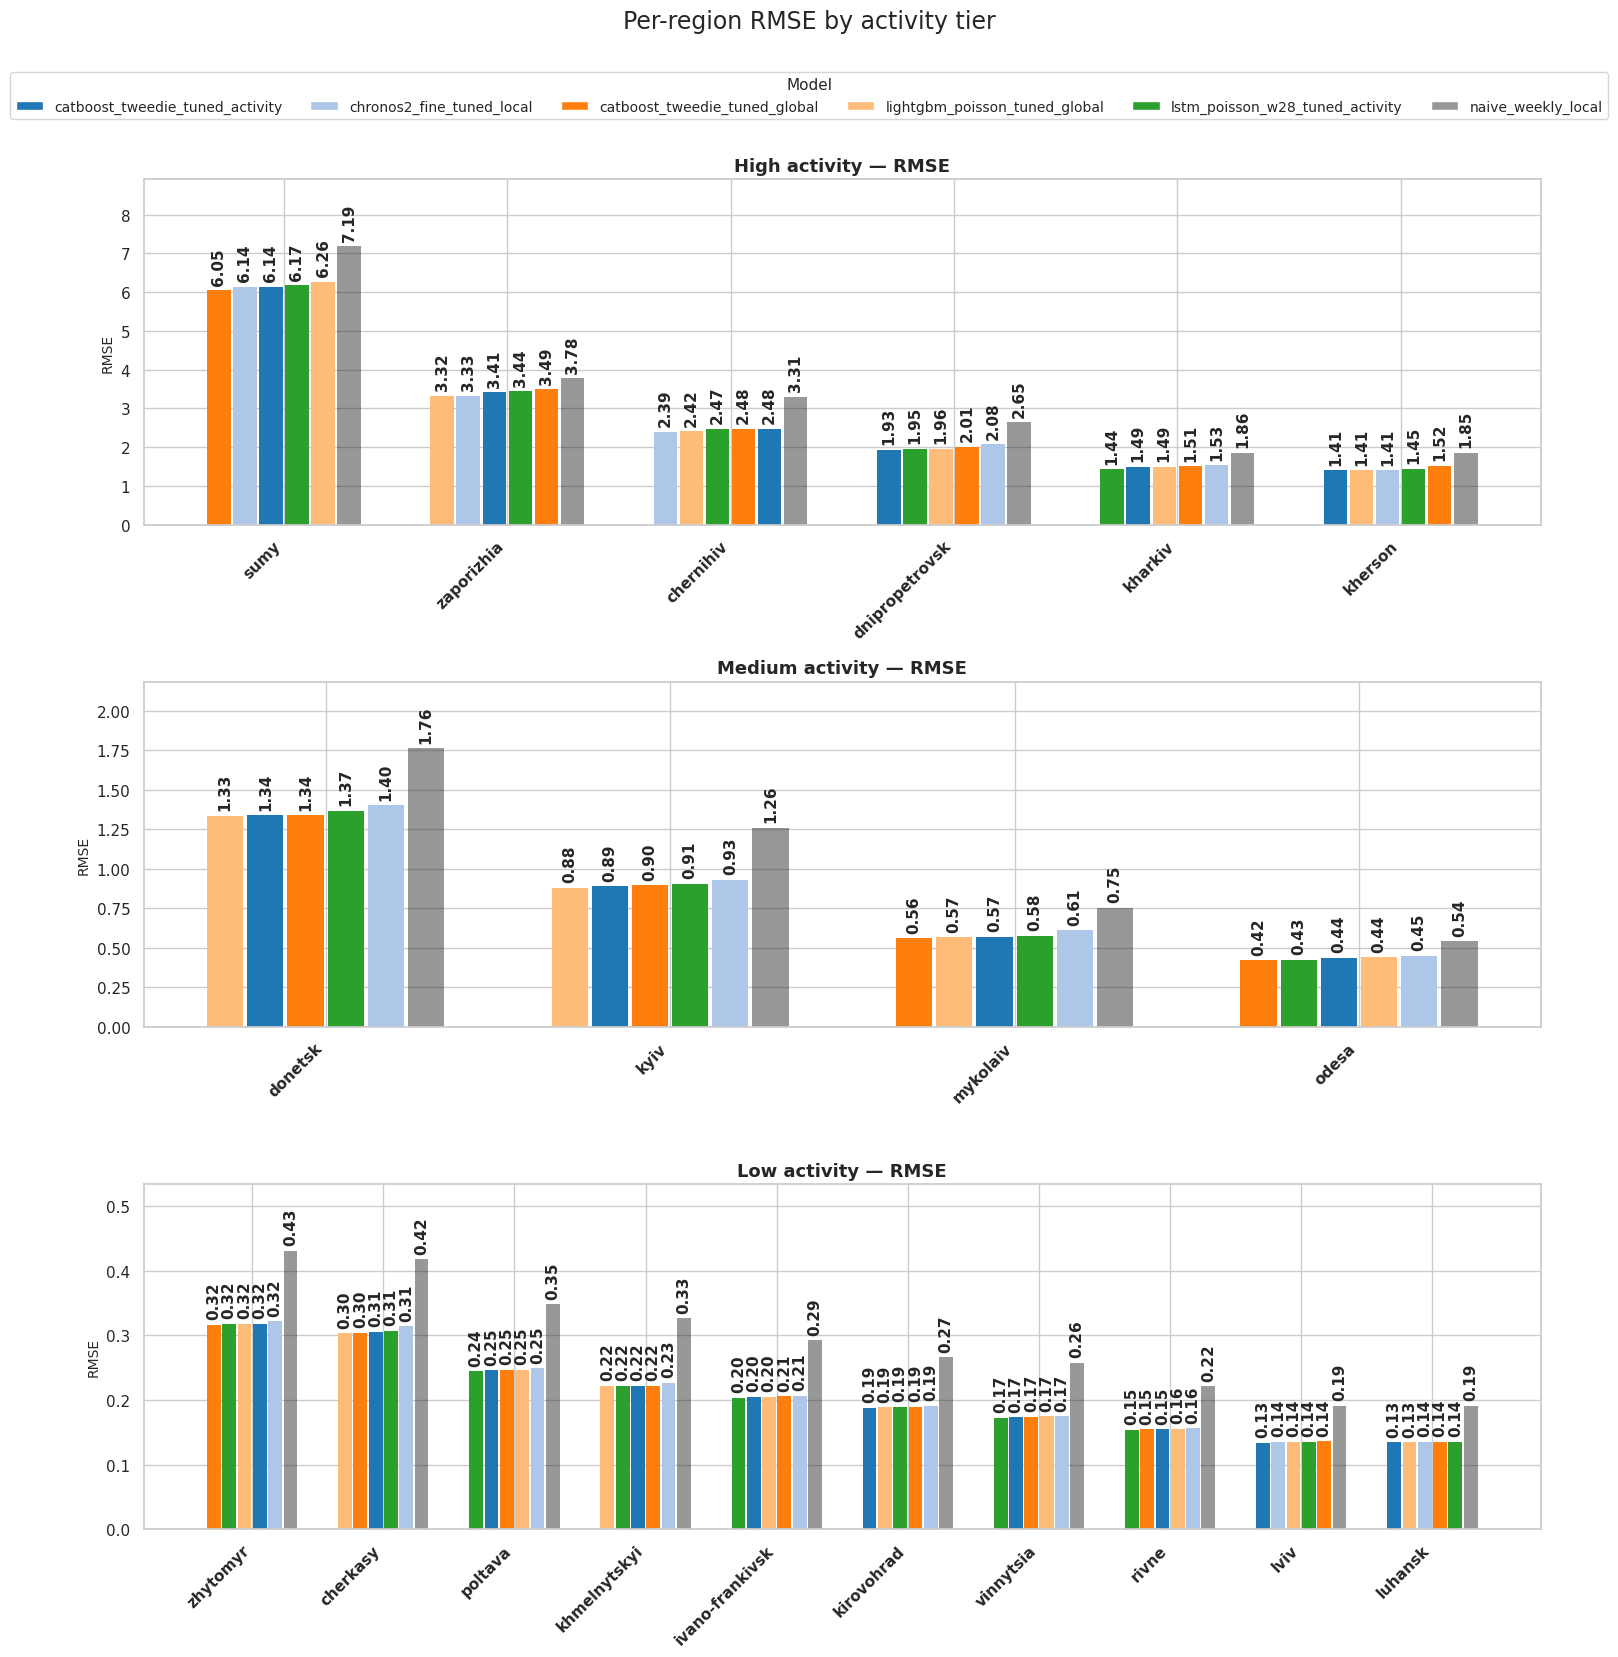

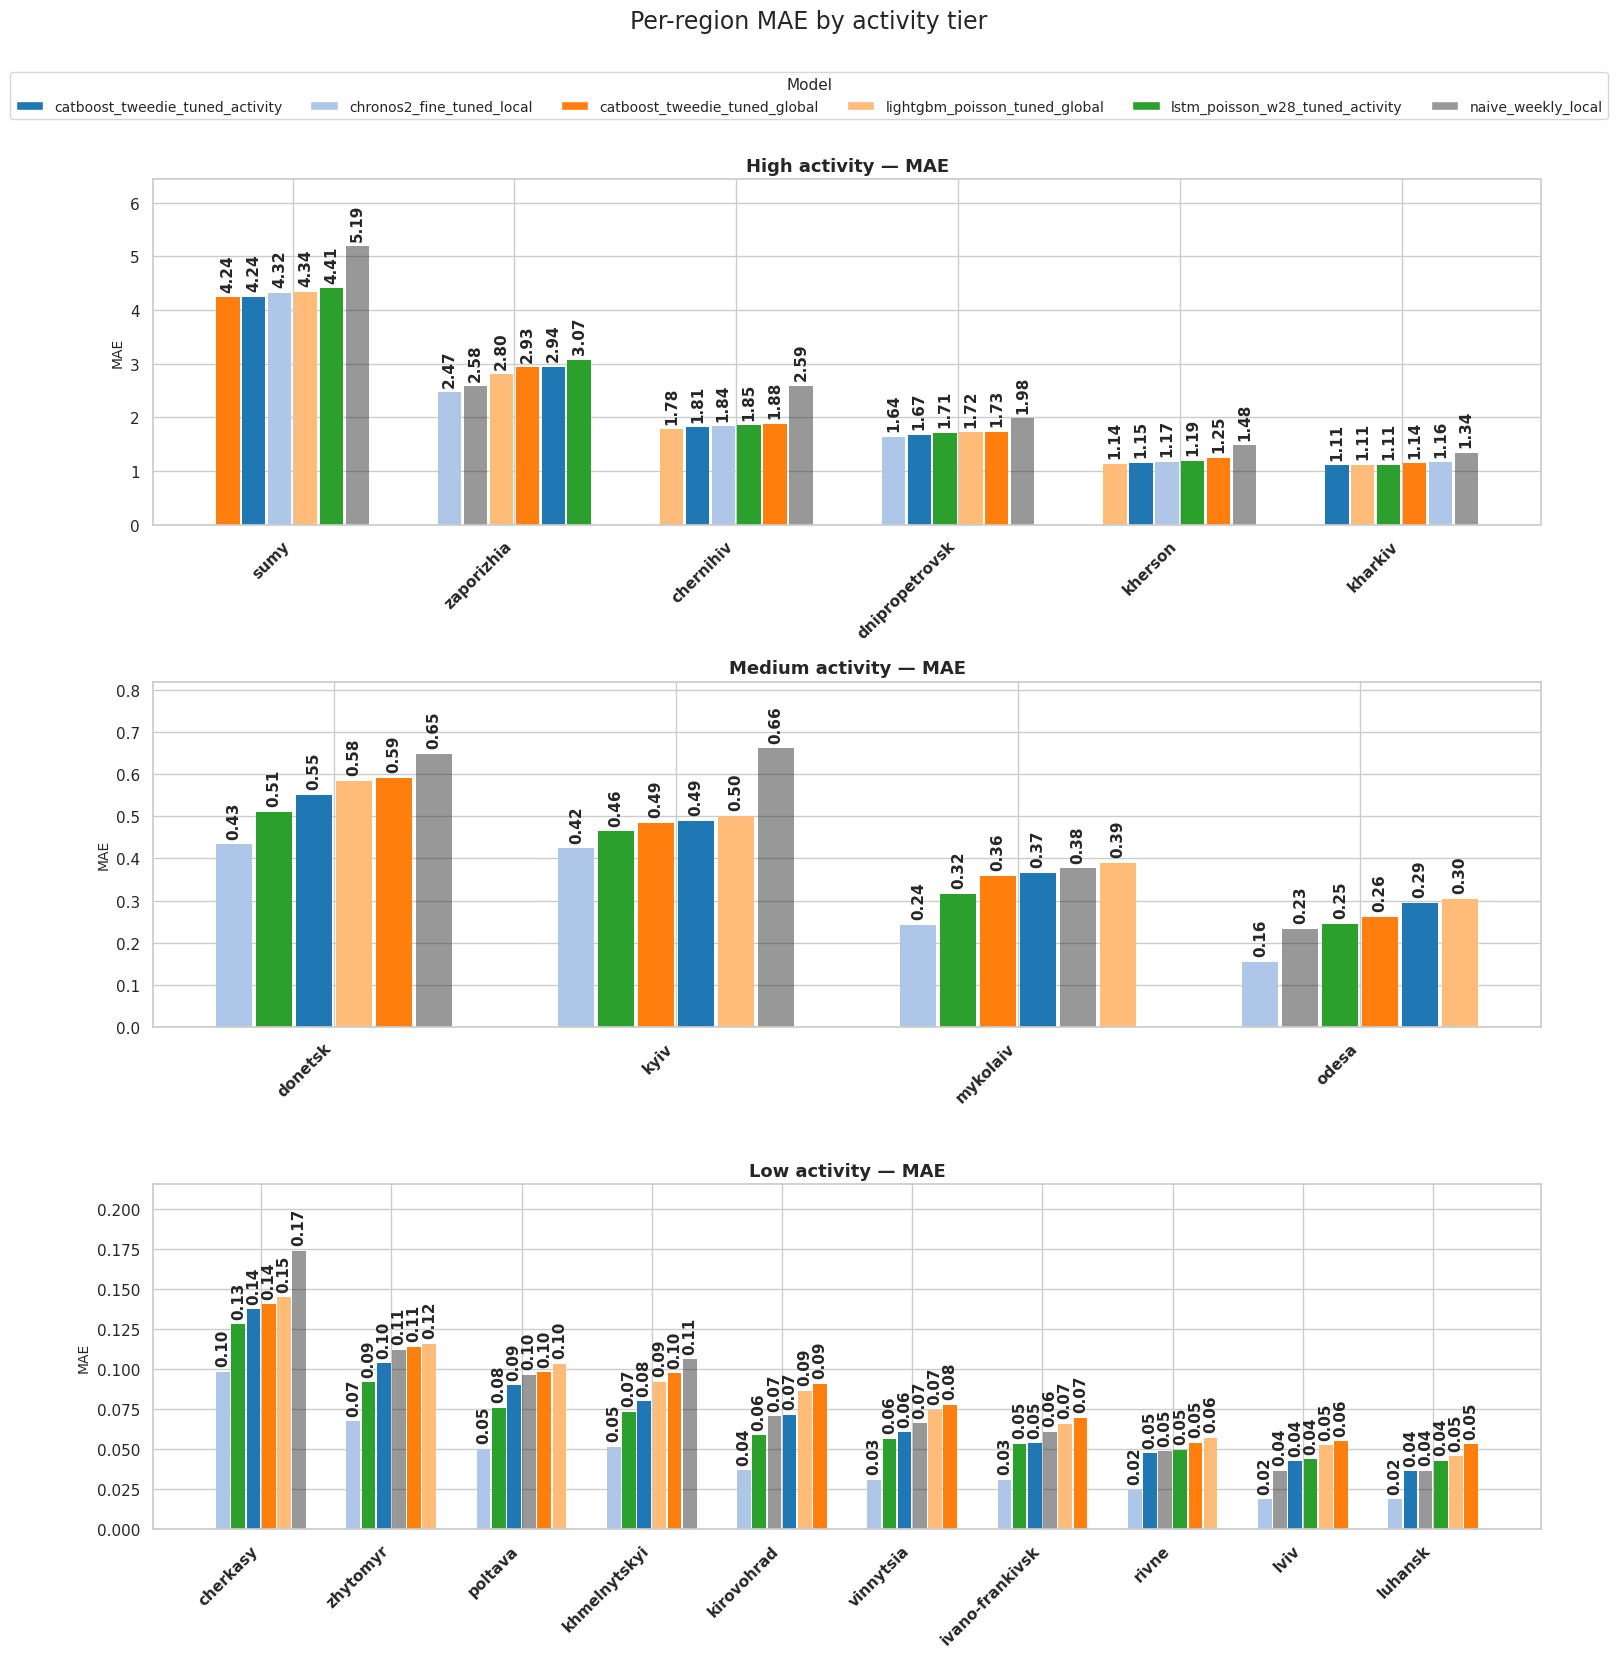

In [133]:
def performance_per_region_grid(top_5_df, metrics=('RMSE', 'MAE'), tiers=(3, 2, 1),
                                exclude=('arima_global',), save=True):
    """One figure per metric: activity tiers stacked vertically (3 rows x 1 col).

    Splitting RMSE and MAE into separate figures gives each tier row the full
    page width, so the dense low-activity tier (many regions x many models) stays
    readable. Within each region bars are sorted best->worst (worst, usually the
    grey see-through naive baseline, sits last); value label on every bar.
    """
    import matplotlib.patches as mpatches
    sns.set_theme(style="whitegrid")
    mats = {m: build_region_matrix(top_5_df, m) for m in metrics}
    models = [c for c in next(iter(mats.values())).columns if c not in exclude]
    n = len(models)
    group_w = 0.7                 # narrower group -> more room between regions
    width = group_w / n

    handles = [mpatches.Patch(facecolor=MODEL_COLORS[m], label=m) for m in models]

    for metric in metrics:
        fig, axes = plt.subplots(len(tiers), 1, figsize=(15, 16), squeeze=False)
        for ri, tier in enumerate(tiers):
            ax = axes[ri][0]
            mat = mats[metric][models]
            regions = [r for r in mat.index if activity_levels.get(r, 0) == tier]
            regions = sorted(regions, key=lambda r: mat.loc[r].mean(), reverse=True)
            for gi, region in enumerate(regions):
                vals = mat.loc[region, models].sort_values()   # ascending -> worst last
                for k, mdl in enumerate(vals.index):
                    x = gi + (k - (n - 1) / 2) * width
                    ax.bar(x, vals[mdl], width=width * 0.9, color=MODEL_COLORS[mdl],
                           edgecolor='none')
                    ax.annotate(f"{vals[mdl]:.2f}", (x, vals[mdl]),
                                textcoords='offset points', xytext=(0, 4),
                                ha='center', va='bottom', rotation=90,
                                fontsize=11, fontweight='bold')
            ax.set_xticks(range(len(regions)))
            ax.set_xticklabels(regions, rotation=45, ha='right', fontweight='bold')
            ax.margins(y=0.24)
            ax.set_title(f"{LEVEL_LABELS.get(tier, tier)} — {metric}", fontsize=13, fontweight='bold')
            ax.set_xlabel(''); ax.set_ylabel(metric, fontsize=10)

        fig.legend(handles=handles, title='Model', loc='upper center', ncol=len(models),
                   bbox_to_anchor=(0.5, 1.0), fontsize=10, title_fontsize=11)
        fig.suptitle(f"Per-region {metric} by activity tier", fontsize=17, y=1.035)
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        if save:
            plt.savefig(f"./figs/per_region_grid_by_tier_{metric}.svg", bbox_inches='tight')
        plt.show()


performance_per_region_grid(top_5_w_naive, metrics=('RMSE', 'MAE'))


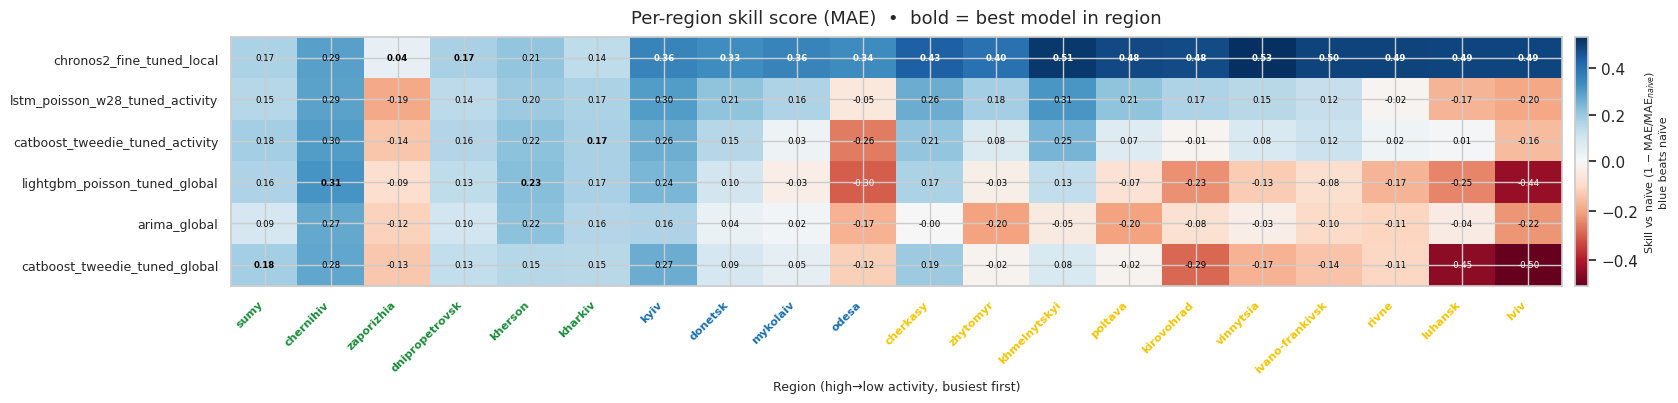

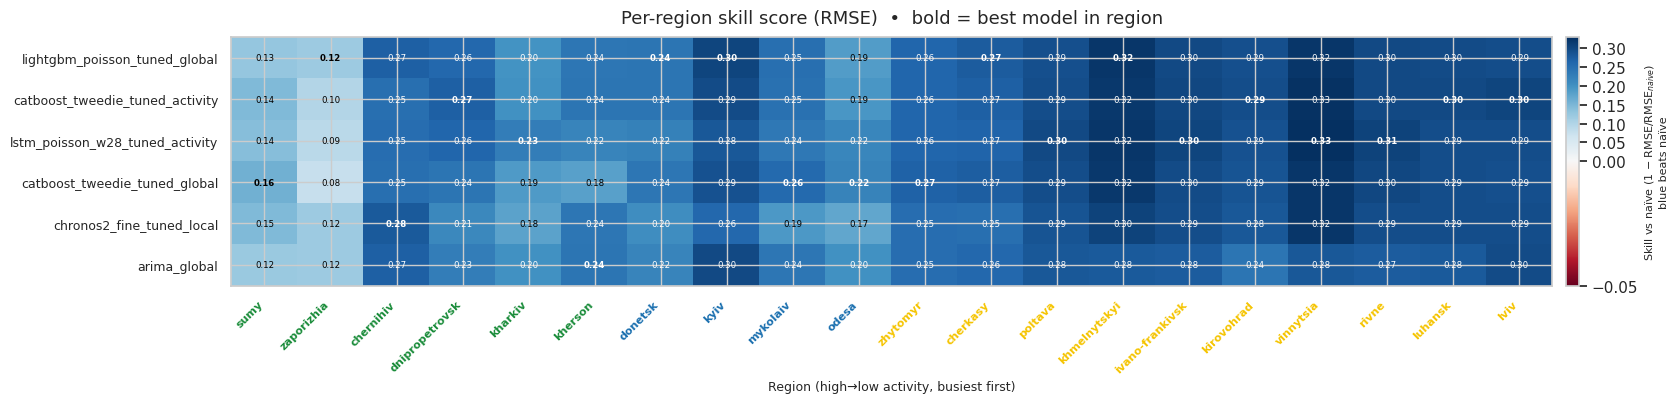

In [134]:


def skillscore_heatmap(top_5_df, metric='MAE', save=True):
    """Skill score vs naive_weekly: 1 - metric/metric_naive (blue beats naive), bold = best."""
    mat = build_region_matrix(top_5_df, metric)
    if NAIVE_NAME not in mat.columns:
        print(f"'{NAIVE_NAME}' not in selection; cannot compute skill score.")
        return
    naive = mat[NAIVE_NAME]
    skill = (1 - mat.div(naive, axis=0)).drop(columns=[NAIVE_NAME])
    skill = skill.loc[_region_order(mat, naive)]
    skill = skill[skill.mean().sort_values(ascending=False).index]   # best model first
    M = skill.T
    best = M.idxmax(axis=0)

    norm = TwoSlopeNorm(vmin=min(-0.05, M.values.min()), vcenter=0,
                        vmax=max(0.05, M.values.max()))
    fig, ax = plt.subplots(figsize=(17, 4.2))
    im = ax.imshow(M.values, cmap='RdBu', norm=norm, aspect='auto')
    ax.set_xticks(range(M.shape[1])); ax.set_yticks(range(M.shape[0]))
    ax.set_xticklabels(M.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(M.index, fontsize=9)
    _style_region_ticks(ax)
    for j, reg in enumerate(M.columns):
        for i, mod in enumerate(M.index):
            v = M.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=6.2,
                    color='white' if abs(norm(v) - 0.5) > 0.3 else 'black',
                    fontweight='bold' if best[reg] == mod else 'normal')
    cb = fig.colorbar(im, ax=ax, pad=0.01, fraction=0.025)
    cb.set_label(f'Skill vs naïve (1 − {metric}/{metric}$_{{naive}}$)\nblue beats naïve',
                 fontsize=8)
    ax.set_title(f"Per-region skill score ({metric})  •  bold = best model in region",
                 fontsize=13, pad=10)
    ax.set_xlabel("Region (high→low activity, busiest first)", fontsize=9)
    plt.tight_layout()
    if save:
        plt.savefig(f"./figs/skillscore_{metric}_per_region_heatmap.svg", bbox_inches='tight')
    plt.show()


skillscore_heatmap(top_5_w_naive, metric='MAE')
skillscore_heatmap(top_5_w_naive, metric='RMSE')

### Multivariate vs ARIMA, by activity tier (complements the Sub-Q1 feature-importance finding)

ARIMA is a purely autoregressive baseline, so comparing the multivariate models *against ARIMA* (rather than against the naïve baseline) isolates the value added by exogenous / cross-series information. Skill is `1 - metric/metric_ARIMA` (>0 beats ARIMA). The line summary shows the gap by activity tier; the heatmap gives the per-region detail.

**Reading:** in the high-activity **Tier 3** regions (which dominate aggregate error) the multivariate models sit near ARIMA parity — recent local history is nearly sufficient where strikes are frequent — while their advantage over ARIMA widens in the sparser **Tier 2 / Tier 1** regions. The effect is clear on MAE; on RMSE ARIMA is broadly competitive, with a small multivariate edge only in the sparsest tier.

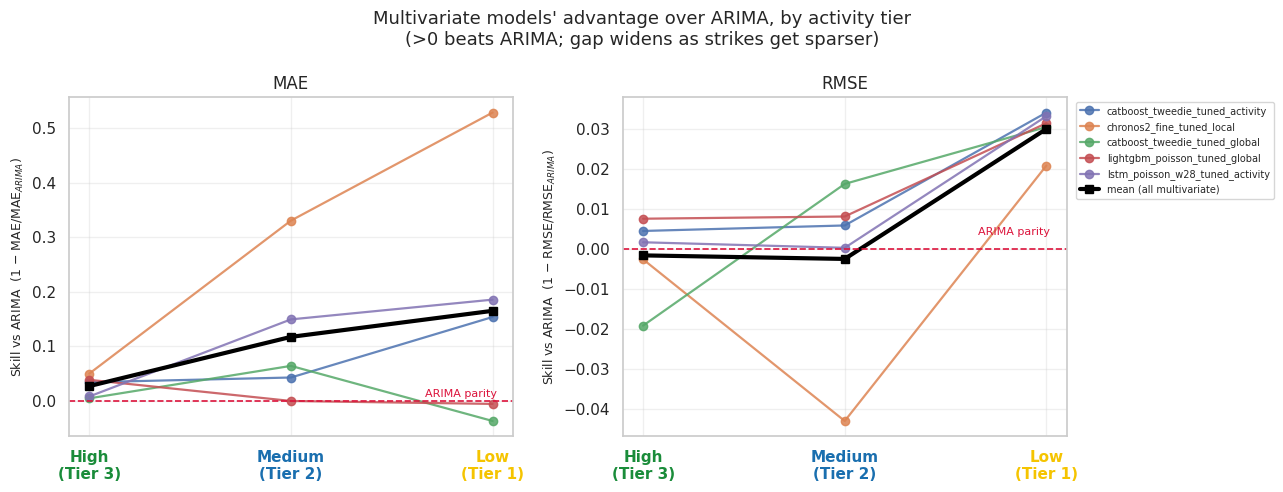

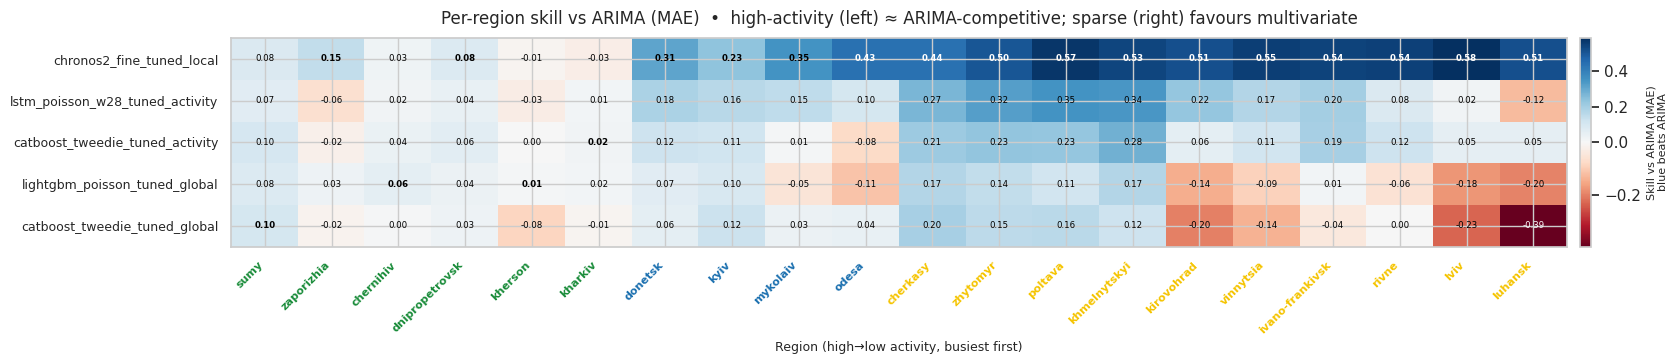

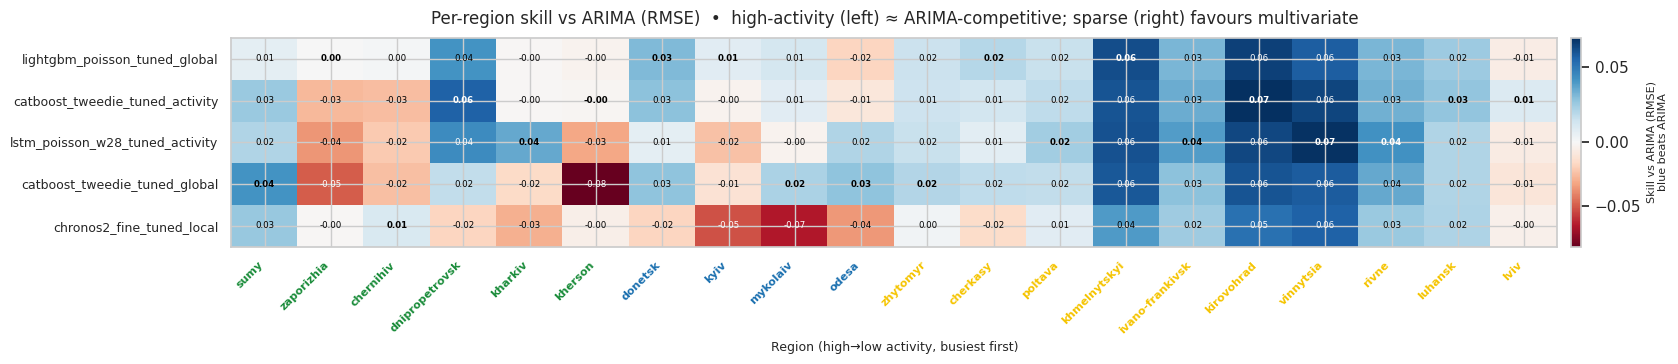

In [135]:
ARIMA_NAME = 'arima_global'
TIER_LABELS = {3: 'High\n(Tier 3)', 2: 'Medium\n(Tier 2)', 1: 'Low\n(Tier 1)'}


def _multivariate_skill_vs_arima(top_5_df, metric):
    """region x model skill (1 - metric/metric_ARIMA); ARIMA & naive dropped from the models."""
    mat = build_region_matrix(top_5_df, metric)
    if ARIMA_NAME not in mat.columns:
        raise KeyError(f"'{ARIMA_NAME}' not in selection; add arima to top_5_w_naive.")
    arima = mat[ARIMA_NAME]
    drop = [c for c in (ARIMA_NAME, NAIVE_NAME) if c in mat.columns]
    skill = (1 - mat.div(arima, axis=0)).drop(columns=drop)
    return skill, arima


def skill_vs_arima_by_tier(top_5_df, metrics=('MAE', 'RMSE'), save=True):
    """Mean multivariate skill vs ARIMA per activity tier (one line per model + overall mean)."""
    fig, axes = plt.subplots(1, len(metrics), figsize=(6.5 * len(metrics), 5), sharex=True)
    if len(metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics):
        skill, _ = _multivariate_skill_vs_arima(top_5_df, metric)
        tier = skill.index.map(lambda r: activity_levels.get(r, 0))
        g = skill.groupby(tier).mean()
        order = [t for t in (3, 2, 1) if t in g.index]
        x = range(len(order))
        for col in skill.columns:
            ax.plot(x, [g.loc[t, col] for t in order], marker='o', lw=1.6, alpha=.85, label=col)
        mean_by_tier = g.mean(axis=1)
        ax.plot(x, [mean_by_tier[t] for t in order], marker='s', lw=3, color='black',
                label='mean (all multivariate)')
        ax.axhline(0, ls='--', color='crimson', lw=1.2)
        ax.text(len(order) - 0.98, 0.003, 'ARIMA parity', color='crimson', fontsize=8,
                va='bottom', ha='right')
        ax.set_xticks(list(x)); ax.set_xticklabels([TIER_LABELS[t] for t in order])
        for tl, t in zip(ax.get_xticklabels(), order):
            tl.set_color(TIER_COL[t]); tl.set_fontweight('bold')
        ax.set_title(metric, fontsize=12)
        ax.set_ylabel(f'Skill vs ARIMA  (1 − {metric}/{metric}$_{{ARIMA}}$)', fontsize=9)
        ax.grid(alpha=.3)
    axes[-1].legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.01, 1))
    fig.suptitle("Multivariate models' advantage over ARIMA, by activity tier\n"
                 "(>0 beats ARIMA; gap widens as strikes get sparser)", fontsize=13)
    plt.tight_layout()
    if save:
        plt.savefig("./figs/skill_vs_arima_by_tier.svg", bbox_inches='tight')
    plt.show()


def skill_vs_arima_heatmap(top_5_df, metric='MAE', save=True):
    """Per-region skill vs ARIMA; regions high->low activity, bold = best model in region."""
    skill, arima = _multivariate_skill_vs_arima(top_5_df, metric)
    order = sorted(skill.index, key=lambda r: (-activity_levels.get(r, 0), -arima.get(r, 0)))
    skill = skill.loc[order]
    skill = skill[skill.mean().sort_values(ascending=False).index]
    M = skill.T
    best = M.idxmax(axis=0)
    norm = TwoSlopeNorm(vmin=min(-0.05, M.values.min()), vcenter=0, vmax=max(0.05, M.values.max()))
    fig, ax = plt.subplots(figsize=(17, 3.8))
    im = ax.imshow(M.values, cmap='RdBu', norm=norm, aspect='auto')
    ax.set_xticks(range(M.shape[1])); ax.set_yticks(range(M.shape[0]))
    ax.set_xticklabels(M.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(M.index, fontsize=9)
    _style_region_ticks(ax)
    for j, reg in enumerate(M.columns):
        for i, mod in enumerate(M.index):
            v = M.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=6.2,
                    color='white' if abs(norm(v) - 0.5) > 0.3 else 'black',
                    fontweight='bold' if best[reg] == mod else 'normal')
    cb = fig.colorbar(im, ax=ax, pad=0.01, fraction=0.025)
    cb.set_label(f'Skill vs ARIMA ({metric})\nblue beats ARIMA', fontsize=8)
    ax.set_title(f"Per-region skill vs ARIMA ({metric})  •  high-activity (left) ≈ ARIMA-competitive; "
                 f"sparse (right) favours multivariate", fontsize=12, pad=10)
    ax.set_xlabel("Region (high→low activity, busiest first)", fontsize=9)
    plt.tight_layout()
    if save:
        plt.savefig(f"./figs/skill_vs_arima_{metric}_heatmap.svg", bbox_inches='tight')
    plt.show()


skill_vs_arima_by_tier(top_5_w_naive, metrics=('MAE', 'RMSE'))
skill_vs_arima_heatmap(top_5_w_naive, metric='MAE')
skill_vs_arima_heatmap(top_5_w_naive, metric='RMSE')

In [136]:
top_5_df

,Modelname,paradigm,model,SkillScore,mae,rmse
0,gbdt,activity,catboost_tweedie_tuned,0.169634,0.767909,1.830539
1,chronos2,local,chronos2_fine_tuned,0.169486,0.713611,1.830864
2,gbdt,global,catboost_tweedie_tuned,0.169411,0.785818,1.831029
3,gbdt,global,lightgbm_poisson_tuned,0.165593,0.775707,1.839445
4,lstm,activity,lstm_poisson_w28_tuned,0.165131,0.777548,1.840464


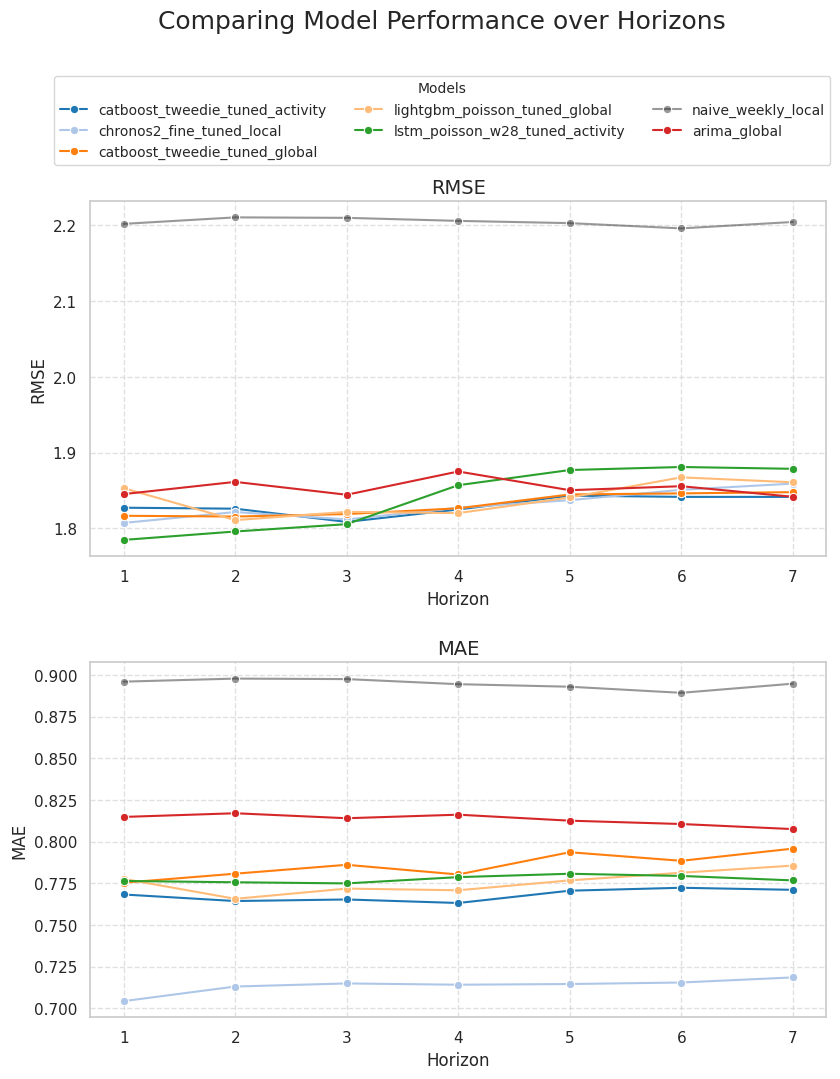

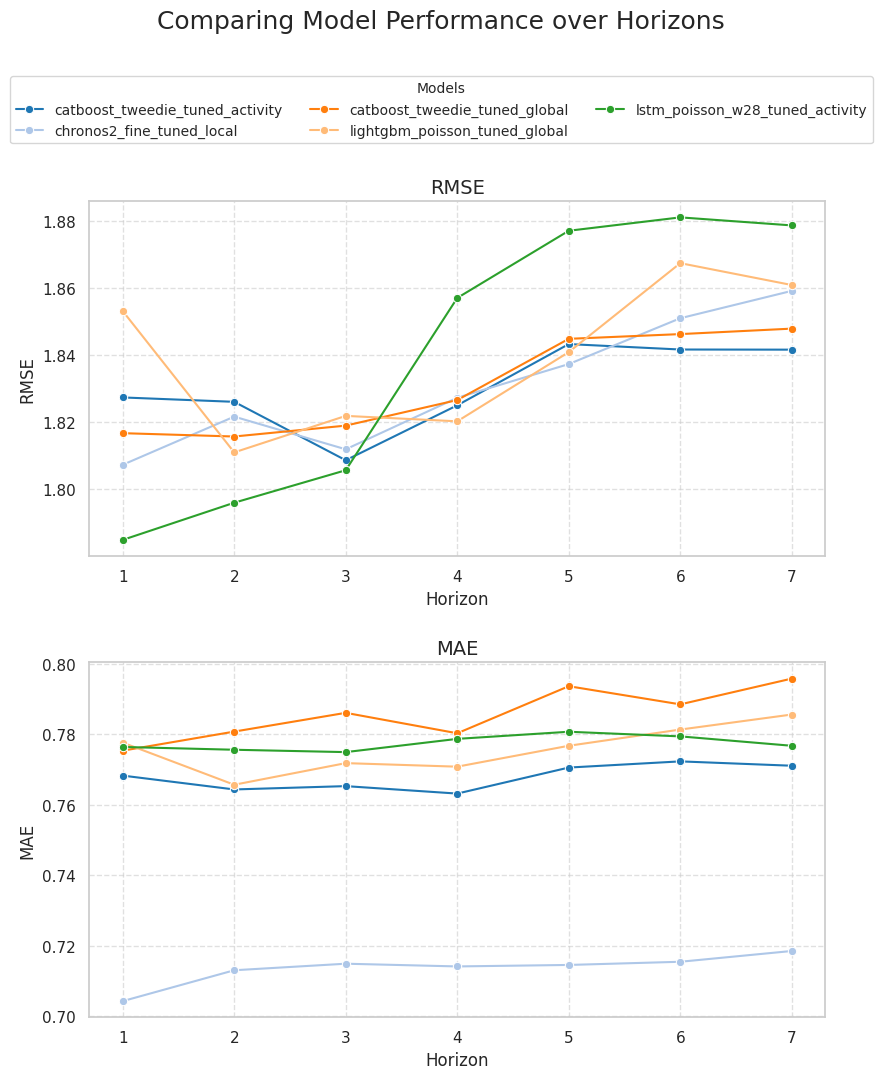

In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_horizon_results(top_5_df, metrics=['MAE', 'RMSE'], per_activity=False, save_fig_name=""):
    """
    Loops through top_5_df and loads the corresponding CSVs.
    If per_activity=True: Generates a separate 2x1 subplot per model over horizons.
    If per_activity=False: Generates a single 2x1 subplot comparing ALL models over horizons.
    """
    
    # 1. Initialize a 2x1 grid for the combined plot BEFORE the loop
    if not per_activity:
        fig, axes = plt.subplots(2, 1, figsize=(8, 12))
        
    for i in range(len(top_5_df)):
        res = top_5_df.iloc[i]
        paradigm = res['paradigm']
        model = res['model']
        modelname = res['Modelname']
        
        # Load the appropriate dataframe
        if model == "finalhurdle":
             csv_path = f"./{modelname}/per_horizon_test_global_hurdle_cal.csv" 
        elif modelname == 'chronos2':
            csv_path = f"./{modelname}/per_horizon_{model}.csv"
        elif per_activity:
            csv_path = f"./{modelname}/per_activity_horizon_test_{paradigm}_{model}.csv"
        else:
            csv_path = f"./{modelname}/per_horizon_test_{paradigm}_{model}.csv"
            
        df = pd.read_csv(csv_path)
        
        # --- LOGIC FOR PER_ACTIVITY = TRUE ---
        if per_activity:
            fig, axes = plt.subplots(2, 1, figsize=(8, 12))
            
            # Plot each metric on its corresponding axis
            for ax, metric in zip(axes, metrics):
                sns.lineplot(
                    data=df, x='horizon', y=metric, 
                    hue='activity_level', marker='o', linewidth=2,
                    palette=MODEL_COLORS, ax=ax
                )
                
                ax.set_title(f"{metric}", fontsize=14)
                ax.set_xlabel("Horizon", fontsize=12)
                ax.set_ylabel(metric, fontsize=12)
                ax.set_xticks(df['horizon'].unique()) 
                ax.grid(True, linestyle='--', alpha=0.6)

            # Extract handles for a single shared legend, then remove the individual ones
            handles, labels = axes[0].get_legend_handles_labels()
            axes[0].get_legend().remove()
            if axes[1].get_legend(): 
                axes[1].get_legend().remove()
            
            # Global Title and Shared Legend
            fig.suptitle(f"Performance over Horizon by Activity Level\n({modelname} | {paradigm} | {model})", fontsize=16, y=0.97)
            fig.legend(
                handles, labels, title="Activity Level", 
                bbox_to_anchor=(0.5, 0.90), # Anchored slightly below the suptitle
                loc='upper center', ncol=3
            )
            
            # Adjust layout: extra top margin for title/legend, hspace for gap between plots
            plt.subplots_adjust(left=0.06, right=0.98, top=0.80, bottom=0.12, hspace=0.3)
            
            if save_fig_name:
                plt.savefig(f"./figs/{model}_{save_fig_name}", bbox_inches='tight')
            
            plt.show()
            
        # --- LOGIC FOR PER_ACTIVITY = FALSE ---
        else:
            model_key = f"{model}_{paradigm}"
            
            # Plot each metric on its corresponding axis
            for ax, metric in zip(axes, metrics):
                sns.lineplot(
                    data=df, x='horizon', y=metric, 
                    label=model_key, marker='o', 
                    color=MODEL_COLORS[model_key], ax=ax
                )

    # Finalize the combined plot after the loop finishes
    if not per_activity:
        for ax, metric in zip(axes, metrics):
            ax.set_title(f"{metric}", fontsize=14)
            ax.set_xlabel("Horizon", fontsize=12)
            ax.set_ylabel(metric, fontsize=12)
            ax.set_xticks(df['horizon'].unique()) 
            ax.grid(True, linestyle='--', alpha=0.6)
            
        # Extract handles for a single shared legend, then remove individual ones
        handles, labels = axes[0].get_legend_handles_labels()
        axes[0].get_legend().remove()
        if axes[1].get_legend(): 
            axes[1].get_legend().remove()

        # Global Title and Shared Legend
        fig.suptitle("Comparing Model Performance over Horizons", fontsize=18, y=0.96)
        fig.legend(
            handles, labels, title="Models", 
            bbox_to_anchor=(0.5, 0.91), 
            loc='upper center', ncol=3, 
            fontsize='small', title_fontsize='small'
        )
        
        # Adjust layout: extra top margin for title/legend, hspace for gap between plots
        plt.subplots_adjust(left=0.06, right=0.98, top=0.80, bottom=0.12, hspace=0.3)
        
        if save_fig_name:
            plt.savefig(f"./figs/{save_fig_name}", bbox_inches='tight')
            
        plt.show()


# Example Calls: 
# Notice we no longer pass metric='RMSE', we pass metrics=['MAE', 'RMSE'] 
# (Which is also the default argument now)
get_horizon_results(top_5_w_naive, metrics=['RMSE','MAE'], per_activity=False, save_fig_name="top_5_w_naive_combined.svg")
get_horizon_results(top_5_df, metrics=['RMSE','MAE'], per_activity=False, save_fig_name="top_5_combined.svg")

/tmp/ipykernel_4929/1381176624.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='horizon', y=metric, palette='tab20')


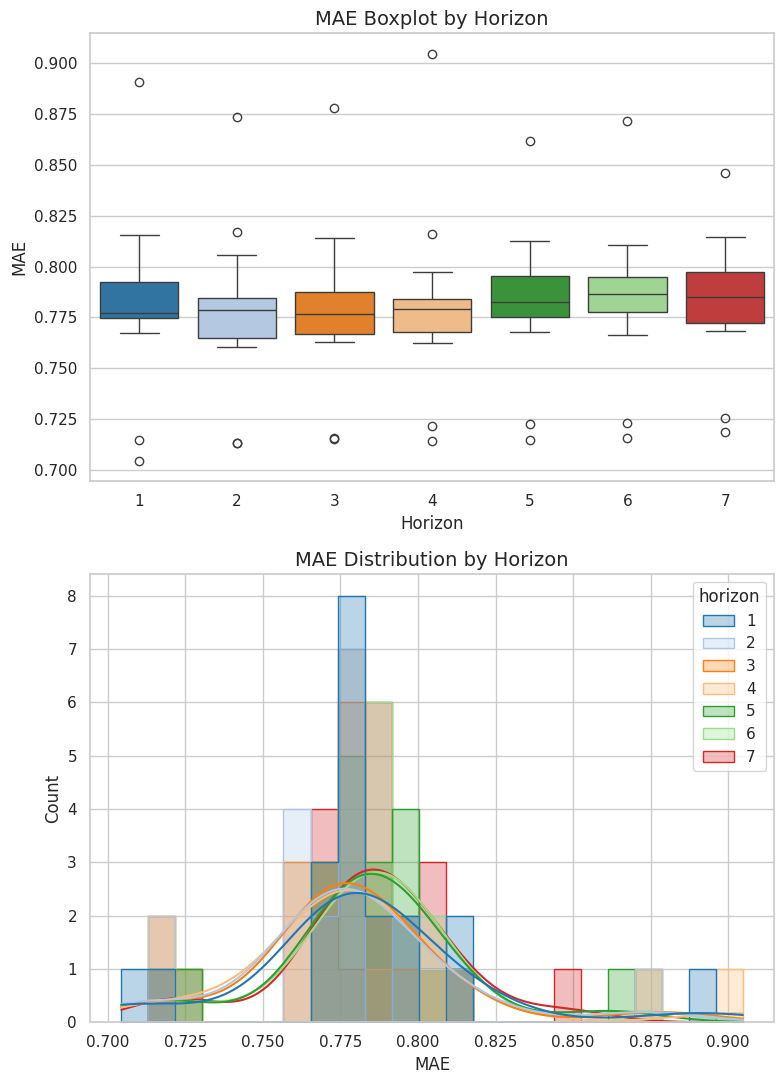

 STATISTICAL EVALUATION: MAE ACROSS HORIZONS 

--- Assumption Checks ---
1. Normality (Shapiro-Wilk): FAILED (p=0.0026)
2. Equal Variance (Levene):  Passed (p=0.9998)

-> Assumptions Violated.NON-PARAMETRIC tests...

[Kruskal-Wallis H-Test]
H-statistic: 5.4895
p-value:     0.48272
-> NO statistically significant difference found across horizons (p >= 0.05).


/tmp/ipykernel_4929/1381176624.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='horizon', y=metric, palette='tab20')


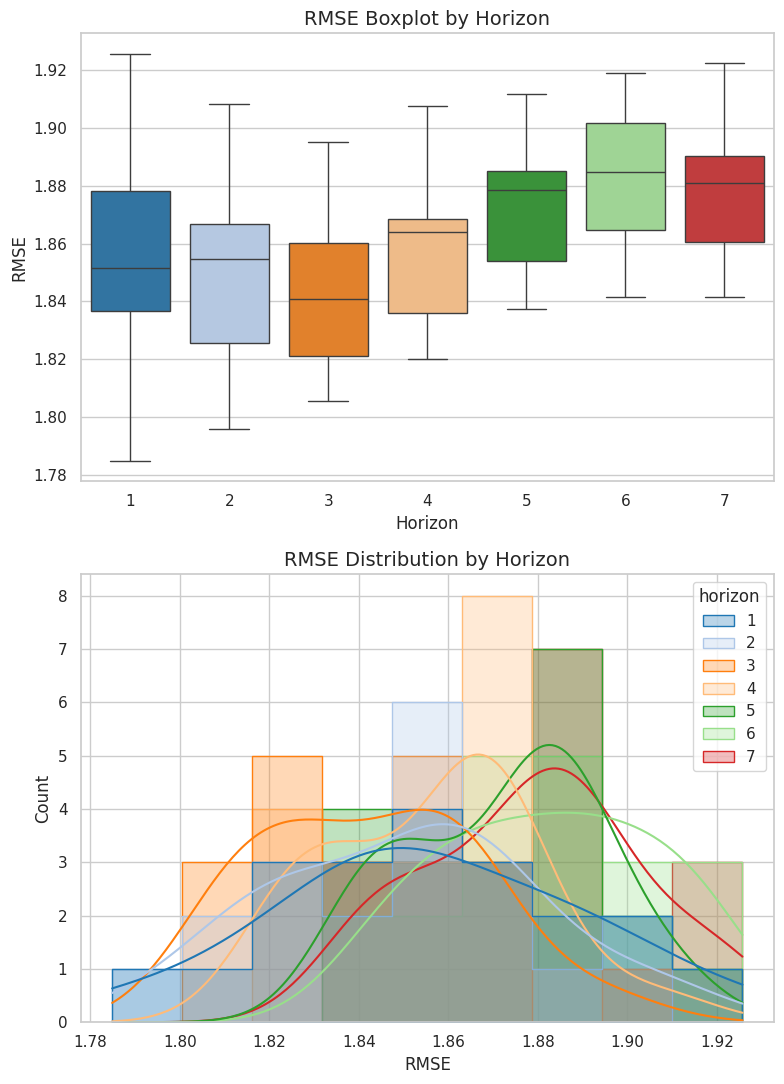

 STATISTICAL EVALUATION: RMSE ACROSS HORIZONS 

--- Assumption Checks ---
1. Normality (Shapiro-Wilk): Passed (p=0.4117)
2. Equal Variance (Levene):  Passed (p=0.5461)

[One-Way ANOVA]
F-statistic: 6.7041
p-value:     0.00000
-> SIGNIFICANT difference; Tukey's  Post-Hoc Test

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2  -0.0053 0.9956 -0.0302 0.0196  False
     1      3  -0.0134 0.6782 -0.0383 0.0115  False
     1      4   0.0006    1.0 -0.0243 0.0255  False
     1      5   0.0165 0.4286 -0.0084 0.0414  False
     1      6   0.0267 0.0271  0.0018 0.0516   True
     1      7   0.0231 0.0887 -0.0018  0.048  False
     2      3  -0.0081 0.9588  -0.033 0.0168  False
     2      4   0.0059 0.9918  -0.019 0.0308  False
     2      5   0.0218 0.1287 -0.0031 0.0467  False
     2      6    0.032 0.0035  0.0071 0.0569   True
     2      7   0.0284 0.0148  0.0034 0.0533   

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

def test_horizon_significance(top_5_df, metric='RMSE', save_fig_path=""):

    all_data = []

    for i in range(len(top_5_df)):
        res = top_5_df.iloc[i]
        paradigm = res['paradigm']
        model = res['model']
        modelname = res['Modelname']
        # if paradigm == 'local':continue
        if modelname == 'chronos2':
            csv_path = f"./{modelname}/per_horizon_{model}.csv"
        elif model == "finalhurdle":
            csv_path = f"./{modelname}/per_horizon_test_global_hurdle_cal.csv" 
        else:
            csv_path = f"./{modelname}/per_horizon_test_{paradigm}_{model}.csv"
        
        try:
            df = pd.read_csv(csv_path)
            all_data.append(df[['horizon', metric]])
        except FileNotFoundError:
            print(f"Warning: Could not find {csv_path}. Skipping...")
            continue
            
    if not all_data:
        print("No data found to process.")
        return

    combined_df = pd.concat(all_data, ignore_index=True)
    
    plt.figure(figsize=(8, 11))
    
    # Boxplot
    plt.subplot(2, 1, 1)
    sns.boxplot(data=combined_df, x='horizon', y=metric, palette='tab20')
    plt.title(f"{metric} Boxplot by Horizon", fontsize=14)
    plt.xlabel("Horizon")
    plt.ylabel(metric)
    
    # Histogram/KDE
    plt.subplot(2, 1, 2)
    sns.histplot(data=combined_df, x=metric, hue='horizon', kde=True, element="step", alpha=0.3,palette='tab20')
    plt.title(f"{metric} Distribution by Horizon", fontsize=14)
    plt.xlabel(metric)
    
    plt.tight_layout()
    plt.savefig(f"./figs/{save_fig_path}")
    plt.show()

    horizons = sorted(combined_df['horizon'].unique())
    groups = [combined_df[combined_df['horizon'] == h][metric].dropna() for h in horizons]
    
    print(f" STATISTICAL EVALUATION: {metric.upper()} ACROSS HORIZONS ")
    
    # --- Assumption 1: Normality (Shapiro-Wilk Test) 
    normality_passed = True
    for h, group in zip(horizons, groups):
        if len(group) >= 3: # Shapiro requires at least 3 data points
            stat, p = stats.shapiro(group)
            if p < 0.05:
                normality_passed = False
                break
        else:
            normality_passed = False
            
    # --- Assumption 2: Equal Variance (Levene's Test) ---
    _, levene_p = stats.levene(*groups)
    variance_passed = levene_p >= 0.05
    
    print("\n--- Assumption Checks ---")
    print(f"1. Normality (Shapiro-Wilk): {'Passed' if normality_passed else 'FAILED'} (p={p:.4f})")
    print(f"2. Equal Variance (Levene):  {'Passed' if variance_passed else 'FAILED'} (p={levene_p:.4f})")

    # Route to the Correct Test
    if normality_passed and variance_passed:
        
        f_stat, p_val = stats.f_oneway(*groups)
        print(f"\n[One-Way ANOVA]")
        print(f"F-statistic: {f_stat:.4f}")
        print(f"p-value:     {p_val:.5f}")
        
        if p_val < 0.05:
            print("-> SIGNIFICANT difference; Tukey's  Post-Hoc Test\n")
            tukey = pairwise_tukeyhsd(endog=combined_df[metric], groups=combined_df['horizon'], alpha=0.05)
            print(tukey)
        else:
            print("-> NO statistically significant difference found across horizons (p >= 0.05).")

    else:
        print("\n-> Assumptions Violated.NON-PARAMETRIC tests...")
        
        h_stat, p_val = stats.kruskal(*groups)
        print(f"\n[Kruskal-Wallis H-Test]")
        print(f"H-statistic: {h_stat:.4f}")
        print(f"p-value:     {p_val:.5f}")
        
        if p_val < 0.05:
            print("-> SIGNIFICANT difference; Dunn's Post-Hoc Test...\n")
            dunn_results = sp.posthoc_dunn(
                combined_df, 
                val_col=metric, 
                group_col='horizon', 
                p_adjust='bonferroni'
            )
            print("Dunn's Test p-values (Values < 0.05 indicate a significant difference):")
            print(dunn_results.round(4))
        else:
            print("-> NO statistically significant difference found across horizons (p >= 0.05).")

# Example Usage:
test_horizon_significance(master_df[:20], metric='MAE',save_fig_path="top20_mae_horizon.svg")
test_horizon_significance(master_df[:20], metric='RMSE',save_fig_path="top20_rmse_horizon.svg")

## Statistical significance of the model ranking (Friedman + Nemenyi test)

Tables 4–5 rank the models by Skill Score / MAE / RMSE, but the gaps between the leading
configurations are small. To test whether these differences are **statistically
significant** or attributable to **noise**, we apply the **Friedman test followed by the
Nemenyi post-hoc test** and summarise the result with a **critical-difference (CD)
diagram**, following Demšar (2006) and the protocol of Ribeiro et al. (2021).

This is the *blocked* (paired) counterpart of the Kruskal–Wallis test already used for
the horizon analysis (Sec 7.2). Each **(region, horizon) cell** is treated as one
"block" (N = 20 × 7 = 140); within every block the models are ranked by error (rank 1 =
lowest error, ties → average rank). The Friedman test evaluates the null that all models
share the same mean rank; if it is rejected, the Nemenyi test identifies the pairs whose
mean ranks differ by more than the critical distance $CD = q_\alpha\sqrt{k(k+1)/6N}$
($q_\alpha$ = studentized-range critical value $/\sqrt 2$; Demšar 2006). In the CD diagram,
models joined by a bar are **not** significantly different at α = 0.05. RMSE (primary) and
MAE (secondary) are analysed separately — analogous to the R²/MSE diagrams in Ribeiro et al.

The featured comparison is the **Table-5 top-5 plus the classical ARIMA baseline** (the
ranking the supervisor's comment concerns, with ARIMA added as a reference point); the
full Table-4 set (best configuration per family + the seasonal-naive and
naive baselines) is reported alongside for context.


In [50]:
# === Friedman/Nemenyi: build the (region x horizon) block x model error matrices ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare, rankdata, studentized_range

# Models compared: the Table-4 representative set (best config per family) + baselines;
# this set contains the Table-5 top-5.
SIG_SPEC = pd.DataFrame([
    dict(Modelname="gbdt",        paradigm="activity", model="catboost_tweedie_tuned", label="CatBoost (Tw, Act)"),
    dict(Modelname="gbdt",        paradigm="global",   model="catboost_tweedie_tuned", label="CatBoost (Tw, Glb)"),
    dict(Modelname="gbdt",        paradigm="global",   model="lightgbm_poisson_tuned", label="LightGBM (Po, Glb)"),
    dict(Modelname="gbdt",        paradigm="global",   model="xgboost_tweedie_tuned",  label="XGBoost (Tw, Glb)"),
    dict(Modelname="lstm",        paradigm="activity", model="lstm_poisson_w28_tuned", label="LSTM (Po, Act)"),
    dict(Modelname="lstm",        paradigm="activity", model="gru_poisson_w28_tuned",  label="GRU (Po, Act)"),
    dict(Modelname="chronos2",    paradigm="local",    model="chronos2_fine_tuned",    label="Chronos-2 (FT)"),
    dict(Modelname="chronos2",    paradigm="local",    model="chronos2_zero_shot",     label="Chronos-2 (ZS)"),
    dict(Modelname="finalhurdle", paradigm="global",   model="finalhurdle",            label="Hurdle"),
    dict(Modelname="diff",        paradigm="global",   model="arima",                  label="ARIMA"),
    dict(Modelname="chronos2",    paradigm="local",    model="naive_weekly",           label="Seasonal Naive"),
    dict(Modelname="chronos2",    paradigm="local",    model="naive_last",             label="Naive"),
])

# The featured comparison: the Table-5 top-5 plus the classical ARIMA baseline
# (a subset of the columns built below).
SIG_TOP5 = ["CatBoost (Tw, Act)", "Chronos-2 (FT)", "CatBoost (Tw, Glb)",
            "LightGBM (Po, Glb)", "LSTM (Po, Act)", "ARIMA"]


def _sig_pred_path(row):
    """Per-observation test-prediction parquet for a model row (same mapping as elsewhere)."""
    mn, par, mdl = row["Modelname"], row["paradigm"], row["model"]
    if mn == "finalhurdle":
        return "./finalhurdle/global_test_hurdle_cal_preds.parquet"
    if mn == "chronos2":
        return f"./chronos2/predictions_long_{mdl}.parquet"
    return f"./{mn}/predictions_long_test_{par}_{mdl}.parquet"


def build_block_matrices(spec):
    """Return (RMSE, MAE) DataFrames: rows = (region, horizon) blocks, cols = model labels.
    Each entry is the model's RMSE / MAE over that cell's rolling-origin test points."""
    rmse, mae = {}, {}
    for _, r in spec.iterrows():
        d = pd.read_parquet(_sig_pred_path(r))
        e = d["y_pred"].values - d["y_true"].values
        d = d.assign(_se=e ** 2, _ae=np.abs(e))
        g = d.groupby(["region", "horizon"])
        rmse[r["label"]] = np.sqrt(g["_se"].mean())
        mae[r["label"]] = g["_ae"].mean()
    return pd.DataFrame(rmse), pd.DataFrame(mae)


sig_RMSE, sig_MAE = build_block_matrices(SIG_SPEC)
assert not sig_RMSE.isna().any().any() and not sig_MAE.isna().any().any(), "incomplete block matrix"
print(f"Block x model matrix: {sig_RMSE.shape[0]} blocks (region x horizon) x {sig_RMSE.shape[1]} models")


Block x model matrix: 140 blocks (region x horizon) x 12 models


In [51]:
# === Normality diagnostic: justify the non-parametric (Friedman) choice ===
# Friedman is rank-based and assumes no normality. We check normality only to justify it
# over its parametric counterpart -- two-way (blocked) ANOVA on blocks x models, whose
# assumption is normal residuals r_ij = x_ij - rowmean_i - colmean_j + grandmean.
# Same Shapiro-Wilk idiom as the horizon analysis (test_horizon_significance).
from scipy.stats import shapiro, skew, kurtosis


def normality_report(M, name, alpha=0.05):
    X = M.values
    resid = X - X.mean(0, keepdims=True) - X.mean(1, keepdims=True) + X.mean()
    r = resid.ravel()
    W, p = shapiro(r)
    verdict = "normal" if p >= alpha else "NON-normal"
    print(f"[{name}] ANOVA residuals (n={r.size}): Shapiro W={W:.3f}, p={p:.2e}, "
          f"skew={skew(r):.2f}, kurtosis={kurtosis(r):.2f} -> {verdict}")
    rej = sum(shapiro(M[c].values)[1] < alpha for c in M.columns)
    print(f"         per-model columns: {rej}/{M.shape[1]} reject normality (alpha={alpha})")
    return p >= alpha


print("Normality of block errors (Top-5 set) -- parametric ANOVA assumption check:\n")
_norm_ok = [normality_report(sig_RMSE[SIG_TOP5], "RMSE"),
            normality_report(sig_MAE[SIG_TOP5], "MAE")]
print("\n-> residuals " + ("appear normal" if all(_norm_ok) else "are NON-normal")
      + "; the rank-based Friedman test (distribution-free) is the appropriate omnibus "
        "test, not a parametric blocked ANOVA.")

Normality of block errors (Top-5 set) -- parametric ANOVA assumption check:

[RMSE] ANOVA residuals (n=840): Shapiro W=0.747, p=6.94e-34, skew=0.67, kurtosis=14.24 -> NON-normal
         per-model columns: 6/6 reject normality (alpha=0.05)
[MAE] ANOVA residuals (n=840): Shapiro W=0.718, p=2.48e-35, skew=0.28, kurtosis=18.46 -> NON-normal
         per-model columns: 6/6 reject normality (alpha=0.05)

-> residuals are NON-normal; the rank-based Friedman test (distribution-free) is the appropriate omnibus test, not a parametric blocked ANOVA.


In [52]:
# === Friedman omnibus + Nemenyi post-hoc (Demsar 2006) ===
ALPHA = 0.05


def friedman_nemenyi(M, alpha=ALPHA):
    """Friedman test + Nemenyi post-hoc on a (blocks x models) error matrix (lower = better)."""
    chi, p = friedmanchisquare(*[M[c].values for c in M.columns])
    ranks = M.apply(lambda row: rankdata(row.values), axis=1, result_type="expand")
    ranks.columns = M.columns
    avg = ranks.mean().sort_values()
    k, N = M.shape[1], M.shape[0]
    # Nemenyi critical distance (Demsar 2006): q_alpha = studentized-range critical value / sqrt(2).
    q = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    CD = q * np.sqrt(k * (k + 1) / (6.0 * N))
    nem = sp.posthoc_nemenyi_friedman(M.values)
    nem.index = nem.columns = M.columns
    return dict(chi=chi, p=p, avg_rank=avg, CD=CD, nemenyi=nem, k=k, N=N)


SIG_SETS = {"Top-5 + ARIMA": SIG_TOP5}
sig_res = {s: {"RMSE": friedman_nemenyi(sig_RMSE[c]), "MAE": friedman_nemenyi(sig_MAE[c])}
           for s, c in SIG_SETS.items()}


def _report(setname):
    print(f"\n################  {setname}  ################")
    tbl = pd.DataFrame({m: sig_res[setname][m]["avg_rank"] for m in ("RMSE", "MAE")})
    tbl.columns = ["RMSE avg rank", "MAE avg rank"]
    print(tbl.sort_values("RMSE avg rank").round(2).to_string())
    for m in ("RMSE", "MAE"):
        r = sig_res[setname][m]
        best = r["avg_rank"].index[0]
        tied = r["avg_rank"][r["avg_rank"] <= r["avg_rank"].iloc[0] + r["CD"]].index.tolist()
        print(f"  {m}: Friedman p={r['p']:.2e} (reject H0={r['p'] < ALPHA}), CD={r['CD']:.2f}; "
              f"best={best!r}; tied-with-best (within 1 CD): {tied}")


for s in SIG_SETS:
    _report(s)

# Featured ranks table (Table-5 top-5) + LaTeX (cf. Ribeiro et al., Table 6).
sig_top5_table = pd.DataFrame(
    {"RMSE avg rank": sig_res["Top-5 + ARIMA"]["RMSE"]["avg_rank"],
     "MAE avg rank":  sig_res["Top-5 + ARIMA"]["MAE"]["avg_rank"]}
).sort_values("RMSE avg rank").round(2)
display(sig_top5_table)
print("\n--- LaTeX (Top-5 Friedman average ranks) ---")
print(sig_top5_table.to_latex(float_format="%.2f",
      caption="Friedman average ranks of the Table-5 top-5 models and the ARIMA baseline over "
              "140 region$\\times$horizon "
              "blocks (rank 1 = best). RMSE and MAE analysed separately.",
      label="tab:friedman_top5"))



################  Top-5 + ARIMA  ################
                    RMSE avg rank  MAE avg rank
CatBoost (Tw, Act)           2.65          2.91
LightGBM (Po, Glb)           2.75          4.22
LSTM (Po, Act)               3.14          2.89
CatBoost (Tw, Glb)           3.34          4.59
ARIMA                        4.51          4.81
Chronos-2 (FT)               4.62          1.59
  RMSE: Friedman p=2.57e-30 (reject H0=True), CD=0.64; best='CatBoost (Tw, Act)'; tied-with-best (within 1 CD): ['CatBoost (Tw, Act)', 'LightGBM (Po, Glb)', 'LSTM (Po, Act)']
  MAE: Friedman p=4.42e-65 (reject H0=True), CD=0.64; best='Chronos-2 (FT)'; tied-with-best (within 1 CD): ['Chronos-2 (FT)']


,RMSE avg rank,MAE avg rank
"CatBoost (Tw, Act)",2.65,2.91
"LightGBM (Po, Glb)",2.75,4.22
"LSTM (Po, Act)",3.14,2.89
"CatBoost (Tw, Glb)",3.34,4.59
ARIMA,4.51,4.81
Chronos-2 (FT),4.62,1.59



--- LaTeX (Top-5 Friedman average ranks) ---
\begin{table}
\caption{Friedman average ranks of the Table-5 top-5 models and the ARIMA baseline over 140 region$\times$horizon blocks (rank 1 = best). RMSE and MAE analysed separately.}
\label{tab:friedman_top5}
\begin{tabular}{lrr}
\toprule
 & RMSE avg rank & MAE avg rank \\
\midrule
CatBoost (Tw, Act) & 2.65 & 2.91 \\
LightGBM (Po, Glb) & 2.75 & 4.22 \\
LSTM (Po, Act) & 3.14 & 2.89 \\
CatBoost (Tw, Glb) & 3.34 & 4.59 \\
ARIMA & 4.51 & 4.81 \\
Chronos-2 (FT) & 4.62 & 1.59 \\
\bottomrule
\end{tabular}
\end{table}



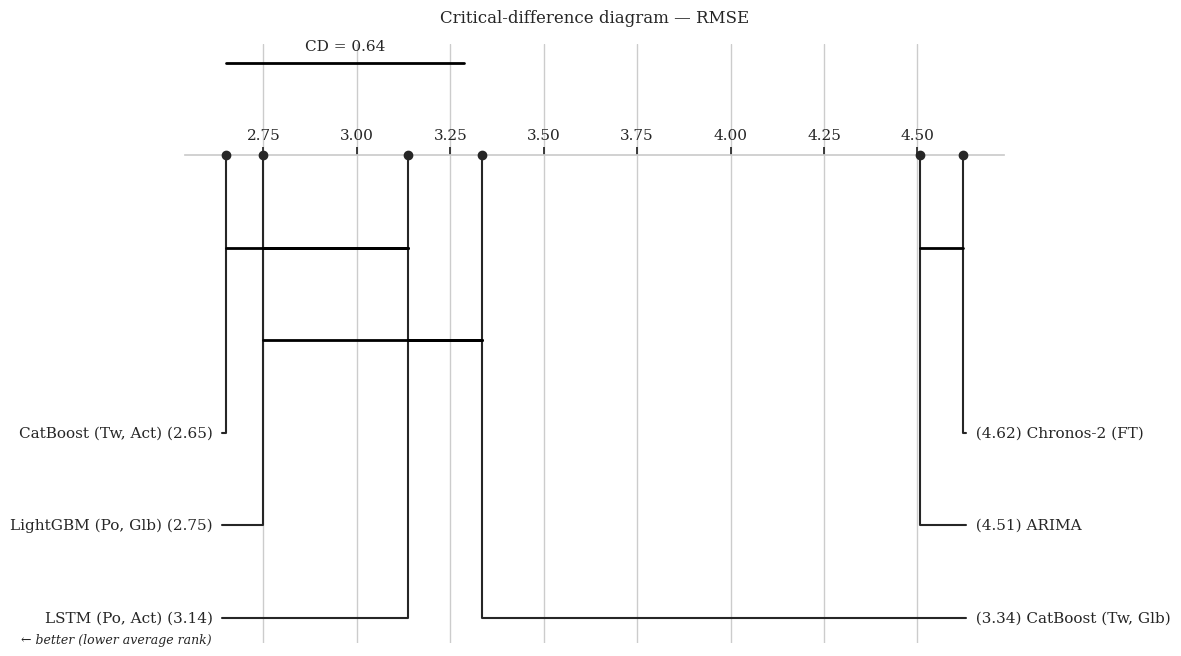

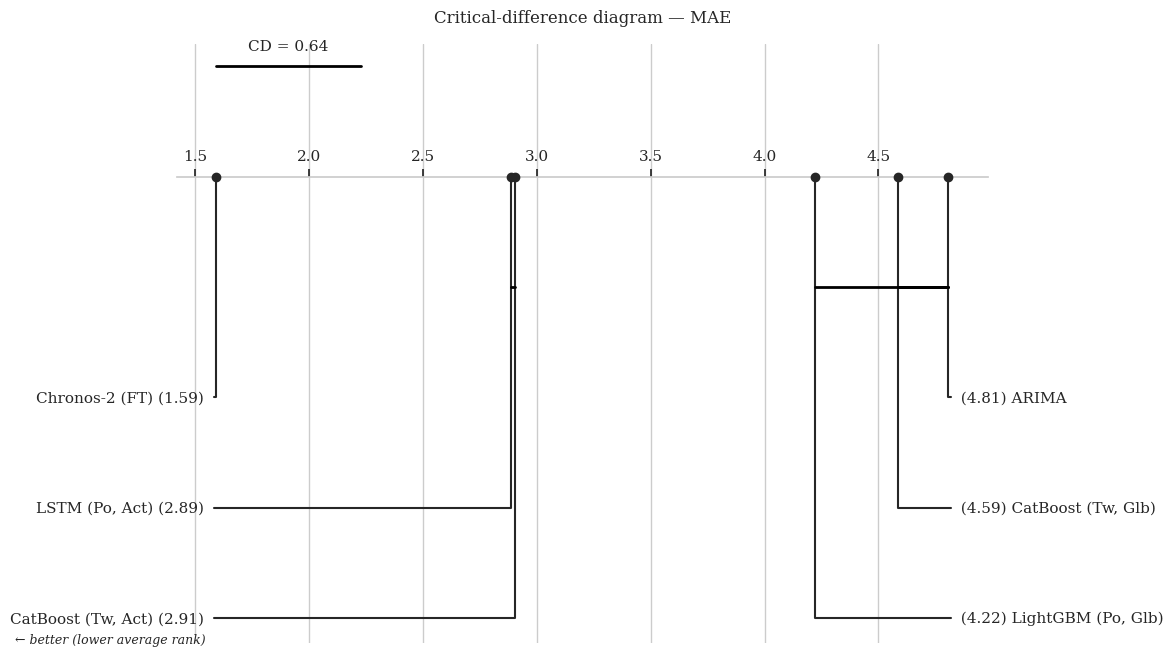

Saved figs/cd_rmse_top5.svg, cd_mae_top5.svg


In [53]:
# === Critical-difference diagrams (Demsar 2006; cf. Ribeiro et al. Figs 12-13) ===


import matplotlib as mpl
mpl.rcParams.update({"font.family": "serif", "font.size": 11})

_CD_FILE = {("Top-5 + ARIMA", "RMSE"): "cd_rmse_top5",
            ("Top-5 + ARIMA", "MAE"):  "cd_mae_top5"}
_CD_GREY = "0.15"   

for setname in SIG_SETS:
    for metric in ("RMSE", "MAE"):
        r = sig_res[setname][metric]
        order = r["avg_rank"].index
        sig_mat = r["nemenyi"].loc[order, order]   
        fig, ax = plt.subplots(figsize=(12, 0.30 * r["k"] + 2.6))
        sp.critical_difference_diagram(
            ranks=r["avg_rank"], sig_matrix=sig_mat, ax=ax, cd=r["CD"],   
            label_fmt_left="{label} ({rank:.2f})  ",      
            label_fmt_right="  ({rank:.2f}) {label}",
            color_palette={m: _CD_GREY for m in order},   
            crossbar_props={"color": "black", "linewidth": 2},
        )

        ax.grid(False)                       # drop the vertical grid lines
        ax.xaxis.grid(False)

        _CD_Y = 1
        for _ln in ax.lines:
            _yd = np.atleast_1d(_ln.get_ydata())
            if len(_yd) == 2 and np.allclose(_yd, 0.5):    # the CD reference bar (only line at y=0.5)
                _ln.set_ydata([_CD_Y, _CD_Y])
        for _t in ax.texts:
            if _t.get_text().startswith("CD ="):           # the "CD = ..." label
                _x, _ = _t.get_position()
                _t.set_position((_x, _CD_Y + 0.18))
        ax.set_ylim(ax.get_ylim()[0], _CD_Y + 0.45)        # extra headroom above the tiers
        ax.set_title(f"Critical-difference diagram — {metric}", fontsize=12, pad=26)
        ax.annotate("← better (lower average rank)", xy=(-0.2, 0.0),
                    xycoords="axes fraction", ha="left", fontsize=9, style="italic")
        fig.tight_layout()
        fig.savefig(f"./figs/{_CD_FILE[(setname, metric)]}.svg", bbox_inches="tight")
        plt.show()
print("Saved figs/cd_rmse_top5.svg, cd_mae_top5.svg")

In [54]:
# hurdle_pred = pd.read_parquet('./finalhurdle/global_test_hurdle_preds.parquet')
hurdle_cal_preds = pd.read_parquet('./finalhurdle/global_cv_hurdle_cal_preds.parquet')
hurdle_clas_cal_probs = pd.read_parquet('./finalhurdle/global_test_classifier_cal_probs.parquet')
hurdle_reg_preds = pd.read_parquet('./finalhurdle/global_test_hurdle_preds.parquet')
display(hurdle_clas_cal_probs)

,region,fold,horizon,date,y_true,y_prob
0,cherkasy,0,1,2024-08-05,0.0,0.008046
1,cherkasy,0,2,2024-08-06,0.0,0.009609
2,cherkasy,0,3,2024-08-07,0.0,0.017054
3,cherkasy,0,4,2024-08-08,0.0,0.022928
4,cherkasy,0,5,2024-08-09,0.0,0.014875
...,...,...,...,...,...,...
22955,zhytomyr,163,3,2025-01-17,0.0,0.014396
22956,zhytomyr,163,4,2025-01-18,0.0,0.009207
22957,zhytomyr,163,5,2025-01-19,0.0,0.011088
22958,zhytomyr,163,6,2025-01-20,0.0,0.014294


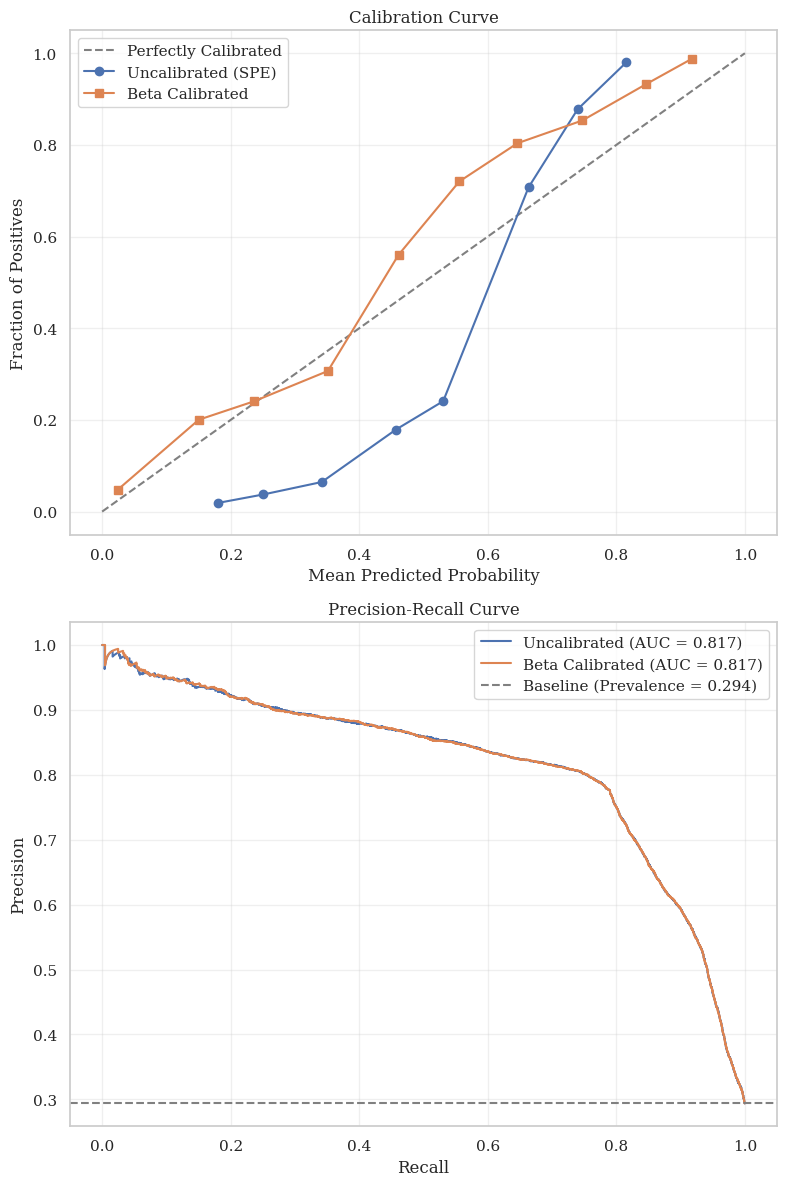

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, auc

def load_and_merge_data(uncal_path, cal_path):
    """Loads parquet files and merges them on identifiers."""
    df_uncal = pd.read_parquet(uncal_path)
    df_cal = pd.read_parquet(cal_path)
    
    # Rename probability columns to distinguish them
    df_uncal = df_uncal.rename(columns={'y_prob': 'y_prob_uncal'})
    df_cal = df_cal.rename(columns={'y_prob': 'y_prob_cal'})
    
    # Merge to guarantee alignment
    keys = ['region', 'fold', 'horizon', 'date']
    df = pd.merge(df_uncal, df_cal[keys + ['y_prob_cal']], on=keys, how='inner')
    
    return df['y_true'].astype(int), df['y_prob_uncal'], df['y_prob_cal']

def plot_calibration_and_prauc(y_true, y_prob_uncal, y_prob_cal):
    """Generates a side-by-side figure of Calibration and PR-AUC curves."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12))
    
    # -----------------------------------------
    # Plot 1: Calibration Curve (Reliability Diagram)
    # -----------------------------------------
    # Calculate calibration curves (10 bins is standard)
    prob_true_uncal, prob_pred_uncal = calibration_curve(y_true, y_prob_uncal, n_bins=10)
    prob_true_cal, prob_pred_cal = calibration_curve(y_true, y_prob_cal, n_bins=10)
    
    # Plot perfectly calibrated reference line
    ax1.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
    
    # Plot model curves
    ax1.plot(prob_pred_uncal, prob_true_uncal, marker='o', label='Uncalibrated (SPE)')
    ax1.plot(prob_pred_cal, prob_true_cal, marker='s', label='Beta Calibrated')
    
    ax1.set_xlabel('Mean Predicted Probability')
    ax1.set_ylabel('Fraction of Positives')
    ax1.set_title('Calibration Curve')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Calculate PR curves and AUC
    prec_uncal, recall_uncal, _ = precision_recall_curve(y_true, y_prob_uncal)
    pr_auc_uncal = auc(recall_uncal, prec_uncal)
    
    prec_cal, recall_cal, _ = precision_recall_curve(y_true, y_prob_cal)
    pr_auc_cal = auc(recall_cal, prec_cal)
    
    # Plot PR curves
    ax2.plot(recall_uncal, prec_uncal, label=f'Uncalibrated (AUC = {pr_auc_uncal:.3f})')
    ax2.plot(recall_cal, prec_cal, label=f'Beta Calibrated (AUC = {pr_auc_cal:.3f})')
    
    # Plot baseline (Prevalence of positive class)
    baseline = y_true.mean()
    ax2.axhline(baseline, linestyle='--', color='gray', label=f'Baseline (Prevalence = {baseline:.3f})')
    
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()  

    plt.savefig("./figs/calibration_prcurve.svg")
    plt.show()
# Define file paths

uncalibrated_file = './finalhurdle/global_test_classifier_probs.parquet'
calibrated_file = './finalhurdle/global_test_classifier_cal_probs.parquet'

# Execute pipeline
y_true, y_prob_uncal, y_prob_cal = load_and_merge_data(uncalibrated_file, calibrated_file)
plot_calibration_and_prauc(y_true, y_prob_uncal, y_prob_cal)

Optimal global F1 threshold found on CV: 0.3537


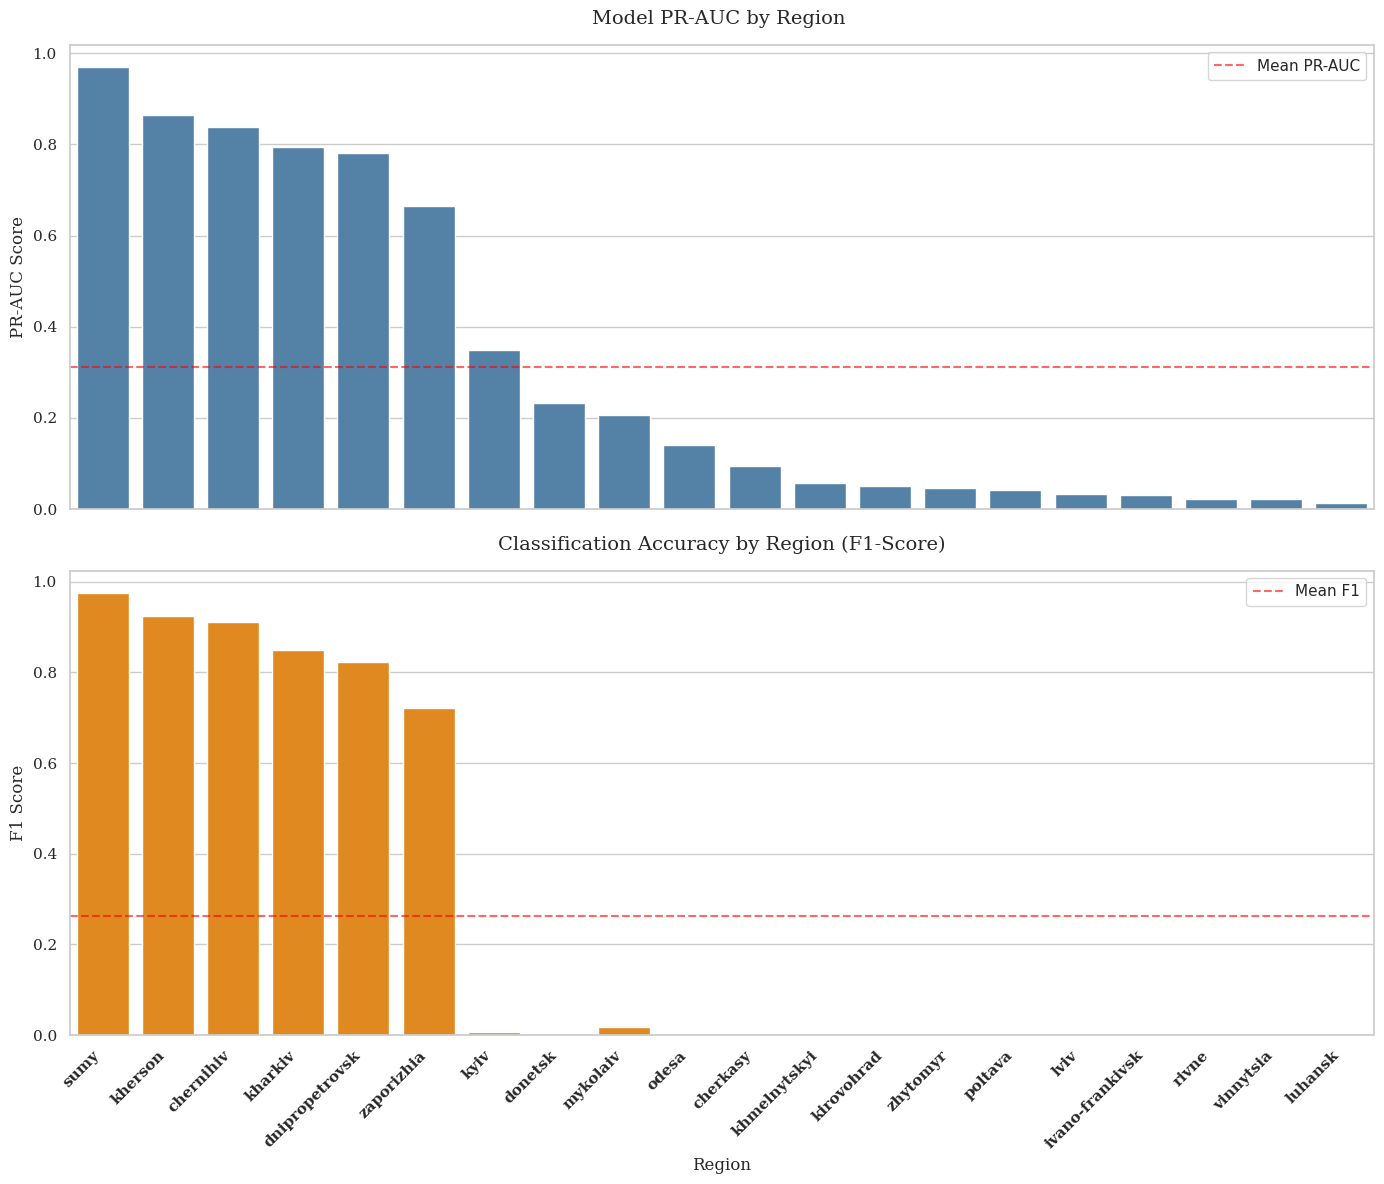

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve

def get_optimal_threshold(df_cv):
    """Finds the probability threshold that maximizes F1 on the CV set."""
    prec, recall, thresholds = precision_recall_curve(df_cv['y_true'], df_cv['y_prob'])
    
    # Calculate F1 for all thresholds; handle division by zero
    f1_scores = np.divide(2 * (prec * recall), (prec + recall), 
                          out=np.zeros_like(prec), where=(prec + recall) != 0)
    
    # Get index of highest F1
    best_idx = np.argmax(f1_scores)
    # thresholds array is 1 element shorter than prec/recall arrays
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    
    print(f"Optimal global F1 threshold found on CV: {best_threshold:.4f}")
    return best_threshold

def calculate_regional_metrics(df_test, threshold):
    """Calculates PR-AUC and F1 score for each region."""
    # Apply threshold to get binary predictions
    df_test['y_pred_bin'] = (df_test['y_prob'] >= threshold).astype(int)
    
    records = []
    for region, group in df_test.groupby('region'):
        y_true = group['y_true']
        y_prob = group['y_prob']
        y_pred = group['y_pred_bin']
        
        # We can only calculate these if there is at least 1 positive case in the region
        if y_true.sum() > 0:
            pr_auc = average_precision_score(y_true, y_prob)
            f1 = f1_score(y_true, y_pred)
            
            records.append({
                'Region': region,
                'PR-AUC': pr_auc,
                'F1-Score': f1
            })
            
    return pd.DataFrame(records)

def plot_regional_metrics(metrics_df):
    """Plots PR-AUC and F1-Score sorted by performance."""
    # Sort regions by PR-AUC descending for a clean waterfall look
    metrics_df = metrics_df.sort_values('PR-AUC', ascending=False)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
    sns.set_theme(style="whitegrid")
    
    # Plot 1: PR-AUC
    sns.barplot(data=metrics_df, x='Region', y='PR-AUC', ax=ax1, color='steelblue')
    ax1.set_title('Model PR-AUC by Region ', fontsize=14, pad=15)
    ax1.set_ylabel('PR-AUC Score')
    ax1.axhline(metrics_df['PR-AUC'].mean(), color='red', linestyle='--', alpha=0.6, label='Mean PR-AUC')
    ax1.legend()
    
    # Plot 2: F1 Score
    sns.barplot(data=metrics_df, x='Region', y='F1-Score', ax=ax2, color='darkorange')
    ax2.set_title('Classification Accuracy by Region (F1-Score)', fontsize=14, pad=15)
    ax2.set_ylabel('F1 Score')
    ax2.axhline(metrics_df['F1-Score'].mean(), color='red', linestyle='--', alpha=0.6, label='Mean F1')
    ax2.legend()
    
    # Formatting x-axis labels to match your RMSE plot style
    plt.xticks(rotation=45, ha='right', fontweight='bold')
    plt.xlabel('Region', fontsize=12)
    
    plt.tight_layout()
    plt.savefig("./figs/prauc_f1_perregion.svg")
    plt.show()

uncalibrated_file = './finalhurdle/global_test_classifier_probs.parquet'
calibrated_file = './finalhurdle/global_test_classifier_cal_probs.parquet'
df_cv = pd.read_parquet('./finalhurdle/global_cv_classifier_cal_probs.parquet') 

# Use the Calibrated Test probabilities for the actual evaluation
df_test = pd.read_parquet(calibrated_file)

# 2. Find optimal threshold
optimal_thresh = get_optimal_threshold(df_cv)

# 3. Calculate metrics per region
regional_metrics = calculate_regional_metrics(df_test, optimal_thresh)

# 4. Plot
plot_regional_metrics(regional_metrics)

Top Regions by Delta (PR-AUC minus Prevalence):
            Region  Prevalence    PR-AUC     Delta
18      zaporizhia    0.557491  0.665282  0.107790
2   dnipropetrovsk    0.699477  0.780158  0.080681
9             kyiv    0.282230  0.349698  0.067469
5          kharkiv    0.736934  0.793460  0.056526
12        mykolaiv    0.186411  0.207281  0.020870


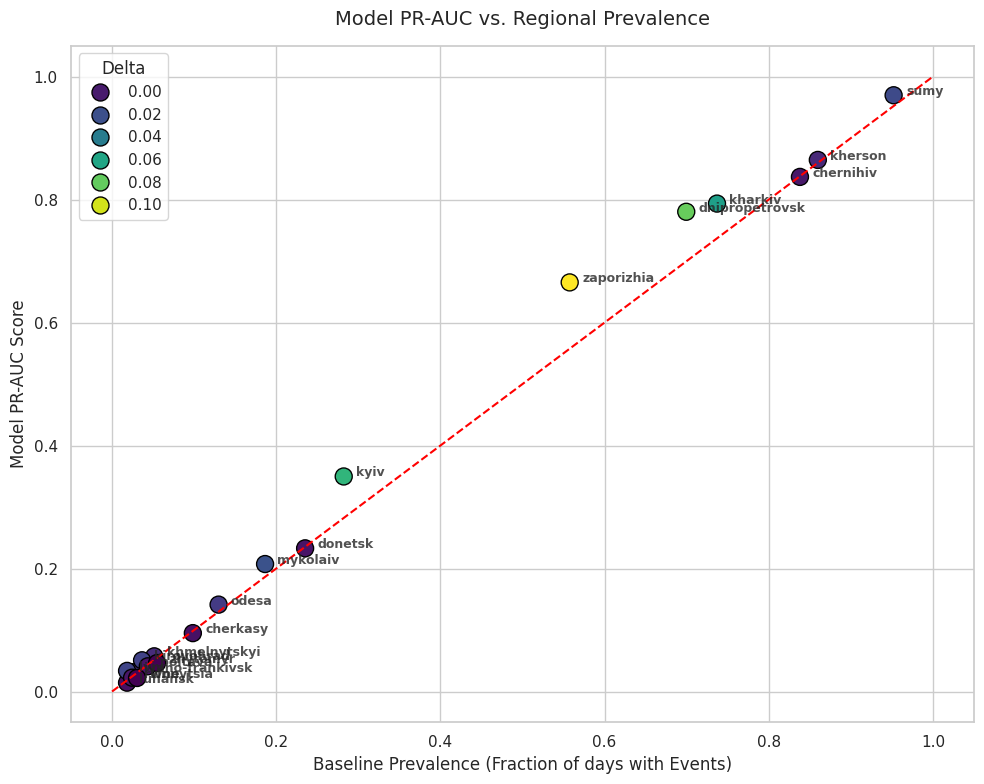

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import average_precision_score

def analyze_skill_vs_prevalence(df_test):
    """Calculates PR-AUC vs Baseline Prevalence per region."""
    records = []
    
    for region, group in df_test.groupby('region'):
        y_true = group['y_true']
        y_prob = group['y_prob'] 
        
        n_days = len(y_true)
        n_events = y_true.sum()
        prevalence = n_events / n_days
        
        if 0 < n_events < n_days:
            pr_auc = average_precision_score(y_true, y_prob)
            
            records.append({
                'Region': region,
                'Prevalence': prevalence,
                'PR-AUC': pr_auc,
                'Delta': pr_auc - prevalence # How much better than baseline?
            })
            
    return pd.DataFrame(records)

def plot_skill_scatter(metrics_df):
    """Plots PR-AUC vs Prevalence to prove model skill."""
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="whitegrid")
    
    scatter = sns.scatterplot(
        data=metrics_df, 
        x='Prevalence', 
        y='PR-AUC', 
        hue='Delta',
        palette='viridis',
        s=150, 
        edgecolor='black'
    )
    
    # Add the No-Skill Baseline (y = x)
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='No-Skill Baseline (PR-AUC = Prevalence)')
    
    # Annotate the regions for clarity
    for _, row in metrics_df.iterrows():
            plt.text(row['Prevalence'] + 0.015, row['PR-AUC'], row['Region'], 
                    fontsize=9, fontweight='bold', alpha=0.8)

    plt.title('Model PR-AUC vs. Regional Prevalence', fontsize=14, pad=15)
    plt.xlabel('Baseline Prevalence (Fraction of days with Events)', fontsize=12)
    plt.ylabel('Model PR-AUC Score', fontsize=12)
    
    # Legend formatting
    # plt.legend(loc='lower right', frameon=True)
    
    plt.tight_layout()
    plt.savefig("./figs/prauc_vs_prevalence.svg")
    plt.show()

df_test = pd.read_parquet(calibrated_file)

# Execute pipeline
skill_df = analyze_skill_vs_prevalence(df_test)

print("Top Regions by Delta (PR-AUC minus Prevalence):")
print(skill_df.sort_values('Delta', ascending=False)[['Region', 'Prevalence', 'PR-AUC', 'Delta']].head())

plot_skill_scatter(skill_df)

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Assuming hurdle_regressor_test_set is already loaded from your code
# hurdle_regressor_test_set = hurdle_reg_preds[hurdle_reg_preds['y_true'] > 0].copy()

def analyze_regressor_performance(df):
    """Calculates comprehensive regression metrics per region."""
    records = []
    
    for region, group in df.groupby('region'):
        y_true = group['y_true']
        y_pred = group['y_pred']
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        bias = np.mean(y_pred - y_true) # Negative means under-prediction
        max_true = y_true.max()
        
        records.append({
            'Region': region,
            'Count (Days > 0)': len(y_true),
            'Max Actual Strikes': max_true,
            'RMSE': rmse,
            'MAE': mae,
            'Bias (Mean Error)': bias
        })
        
    metrics_df = pd.DataFrame(records).sort_values('RMSE', ascending=False)
    return metrics_df

def plot_true_vs_predicted(df):
    """Generates a scatter plot of True vs Predicted magnitudes."""
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="whitegrid")
    
    # Create scatter plot, sizing points by how many times that exact combination occurred
    # (Since count data often overlaps, jitter or alpha is important)
    sns.scatterplot(
        data=df, 
        x='y_true', 
        y='y_pred', 
        hue='region',
        alpha=0.6,
        edgecolor='black',
        s=80
    )
    
    # Find the max value to scale the axes equally
    max_val = max(df['y_true'].max(), df['y_pred'].max())
    
    # Plot the perfect prediction line (y = x)
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Prediction (y = x)')
    
    plt.title('Conditional Regressor Head: True vs. Predicted Event Magnitude', fontsize=14, pad=15)
    plt.xlabel('True Number of Events', fontsize=12)
    plt.ylabel('Predicted Number of Events', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# 1. Generate the advanced metrics table
regressor_metrics = analyze_regressor_performance(hurdle_regressor_test_set)
print("--- Conditional Regressor Metrics by Region ---")
display(regressor_metrics.head(10)) # Look specifically at the Bias and MAE vs RMSE

# 2. Generate the diagnostic plot
plot_true_vs_predicted(hurdle_regressor_test_set)

NameError: name 'hurdle_regressor_test_set' is not defined

In [ ]:
# def get_naive_pred(train_df):

#     if 'event_date' not in train_df.columns and train_df.index.name == 'event_date':
#         train_df = train_df.reset_index()
        
#     train_df = train_df.sort_values(by=['region', 'event_date'])


#     train_df['y_pred'] = train_df.groupby('region')['y_true'].shift(7)

#     naive_pred = train_df.dropna(subset=['y_pred']).copy()


#     if 'event_date' in naive_pred.columns:
#         naive_pred = naive_pred.rename(columns={'event_date': 'date'})

#     if 'fold' not in naive_pred.columns:
#         naive_pred['fold'] = 0

#     naive_pred = naive_pred[['region', 'date', 'fold', 'y_true', 'y_pred']]
#     return naive_pred


In [ ]:
# train_df = pd.read_parquet('./train_df/train_df.parquet')
# train_df.rename(columns={'act_drone_strike_on_ua': 'y_true'}, inplace=True)
# print(train_df.describe())
# naive_pred = get_naive_pred(train_df)
# naive_pred

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

def plot_model_forecasts(df, model_name="Model", region_col='region', date_col='date', 
                         actual_col='y_true', pred_col='y_pred', fold_col='fold'):
    """
    Plots actuals vs predicted values per region for a single model dataframe.
    """
    # Create a copy to avoid modifying the original dataframe's dtypes
    df_plot = df.copy()
    
    # Convert date column to datetime
    df_plot[date_col] = pd.to_datetime(df_plot[date_col])

    # Plot per region
    regions = df_plot[region_col].unique()

    for region in regions:
        region_data = df_plot[df_plot[region_col] == region]
        
        # Extract unique folds and generate a distinct color for each
        folds = region_data[fold_col].unique()
        fold_colors = sns.color_palette("husl", len(folds))
        
        # Create a single plot for this region
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.suptitle(f'Rolling 7-Day Forecasts: {str(region).capitalize()}', fontsize=16, y=1.02)
        
        # Actuals (drop duplicates in case multiple folds overlap on actuals)
        actuals = region_data[[date_col, actual_col]].drop_duplicates().sort_values(by=date_col)
        # Calculate the scalar mean of the actuals
        actuals_mean = actuals[actual_col].mean()
        
        # Plot Actuals
        ax.plot(actuals[date_col], actuals[actual_col], 
                label='Actual', color='black', alpha=0.4, linewidth=2, zorder=5)
        
        # Plot Mean as a flat horizontal line
        ax.axhline(y=actuals_mean, label=f'Mean ({actuals_mean:.2f})', 
                   color='red', linestyle='--', alpha=0.6, zorder=4)
        
        # Loop through each fold and plot its chunk with its assigned color
        for i, fold_id in enumerate(folds):
            window_data = region_data[region_data[fold_col] == fold_id].sort_values(by=date_col)
            
            ax.plot(window_data[date_col], window_data[pred_col], 
                    color=fold_colors[i], alpha=0.8, label=f'Fold {fold_id}')
        
        # Formatting for the plot
        ax.set_title(model_name, fontsize=14)
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Value', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.tick_params(axis='x', rotation=45)
        
        # Legend handling: Move outside the plot so it doesn't cover data
        # Using dict(zip(...)) ensures we don't get duplicate legend entries
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        # ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

        plt.tight_layout()
        plt.show()

In [ ]:
top_5_df['SkillScore']

0    0.169634
1    0.169486
2    0.169411
3    0.165593
4    0.165131
Name: SkillScore, dtype: float64

In [ ]:
gbdt_importance = pd.read_csv('./gbdt/importance_all.csv')
globalLGBM_top15_gain = gbdt_importance[gbdt_importance['model'] == 'global_lightgbm_poisson'][['Feature','agg_gain']].sort_values(['agg_gain'], ascending=False).head(15)
globalLGBM_top15_perm = gbdt_importance[gbdt_importance['model'] == 'global_lightgbm_poisson'][['Feature','agg_perm']].sort_values(['agg_perm'], ascending=False).head(15)

In [ ]:
chronos2_importance = pd.read_csv('./chronos2/feature_importance_chronos2_ft.csv')
gbdt_glob_importance = pd.read_csv('./gbdt/importance_global_catboost_tweedie_2.csv')

chronos2_importance = chronos2_importance.rename(columns={'Unnamed: 0': 'Feature'})

# Then wrap and plot


In [ ]:
gbdt_glob_importance

,Feature,h1_gain,h2_gain,h3_gain,h4_gain,h5_gain,h6_gain,h7_gain,h1_perm,h2_perm,h3_perm,h4_perm,h5_perm,h6_perm,h7_perm,agg_gain,agg_perm
0,Activity_Level_statcov_target_act_drone_strike...,28.443643,29.131206,30.721274,30.252816,29.599884,30.253383,30.740478,0.239728,2.224725e-01,0.231669,0.228353,2.378958e-01,0.244952,0.267360,29.877526,0.238918
1,region_statcov_target_act_drone_strike_on_ua,2.654972,2.088113,2.215523,2.429220,1.936533,1.843442,1.949863,0.080943,6.706990e-02,0.071479,0.072833,6.050402e-02,0.063343,0.062312,2.159667,0.068355
2,act_drone_strike_on_ua_target_lag-2,1.614067,4.481524,1.766579,2.160474,1.634058,8.972223,5.138844,0.017138,3.849320e-02,0.013098,0.015958,1.641975e-02,0.178802,0.079170,3.681110,0.051297
3,act_drone_strike_on_ua_target_lag-3,4.197673,1.464120,2.051015,1.326452,8.395791,5.011773,1.058560,0.039302,1.279093e-02,0.017334,0.012264,1.755925e-01,0.082901,0.006601,3.357912,0.049541
4,act_drone_strike_on_ua_target_lag-5,1.889677,1.387067,8.380185,4.904239,1.361288,2.405836,3.369114,0.015770,9.368212e-03,0.161115,0.082661,8.180267e-03,0.025764,0.032384,3.385343,0.047892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,darts_enc_fc_cyc_month_sin_futcov_lag6,0.000978,0.000000,0.000000,0.007357,0.000629,0.004960,0.002966,0.000037,0.000000e+00,0.000000,0.000039,3.187997e-05,0.000151,0.000069,0.002413,0.000047
287,darts_enc_fc_cyc_month_cos_futcov_lag5,0.006165,0.000000,0.032489,0.006574,0.012760,0.000000,0.011255,0.000041,0.000000e+00,0.000175,-0.000089,1.053901e-04,0.000000,0.000094,0.009892,0.000047
288,darts_enc_fc_cyc_week_sin_futcov_lag0,0.011407,0.000771,0.000000,0.000000,0.000000,0.000000,0.000000,0.000333,-4.137258e-05,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.001740,0.000042
289,darts_enc_fc_cyc_week_sin_futcov_lag2,0.000000,0.006871,0.005679,0.000000,0.006216,0.002880,0.013131,0.000000,1.055021e-05,0.000148,0.000000,6.642869e-08,0.000024,-0.000019,0.004968,0.000023


In [ ]:
gbdt_importance['model'].unique()
importancedict = {}
for activity in range(1,4):
    cb_top15_gain = gbdt_importance[gbdt_importance['model'] == f'activity_{activity}_catboost_tweedie'][['Feature','agg_gain']].sort_values(['agg_gain'], ascending=False).head(15)
    cb_top15_perm = gbdt_importance[gbdt_importance['model'] == f'activity_{activity}_catboost_tweedie'][['Feature','agg_perm']].sort_values(['agg_perm'], ascending=False).head(15)
    importancedict[f'activity_{activity}'] = {'gain':cb_top15_gain, 'perm':cb_top15_perm}

NameError: name 'gbdt_importance' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importances(importancedict, top_n=15, title='Feature Importances'):
    """
    Dynamically plots feature importances from a nested dictionary.
    
    Expected format: 
    {
        'group_name': { 
            'metric_name': dataframe_with_2_columns 
        }
    }
    """
    # 1. Dynamically determine rows and columns
    row_keys = list(importancedict.keys())
    
    # Extract unique inner keys (metrics) while preserving order
    col_keys = []
    for inner_dict in importancedict.values():
        for k in inner_dict.keys():
            if k not in col_keys:
                col_keys.append(k)
                
    nrows = len(row_keys)
    ncols = len(col_keys)
    
    if nrows == 0 or ncols == 0:
        print("Dictionary is empty.")
        return

    # 2. Setup the figure dynamically
    # Width scales by number of columns, height scales by number of rows
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, 
                             figsize=(10 * ncols, 8 * nrows), 
                             squeeze=False) # Crucial: forces axes to be a 2D array
    
    fig.suptitle(title, fontsize=22, y=1.02)
    
    # 3. Iterate through the grid and plot
    for i, r_key in enumerate(row_keys):
        for j, c_key in enumerate(col_keys):
            ax = axes[i, j]
            
            # Check if this specific metric exists for this group
            if c_key in importancedict[r_key]:
                # Slice top_n rows
                df = importancedict[r_key][c_key].head(top_n)
                
                # Dynamically grab column names assuming format: ['Feature_Name_Col', 'Value_Col']
                feature_col = df.columns[0]
                value_col = df.columns[1]
                
                sns.barplot(
                    data=df, 
                    x=value_col, 
                    y=feature_col, 
                    ax=ax, 
                )
                
                ax.set_title(f'{r_key} - {c_key}', fontsize=16)
                ax.set_xlabel(f'Importance ({value_col})', fontsize=12)
                ax.set_ylabel('')
                ax.tick_params(axis='y', labelsize=11)
            else:
                # If a specific dictionary is missing a metric, leave that subplot blank
                ax.axis('off')

    plt.tight_layout()
    plt.savefig(f"./figs/{("").join(title.split(" "))}.svg")
    plt.show()

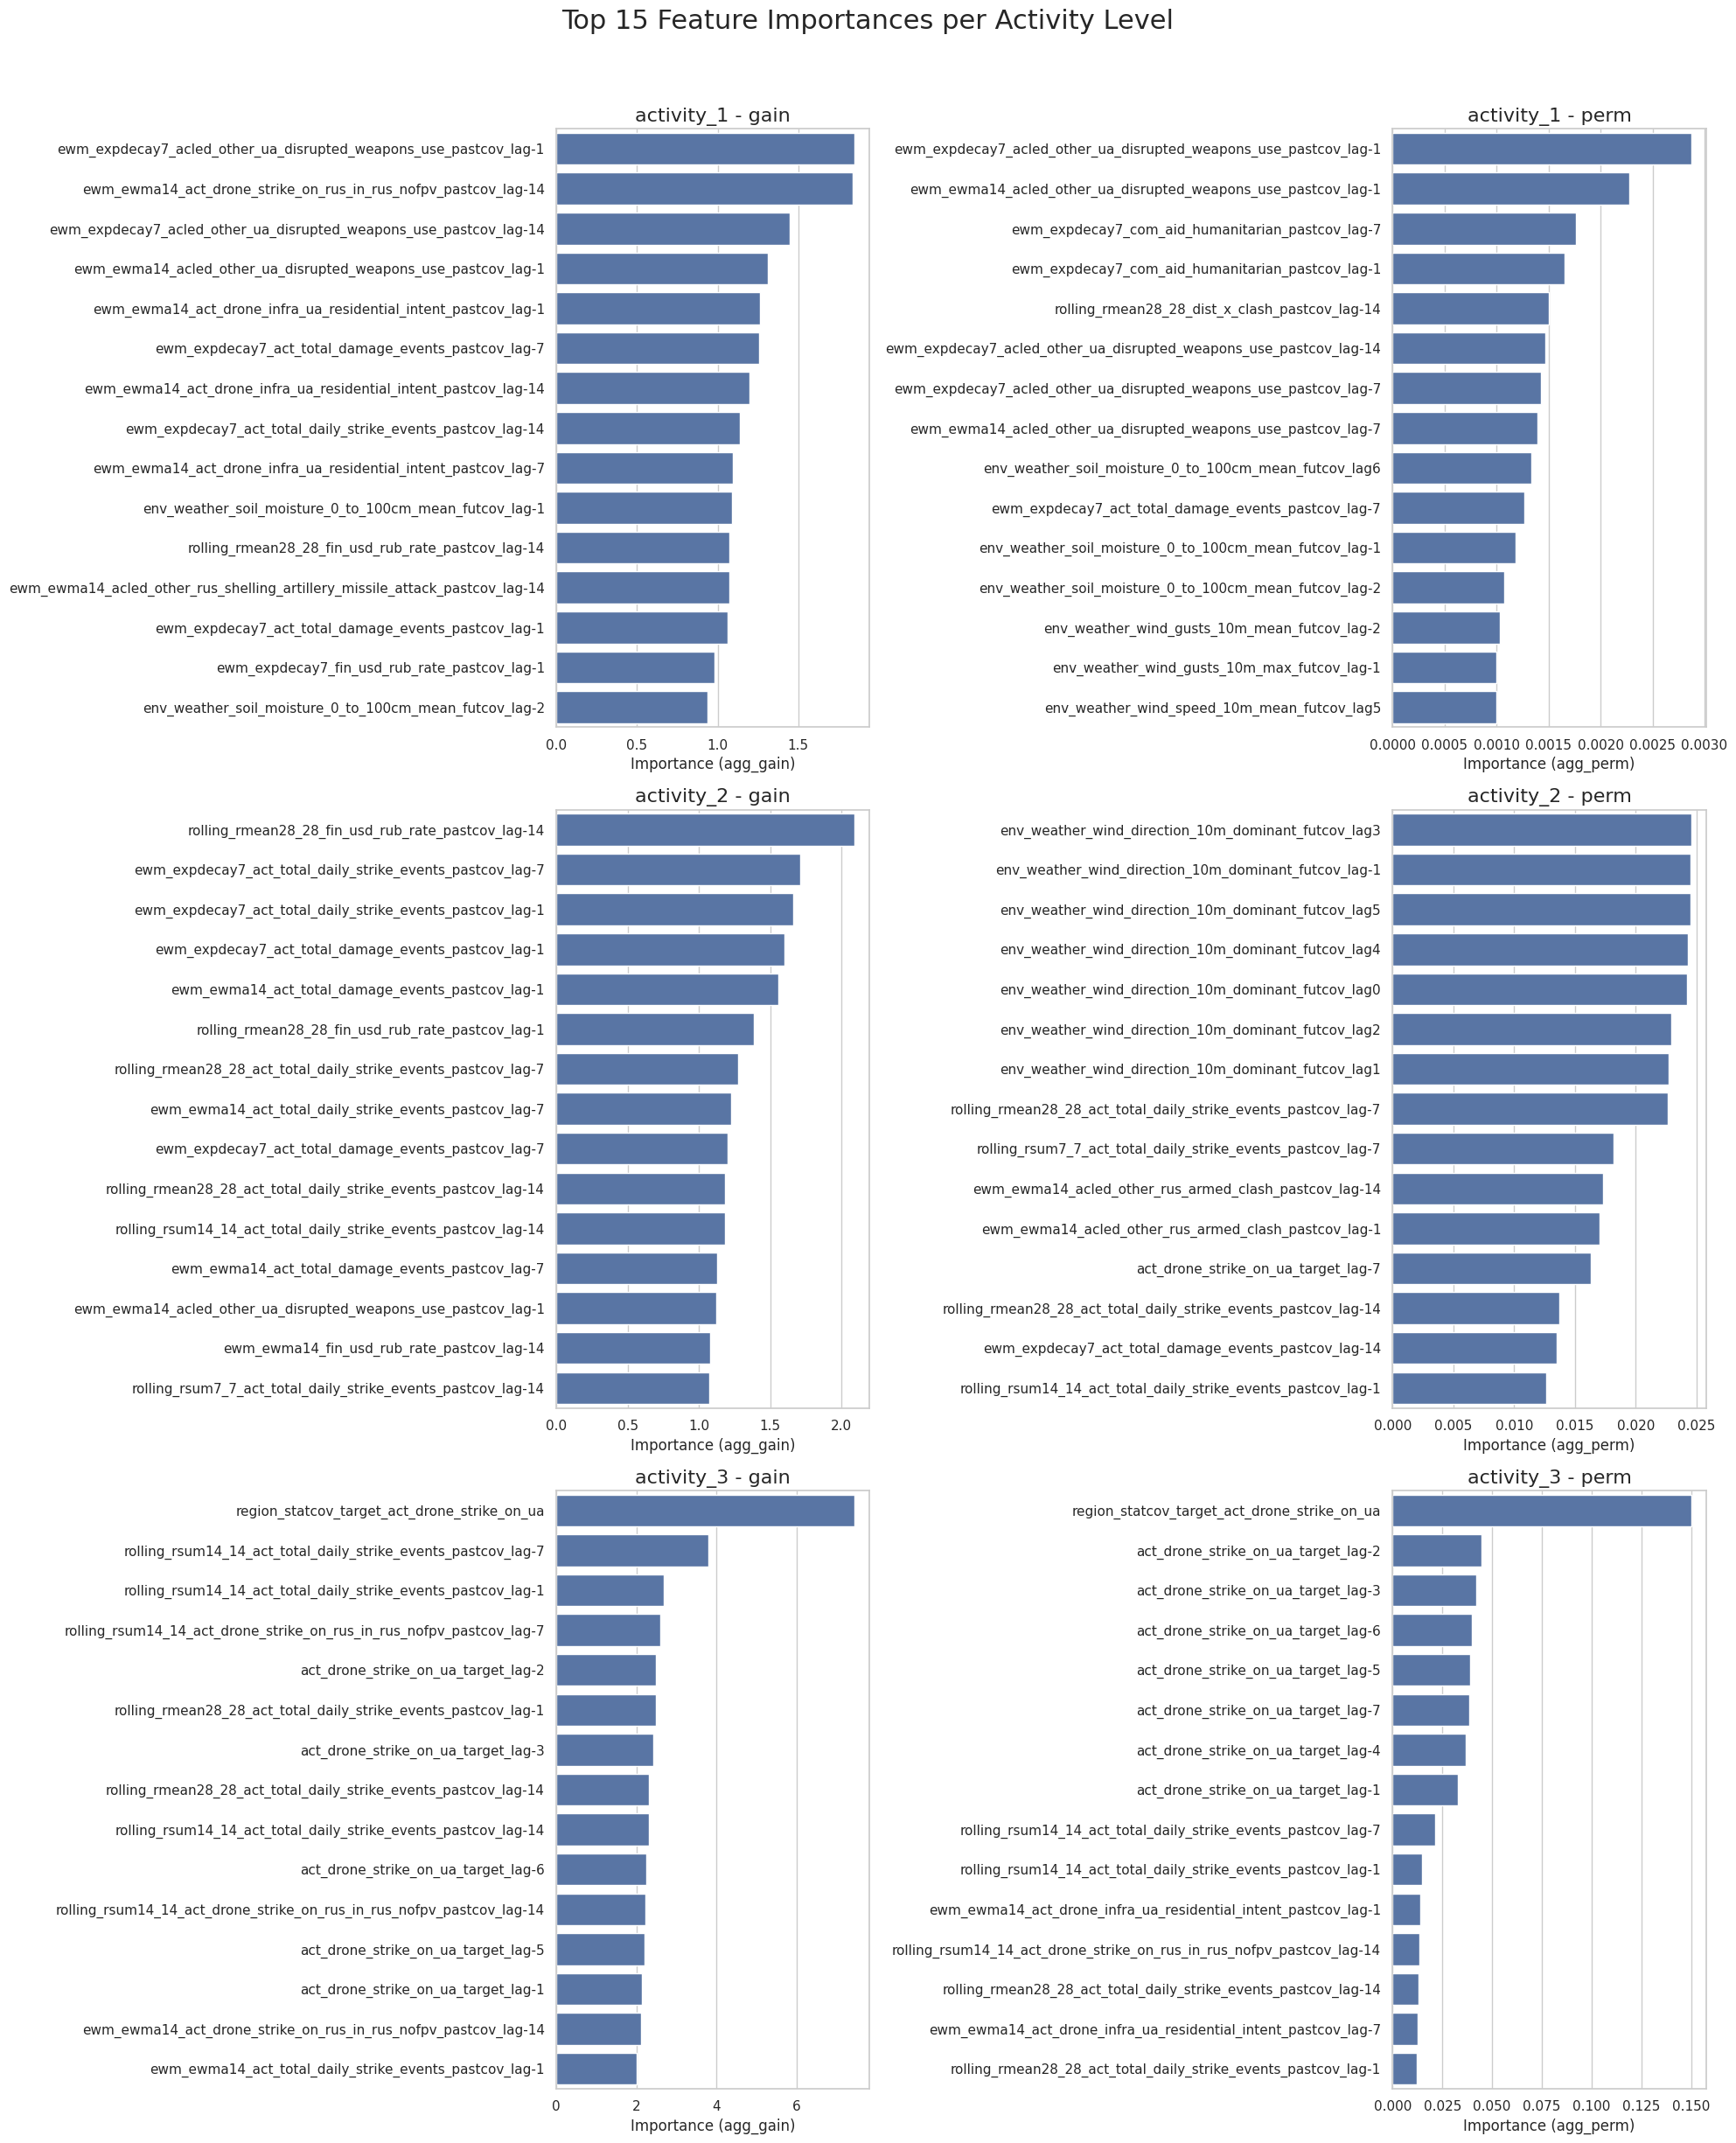

In [ ]:
# Works with your current 3x2 setup:
plot_feature_importances(importancedict, title="Top 15 Feature Importances per Activity Level")

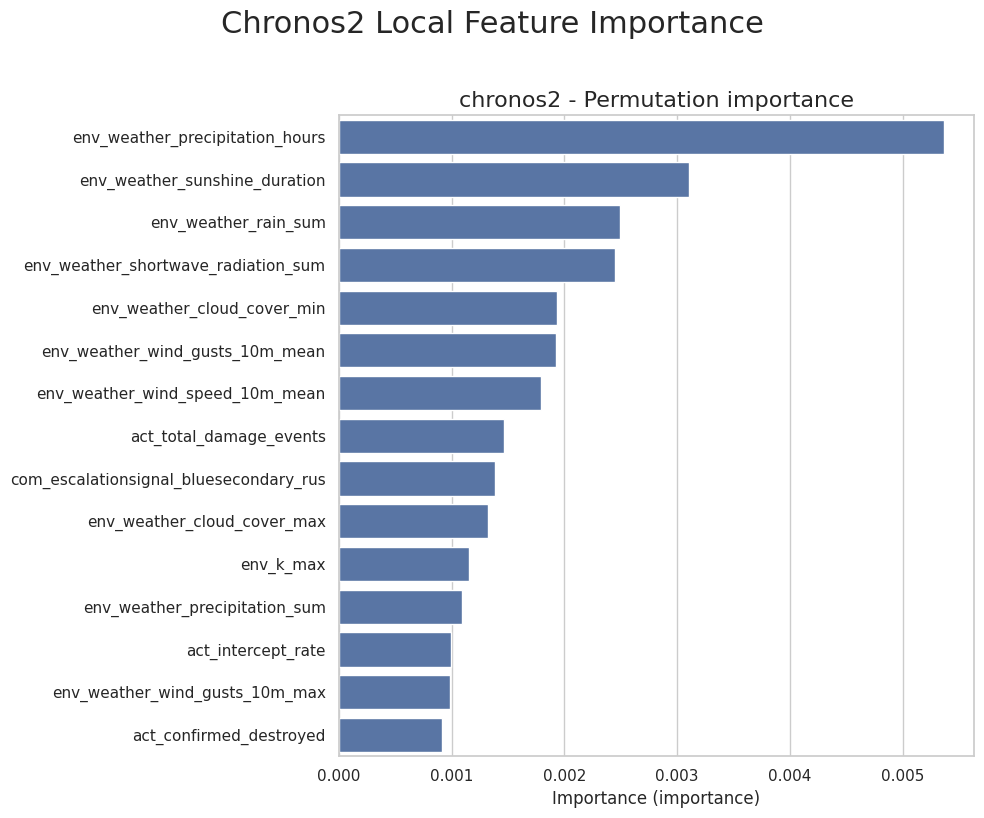

In [ ]:
global_dict = {'chronos2': {'Permutation importance': chronos2_importance}}
plot_feature_importances(global_dict, title="Chronos2 Local Feature Importance")

KeyError: "'tab:20' is not a known colormap name"

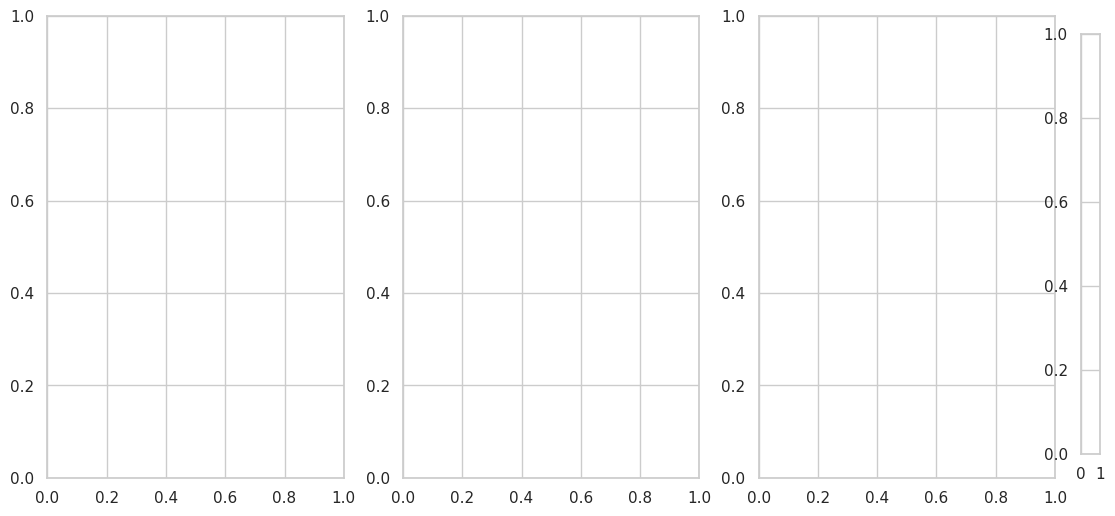

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# --- Map a raw feature name to a semantic category (specific rules first) ---
def classify_feature(name: str) -> str:
    n = name.lower()
    if any(k in n for k in ("region_statcov", "dist_to_nearest", "dist_x_clash", "area_km2")):
        return "Spatial / static"
    if "env_weather" in n or "env_k_max" in n:
        return "Weather / geomag."
    if "holiday" in n:
        return "Calendar"
    if "act_cyber" in n:
        return "Cyber"
    if any(k in n for k in ("confirmed_launched", "confirmed_destroyed", "intercept_rate")):
        return "Missile / launch"
    if any(k in n for k in ("usd_rub", "usd_uah", "ch_export")):
        return "Macroeconomic"
    if any(k in n for k in ("com_aid", "com_diplo", "com_verbal", "com_restrictive",
                            "com_escalation", "com_logistic", "com_ners")):
        return "Comms / diplo / aid"
    if any(k in n for k in ("disrupted_weapons", "shelling", "armed_clash",
                            "damage_events", "drone_infra", "acled_other")):
        return "Conflict & damage"
    if any(k in n for k in ("total_daily_strike_events", "drone_strike_on", "_target",
                            "specialmilitary", "ratio_ua_rus")):
        return "Autoregressive strikes"
    return "Other"


CATEGORY_ORDER = ["Autoregressive strikes", "Spatial / static", "Weather / geomag.",
                  "Conflict & damage", "Macroeconomic", "Comms / diplo / aid",
                  "Missile / launch", "Cyber", "Calendar", "Other"]
TOP_N = 15


def _col_share(df, top_n=TOP_N):
    """Importance-weighted share by category for the top-n features of one model column."""
    feat_col, val_col = df.columns[0], df.columns[1]
    top = df.head(top_n).copy()
    top[val_col] = top[val_col].clip(lower=0)          # guard against negative perm noise
    top["cat"] = top[feat_col].map(classify_feature)
    s = top.groupby("cat")[val_col].sum()
    tot = s.sum()
    return s / tot if tot > 0 else s                   # each column sums to 1 (= 100%)


def category_importance_matrix(importancedict, top_n=TOP_N):
    cols = {}
    for group, metrics in importancedict.items():
        for metric, df in metrics.items():
            label = f"{group.replace('activity_', 'Tier ')} {metric}"
            cols[label] = _col_share(df, top_n)
    mat = pd.DataFrame(cols).reindex(CATEGORY_ORDER).fillna(0.0)
    return mat.loc[(mat != 0).any(axis=1)]


mat = category_importance_matrix(importancedict, TOP_N)   # uses importancedict from earlier cell
VMAX = mat.values.max()
tiers = ["Tier 1", "Tier 2", "Tier 3"]
facet_order = [c for c in CATEGORY_ORDER if c in mat.index][::-1]   # Auto at bottom for facets


def _annot(d):
    return d.map(lambda v: f"{v:.0%}" if v > 0 else "")


def _heat(ax, d, **kw):
    sns.heatmap(d, ax=ax, cmap="Blues", vmin=0, vmax=VMAX, annot=_annot(d), fmt="",
                linewidths=.5, linecolor="white", **kw)



fig, axes = plt.subplots(1, 3, figsize=(13, 6))
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
for i, t in enumerate(tiers):
    sub = mat[[f"{t} gain", f"{t} perm"]].reindex(facet_order)
    sub.columns = ["gain", "perm"]
    _heat(axes[i], sub, cbar=(i == 2), cbar_ax=cbar_ax if i == 2 else None,
          yticklabels=(i == 0),
          cbar_kws={"label": "share within column (top 15)"} if i == 2 else None)
    axes[i].set(title=t, xlabel="", ylabel="")
    plt.setp(axes[i].get_xticklabels(), rotation=0)
fig.suptitle("Feature-importance share by category  (top 15 features per column)", fontsize=14)
fig.subplots_adjust(right=0.9, top=0.9, wspace=0.1)
plt.savefig("./figs/Feature-importancesharebycategory_grouped.svg", bbox_inches="tight")
plt.show()



In [257]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_horizon_permutations(df, top_n=15, title='Permutation Importance Comparison (h1 - h7)'):
    """
    Plots permutation importances for horizons h1 through h7 from the gbdt_glob_importance dataframe.
    Specifically designed to visually compare feature shifts and investigate h3_perm.
    """
    # Generate the list of columns we want to plot
    horizons = [f'h{i}_gain' for i in range(1, 8)]
    
    # Setup a 2x4 grid for our 7 plots
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(26, 14))
    axes = axes.flatten() # Flatten to 1D array for easier iteration
    
    fig.suptitle(title, fontsize=24, y=1.02)
    
    for i, h_col in enumerate(horizons):
        ax = axes[i]
        
        # Safety check in case a horizon column is missing
        if h_col not in df.columns:
            ax.axis('off')
            continue
            
        # Slice the specific horizon, sort descending, grab top_n
        top_df = df[['Feature', h_col]].sort_values(by=h_col, ascending=False).head(top_n)
        
        # Highlight h3 specifically to see why it performs better
        is_target_h3 = (h_col == 'h3_perm')
        palette = "magma" if is_target_h3 else "viridis"
        
        sns.barplot(
            data=top_df, 
            x=h_col, 
            y='Feature', 
            ax=ax,
            palette=palette
        )
        
        # Apply visual emphasis to the h3_perm title
        title_weight = 'bold' if is_target_h3 else 'normal'
        title_color = 'darkred' if is_target_h3 else 'black'
        
        ax.set_title(f'Top {top_n} Features: {h_col}', fontsize=16, weight=title_weight, color=title_color)
        ax.set_xlabel('Permutation Importance', fontsize=12)
        ax.set_ylabel('')
        ax.tick_params(axis='y', labelsize=11)

    # Turn off the 8th (empty) subplot in the 2x4 grid
    axes[7].axis('off')
    
    plt.tight_layout()
    
    # Save dynamically based on title
    filename = f"./figs/{'_'.join(title.split(' '))}.svg"
    # plt.savefig(filename, bbox_inches='tight') # Uncomment to save
    plt.show()

/tmp/ipykernel_81303/2510164701.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_81303/2510164701.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_81303/2510164701.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_81303/2510164701.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_81303/2510164701.py:33: FutureWarning

/tmp/ipykernel_81303/2510164701.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_81303/2510164701.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


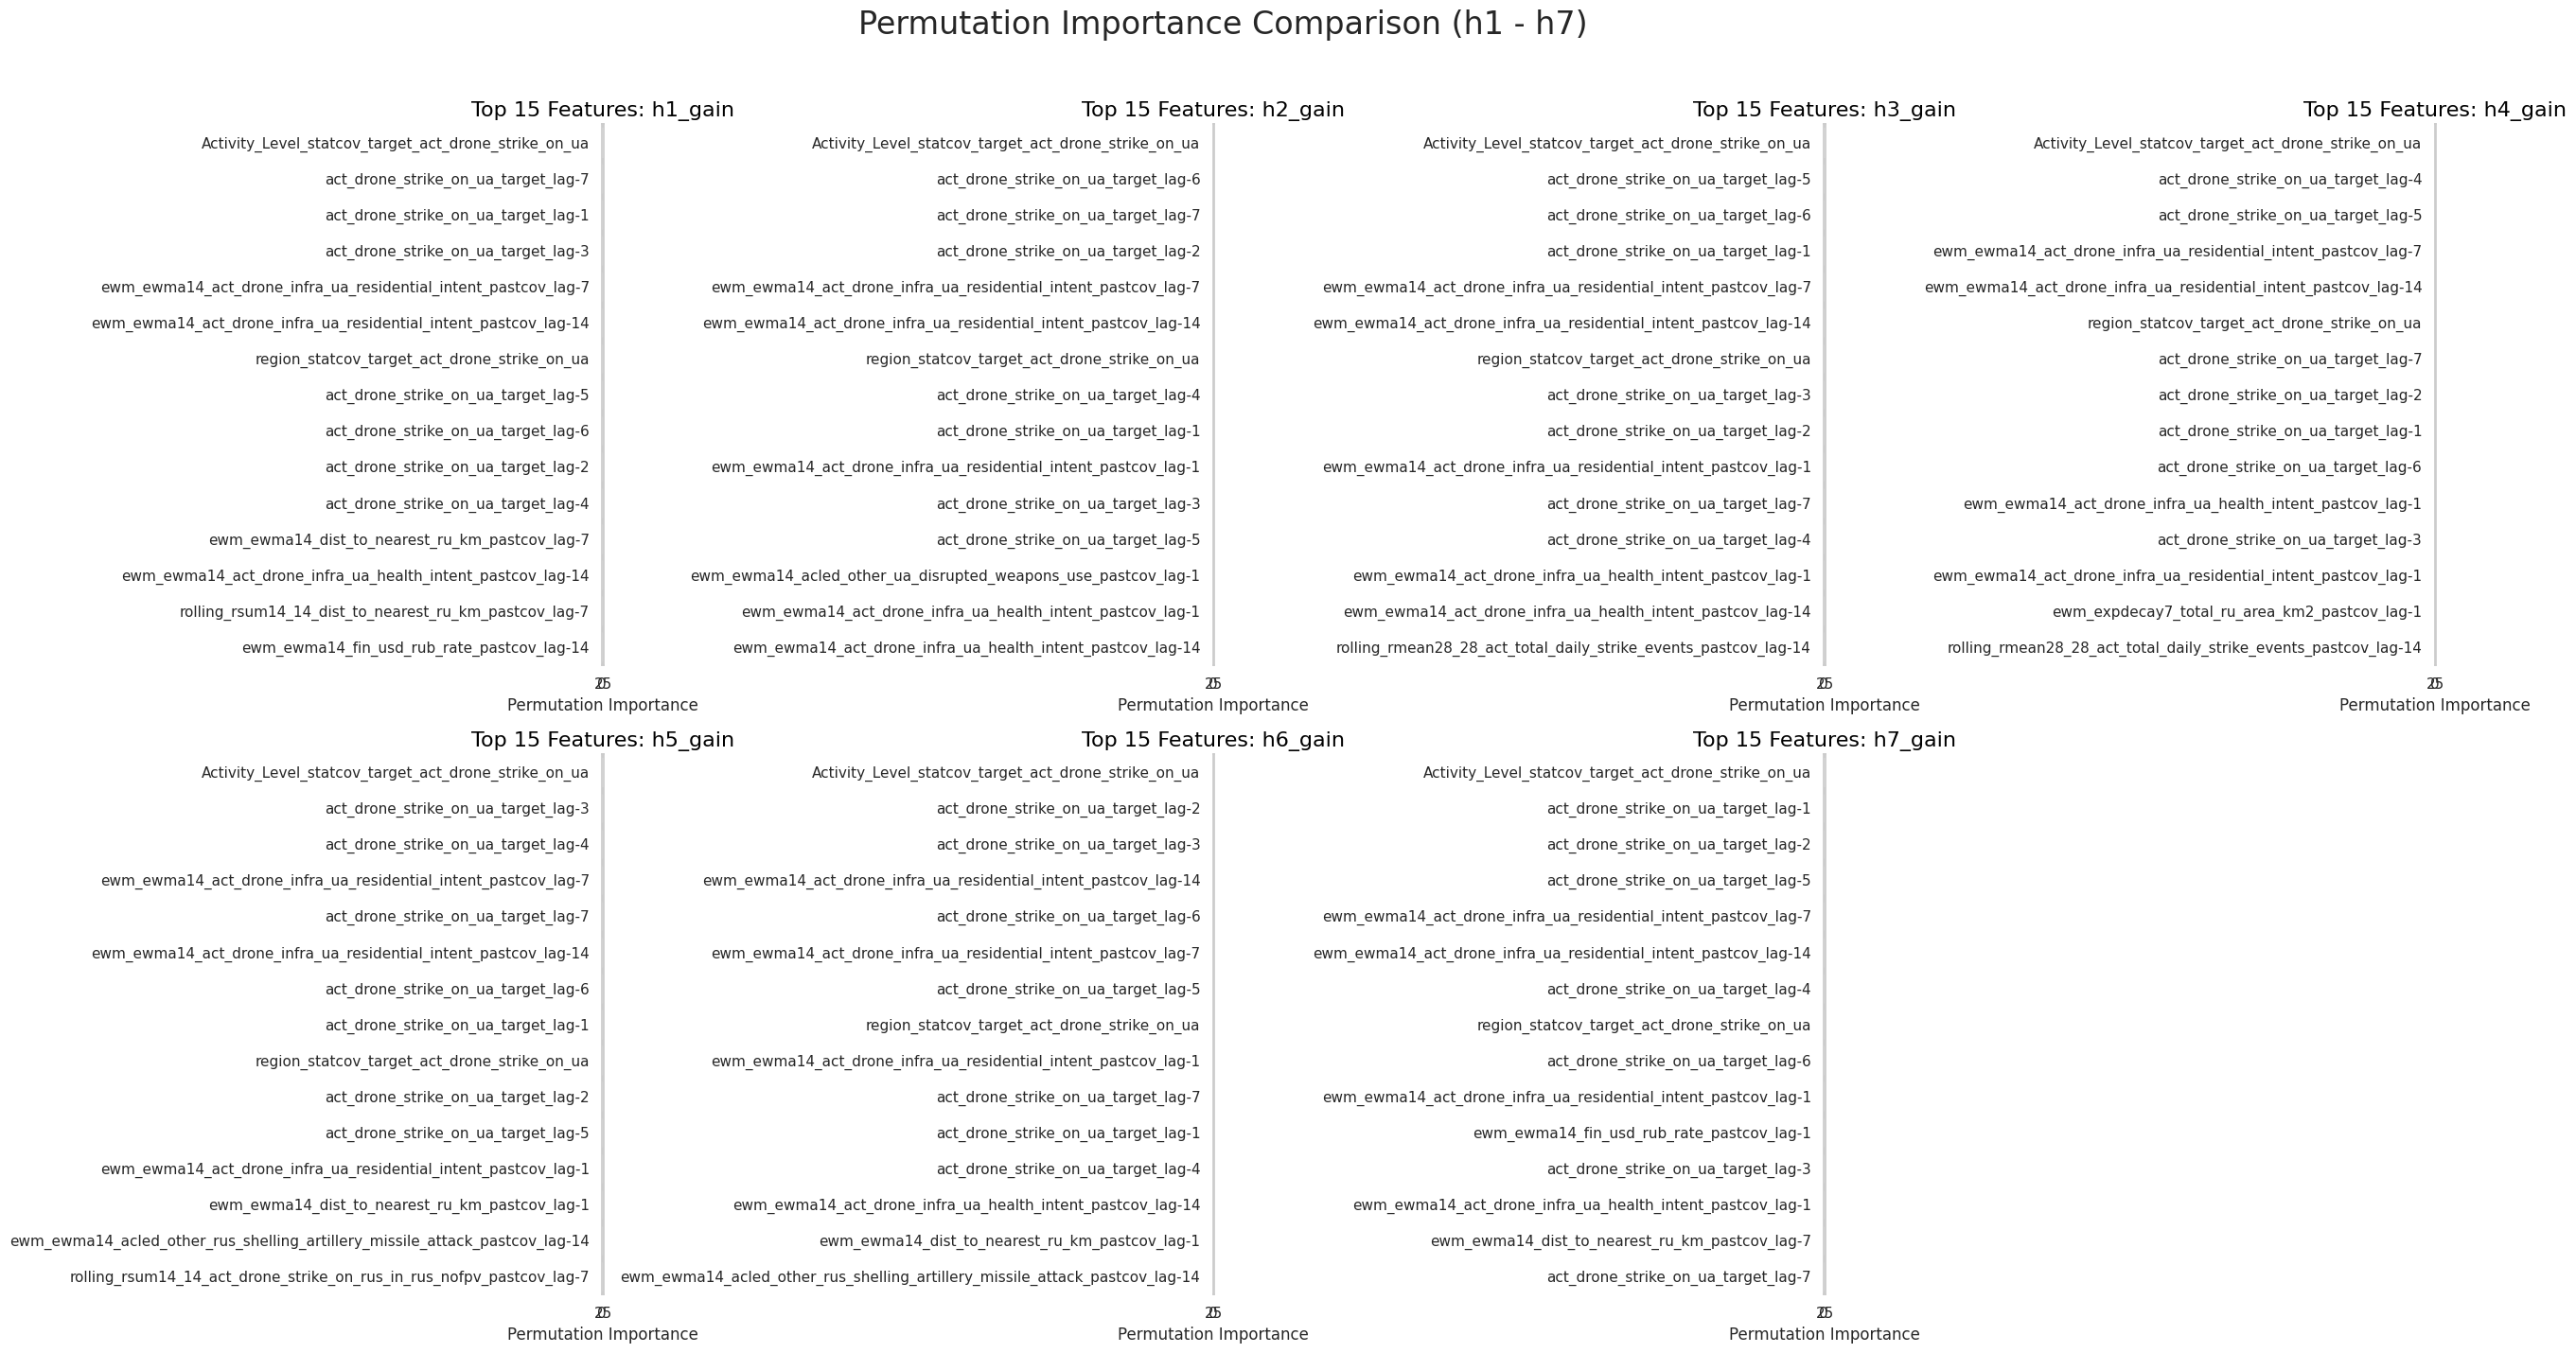

In [258]:
plot_horizon_permutations(gbdt_glob_importance, top_n=15)

In [259]:
importancedict['activity_1']['gain']

,Feature,agg_gain
582,ewm_expdecay7_acled_other_ua_disrupted_weapons...,1.849189
618,ewm_ewma14_act_drone_strike_on_rus_in_rus_nofp...,1.835655
587,ewm_expdecay7_acled_other_ua_disrupted_weapons...,1.444200
583,ewm_ewma14_acled_other_ua_disrupted_weapons_us...,1.309310
600,ewm_ewma14_act_drone_infra_ua_residential_inte...,1.260323
591,ewm_expdecay7_act_total_damage_events_pastcov_...,1.257958
597,ewm_ewma14_act_drone_infra_ua_residential_inte...,1.198591
621,ewm_expdecay7_act_total_daily_strike_events_pa...,1.137624
612,ewm_ewma14_act_drone_infra_ua_residential_inte...,1.093860
592,env_weather_soil_moisture_0_to_100cm_mean_futc...,1.090929


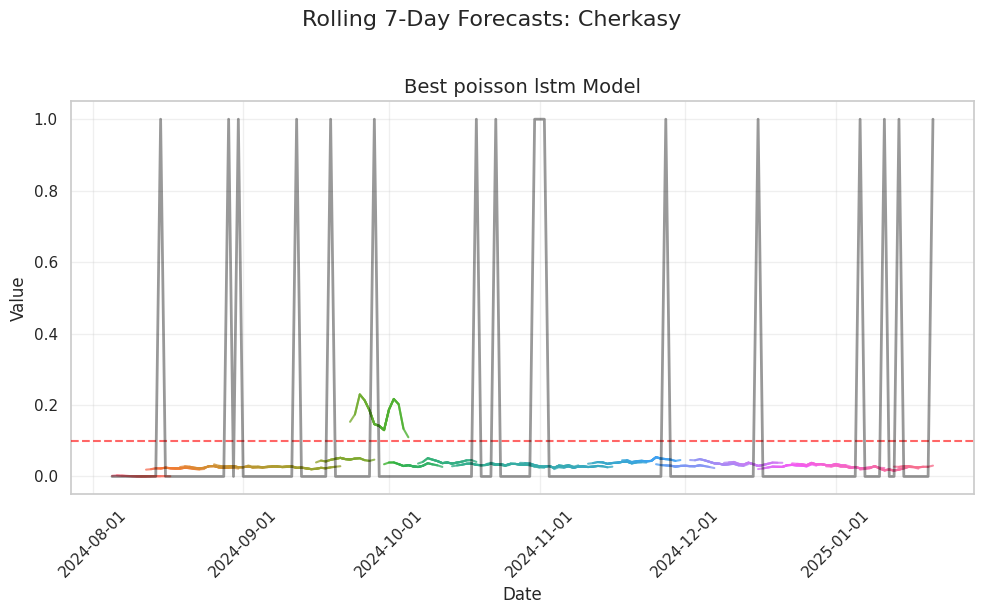

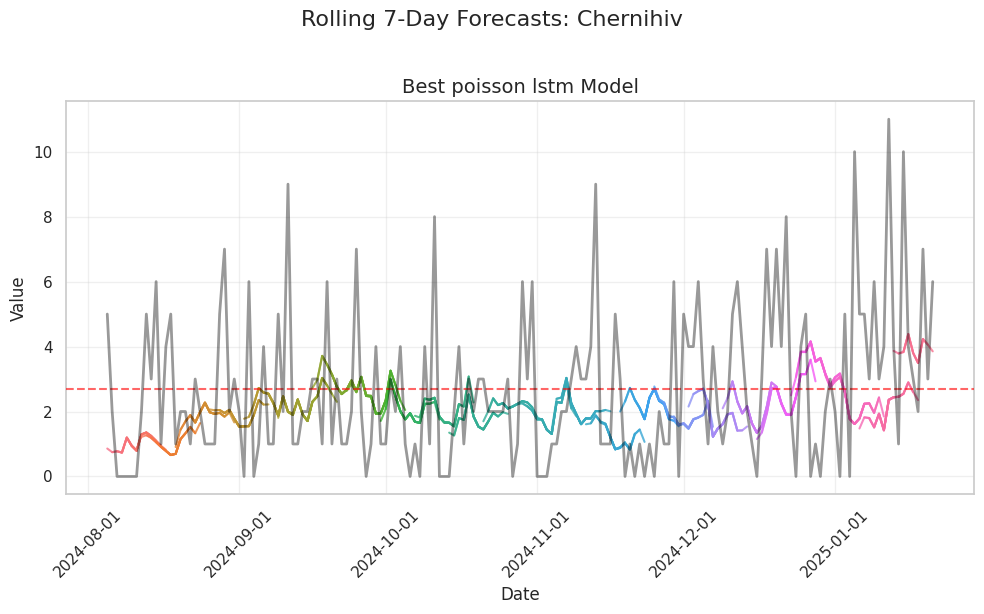

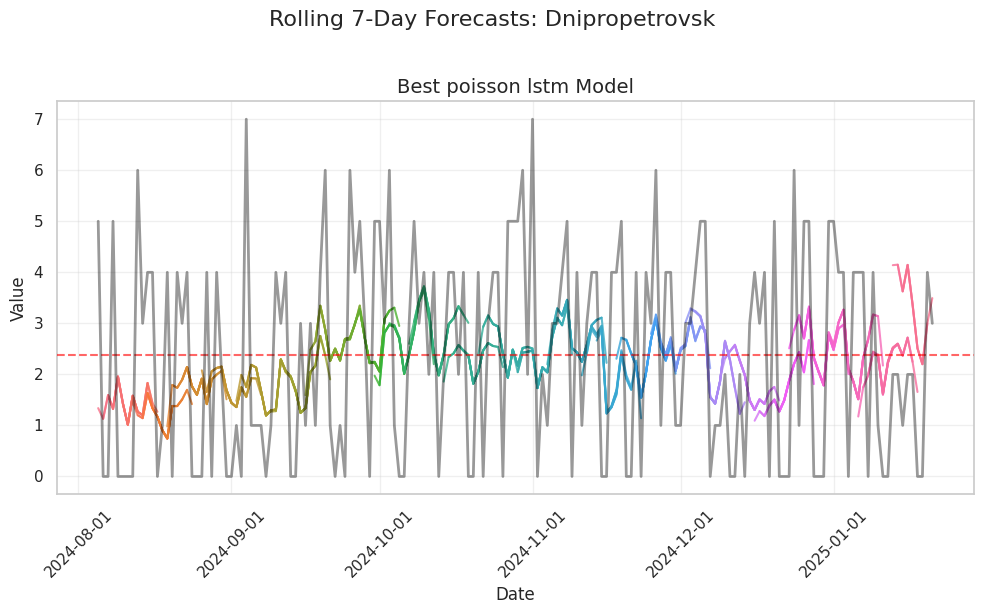

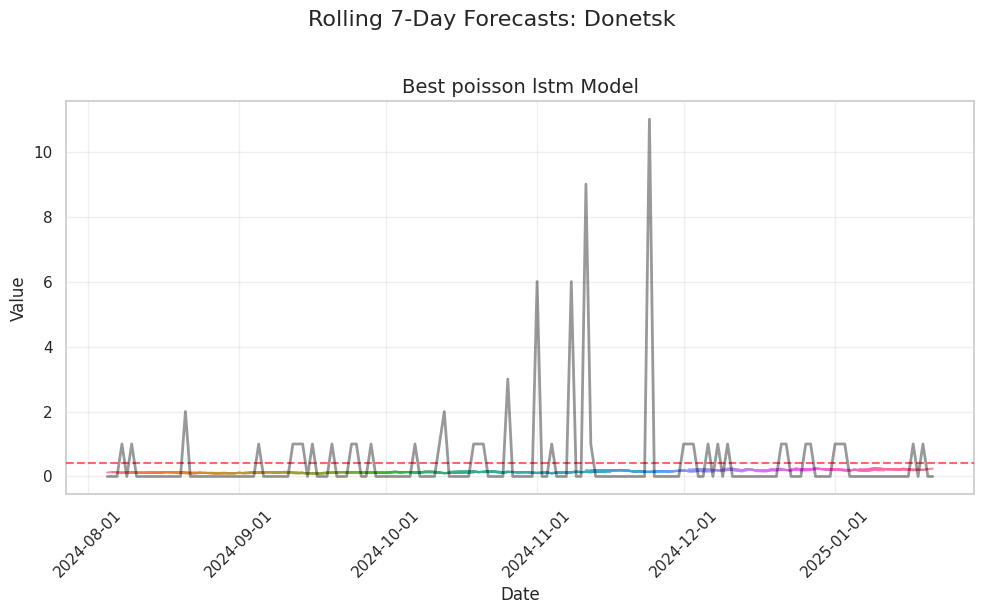

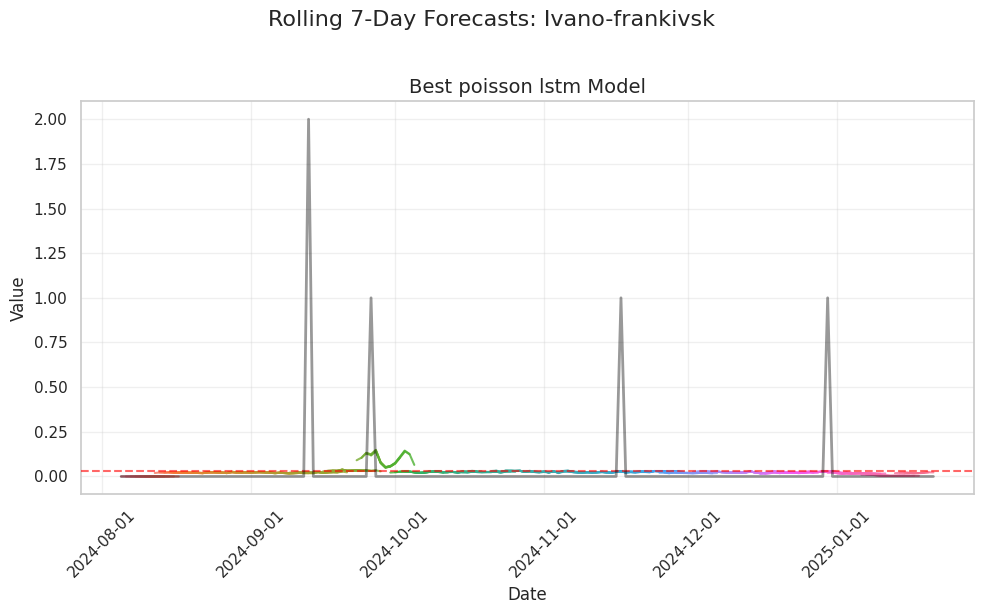

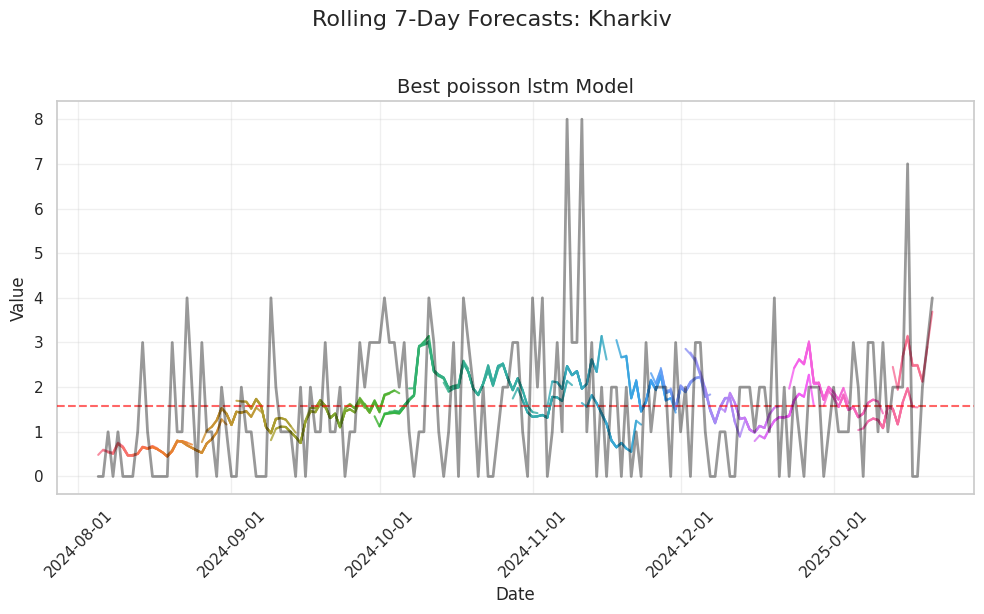

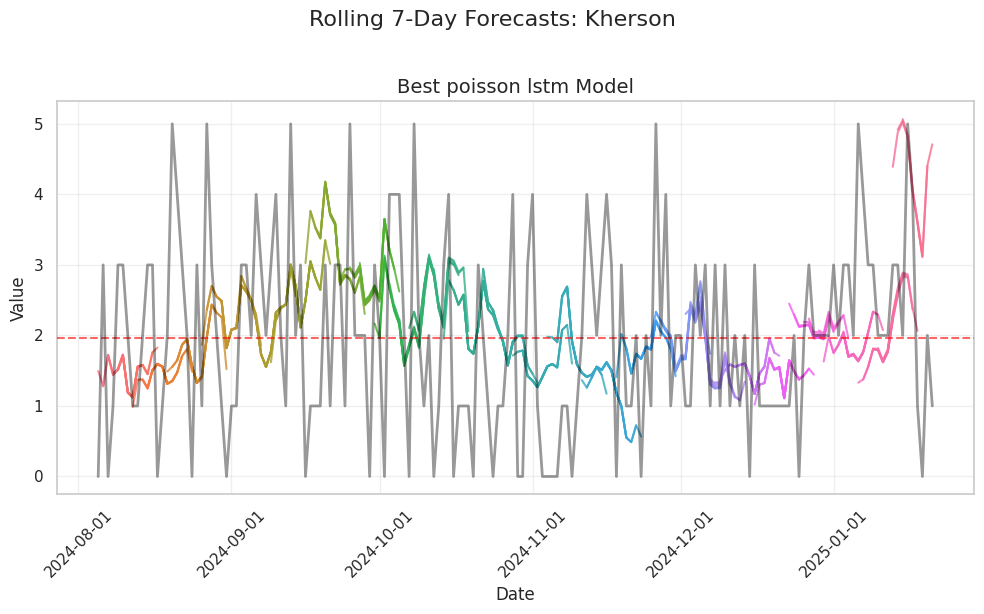

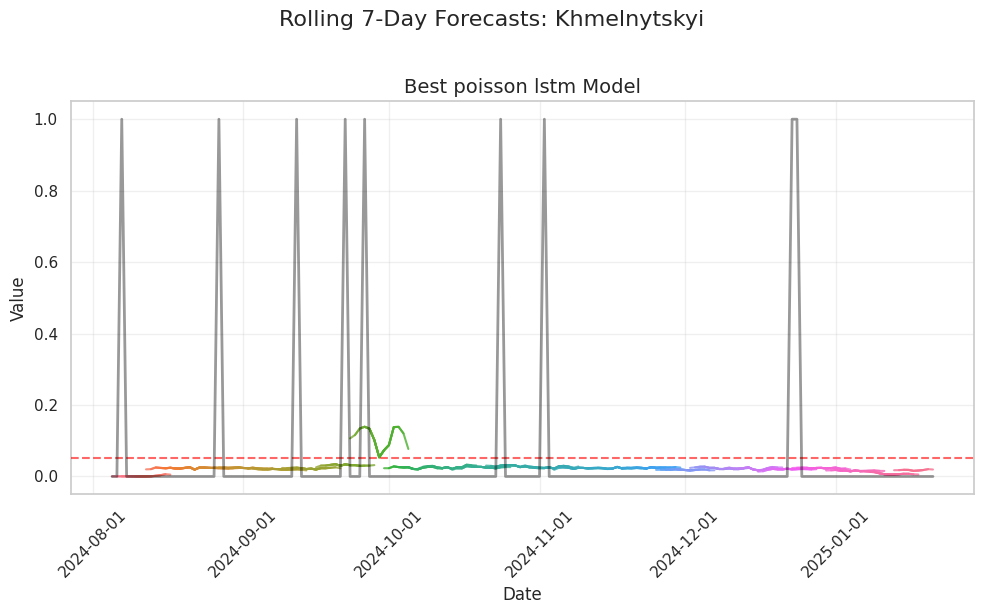

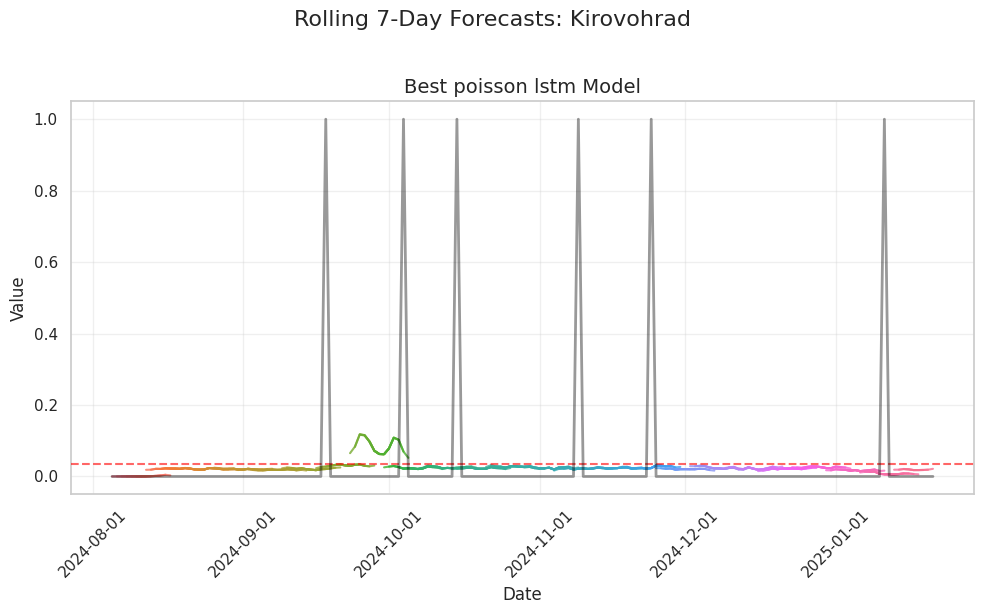

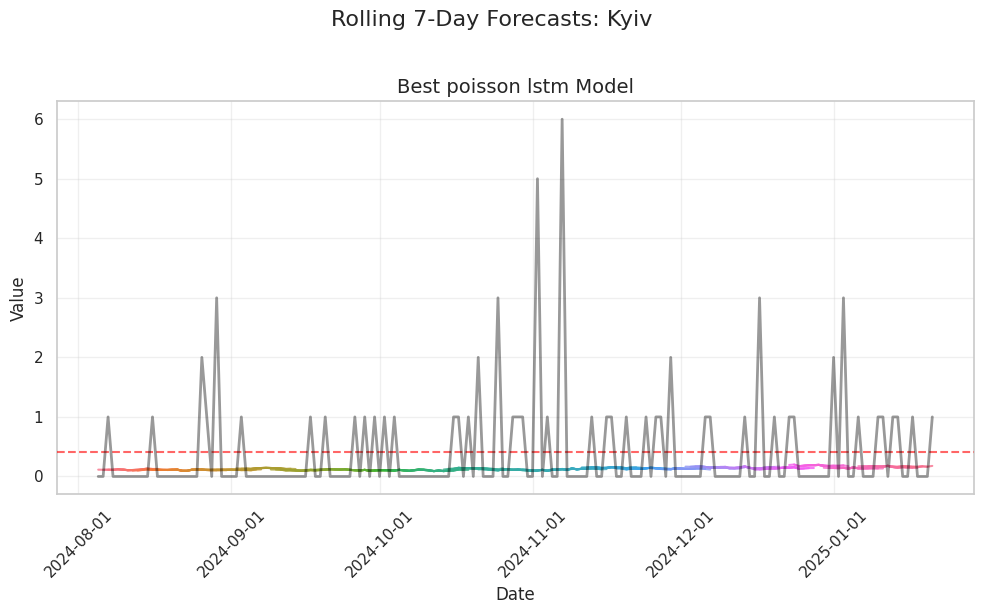

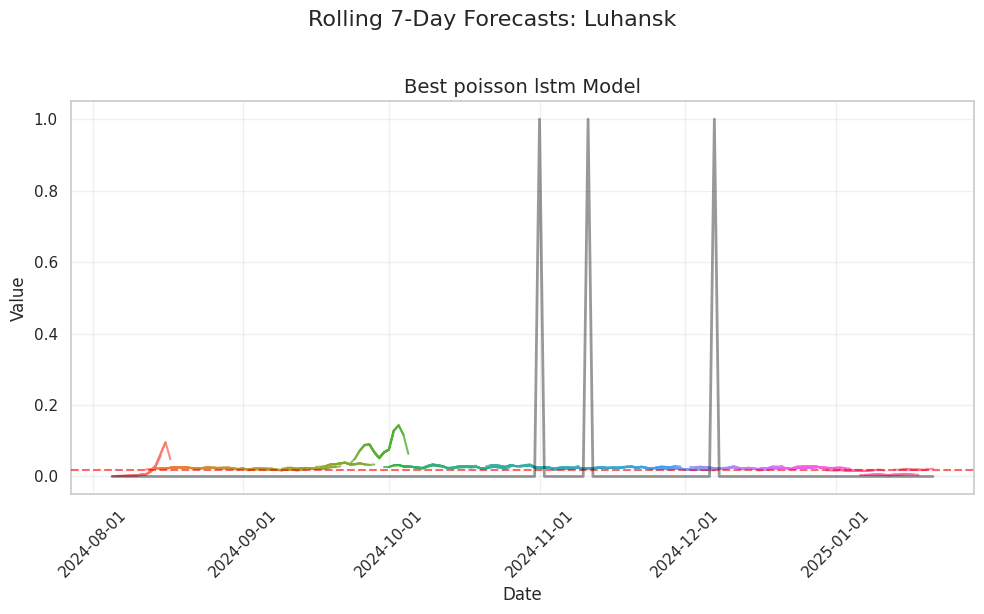

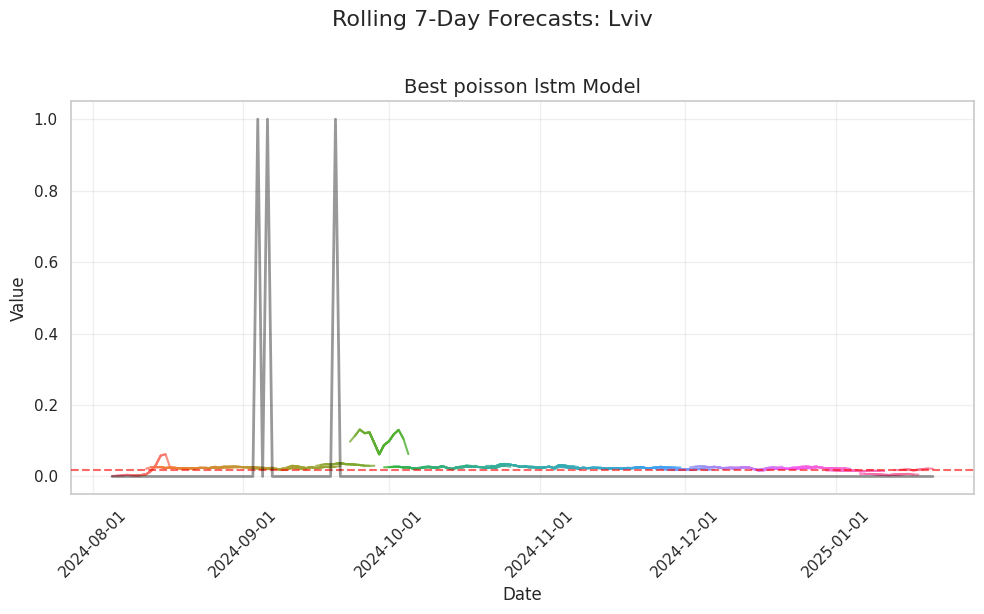

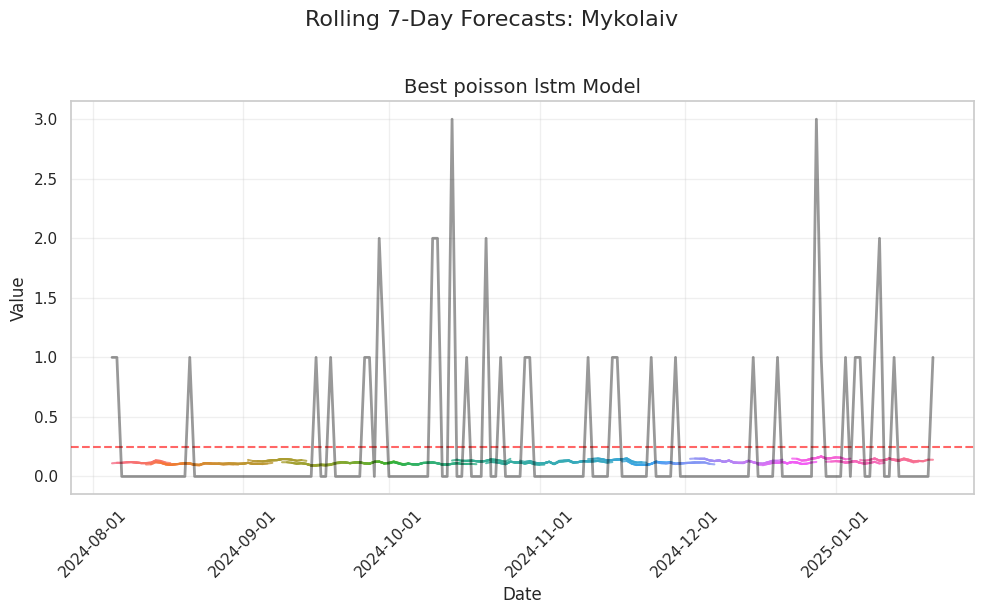

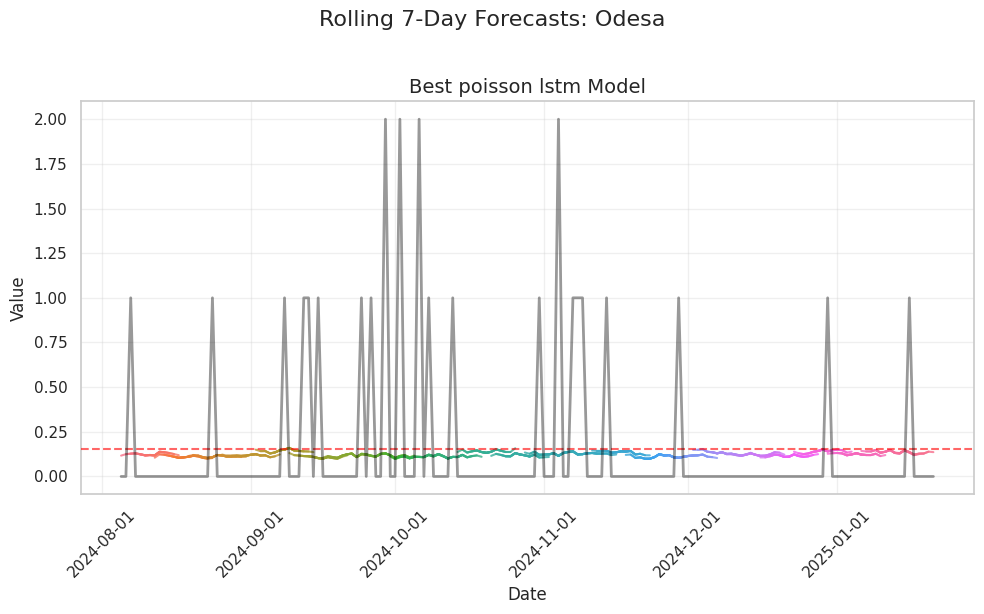

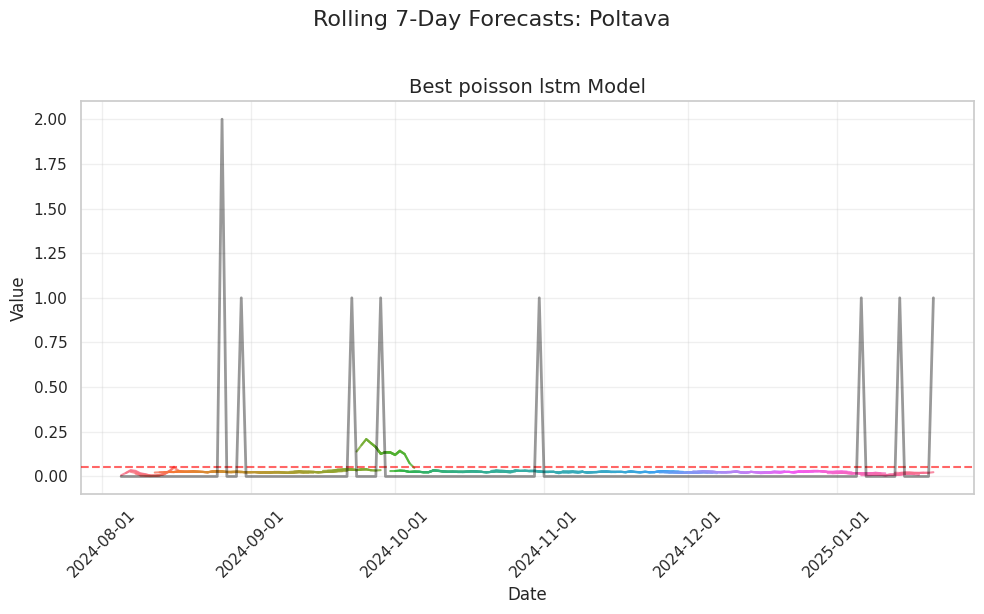

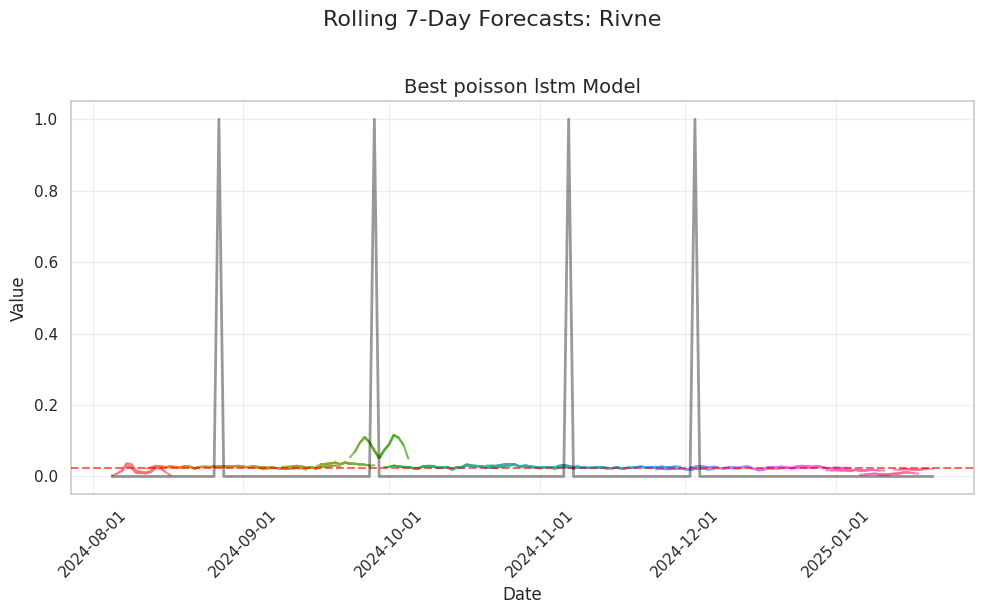

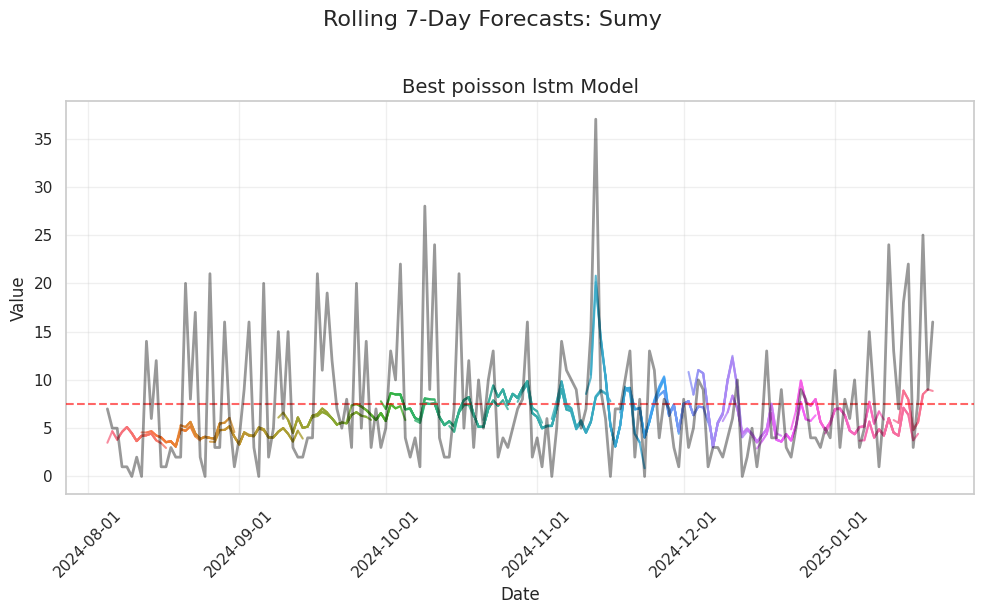

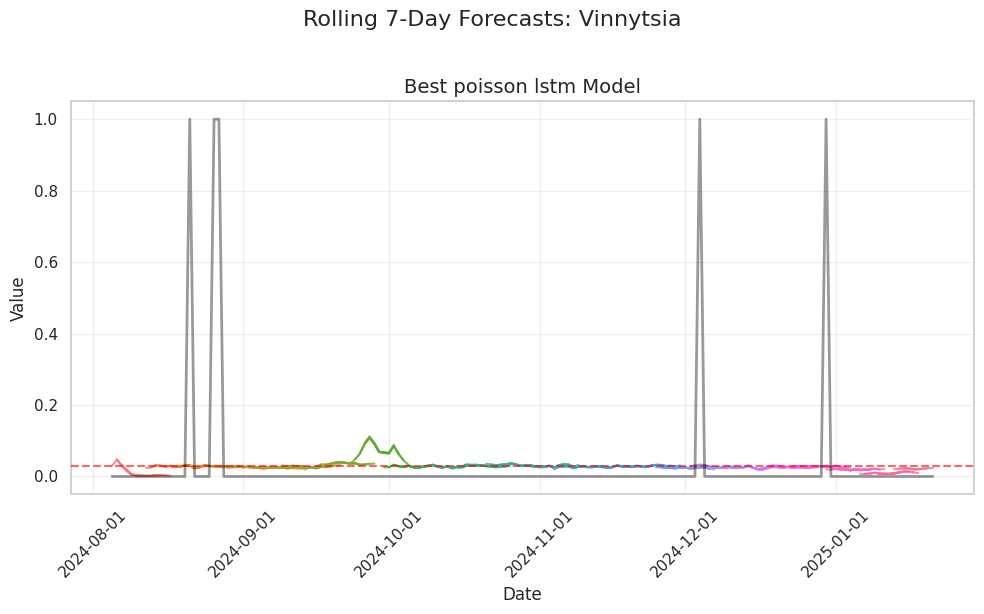

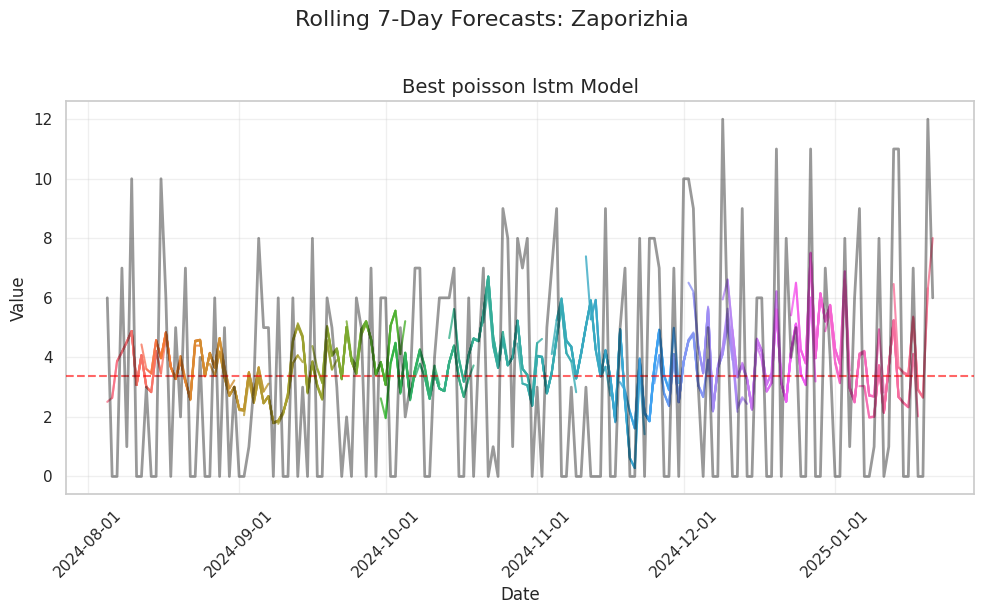

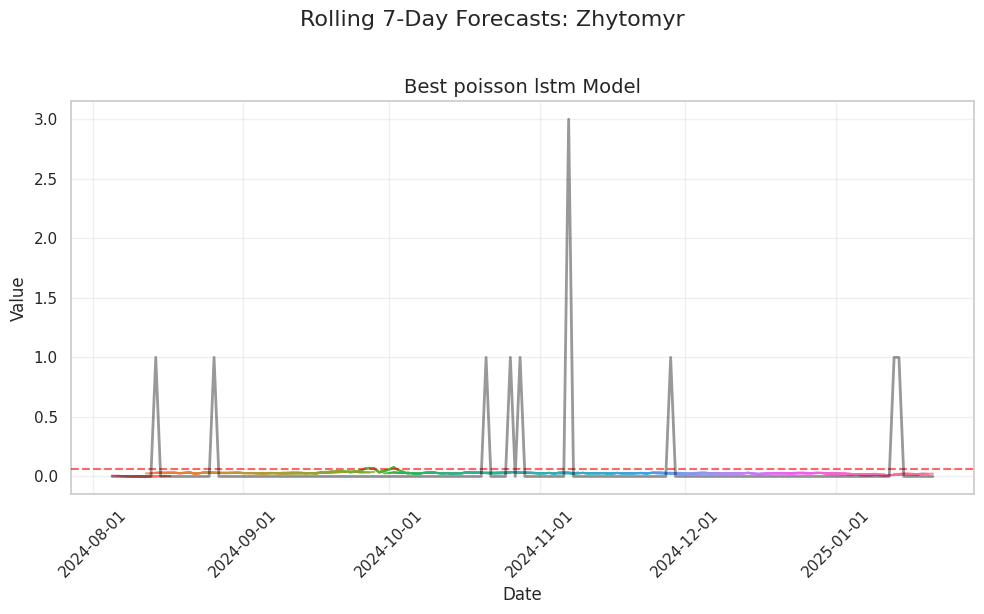

In [260]:
#1
nr1 = pd.read_parquet('./gbdt/predictions_long_test_activity_catboost_tweedie_tuned.parquet')
#2
nr2 = pd.read_parquet('./chronos2/predictions_long_chronos2_fine_tuned.parquet')
#3
nr3 = pd.read_parquet('./gbdt/predictions_long_test_global_catboost_tweedie_tuned.parquet')
#4
nr4 = pd.read_parquet('./gbdt/predictions_long_test_global_lightgbm_poisson_tuned.parquet')
#5
nr5 = pd.read_parquet('./lstm/predictions_long_test_activity_lstm_poisson_w28_tuned.parquet')

# naive seasonal weekly
naive = pd.read_parquet('./diff/predictions_long_test_global_naive_weekly.parquet')
naive_last = pd.read_parquet('./diff/predictions_long_test_global_naive_last.parquet')


arima = pd.read_parquet('./diff/predictions_long_test_global_arima.parquet')

hurdle = pd.read_parquet('./finalhurdle/global_test_hurdle_cal_preds.parquet')

# chronos2_0s = pd.read_parquet('./lstm/predictions_long_chronos2_zero_shot.parquet')
# plot_model_forecasts(arima, model_name="ARIMA Model")
# plot_model_forecasts(best_lstm, model_name="Best LSTM Model")
# plot_model_forecasts(catboost_log, model_name="Best log")
# plot_model_forecasts(best_grutweedie, model_name="Best gru tweedie Model")
plot_model_forecasts(nr5, model_name="Best poisson lstm Model")

# plot_model_forecasts(hurdle, model_name="Hurdle")

# plot_model_forecasts(chronos2_0s, model_name="Chronos2 (Zero-Shot)")

In [261]:
from sklearn.metrics import r2_score

In [262]:
print('naive', f"{r2_score(naive['y_true'], naive['y_pred']):.2f}")
print('naive_last', f"{r2_score(naive_last['y_true'], naive_last['y_pred']):.2f}")
print('nr1', f"{r2_score(nr1['y_true'], nr1['y_pred']):.2f}")
print('nr2', f"{r2_score(nr2['y_true'], nr2['y_pred']):.2f}")
print('nr3', f"{r2_score(nr3['y_true'], nr3['y_pred']):.2f}")
print('nr4', f"{r2_score(nr4['y_true'], nr4['y_pred']):.2f}")
print('nr5', f"{r2_score(nr5['y_true'], nr5['y_pred']):.2f}")
print('arima', f"{r2_score(arima['y_true'], arima['y_pred']):.2f}")
print('hurdle', f"{r2_score(hurdle['y_true'], hurdle['y_pred']):.2f}")

naive 0.28
naive_last 0.01
nr1 0.50
nr2 0.50
nr3 0.50
nr4 0.50
nr5 0.50
arima 0.49
hurdle 0.40
